# 21SJ-14K JAN 日次EDAノート

このノートでは、JANごとの日次売上を解析します。
売上・入荷・欠品期間を同時に確認できます。

## 使い方
1. 上から順に実行します。
2. `jan_summary` で対象JANを確認します。
3. CELL 6 だけ実行すれば、全JANを連続描画します。



In [1]:
# セル1: ライブラリ読み込みと描画基本設定
# ノート全体で使うスタイル・フォント・基準パスを定義します


from pathlib import Path
import csv
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('ggplot')

plt.rcParams['font.family'] = ['Yu Gothic', 'Meiryo', 'MS Gothic', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path.cwd()
print('BASE_DIR =', BASE_DIR)


BASE_DIR = e:\GitHub\Kaggle\data\kimono_fabric\21SJ-14K 分析


In [2]:
# セル2: 入力CSVファイルの自動検出
# ファイル名と列構造のヒントから、欠品・入荷・発注CSVを自動判定


all_csv = sorted(BASE_DIR.glob('*.csv'))
if not all_csv:
    raise FileNotFoundError('カレントディレクトリにCSVファイルが見つかりません。')

jan_list_path = next((p for p in all_csv if p.name.startswith('21SJ-14K') and 'JAN' in p.name), None)
sales_path = next((p for p in all_csv if p.name.startswith('21SJ-14K') and 'JAN' not in p.name), None)

candidates_452 = [p for p in all_csv if '_452' in p.name]

# 文字化け回避のため、ファイル名パターンはユニコードエスケープで記述
KW_STOCKOUT = '\u5728\u5eab\u5207\u308c'  # stockout
KW_RECEIPT = '\u5165\u8377'                    # receipt
KW_ORDER = '\u767a\u6ce8'                      # order

stockout_path = next((p for p in candidates_452 if KW_STOCKOUT in p.name), None)
receipt_path = next((p for p in candidates_452 if KW_RECEIPT in p.name and KW_ORDER not in p.name), None)
order_path = next((p for p in candidates_452 if KW_ORDER in p.name), None)


def _is_jan(v: str) -> bool:
    return bool(re.fullmatch(r'452\d{10}', str(v).strip()))


def _is_date(v: str) -> bool:
    return bool(re.fullmatch(r'(\d{8}|\d{4}-\d{2}-\d{2})', str(v).strip()))


def _is_num(v: str) -> bool:
    return bool(re.fullmatch(r'-?\d+(\.\d+)?', str(v).strip()))


def _read_rows(path_obj: Path, max_rows=3):
    with open(path_obj, 'r', encoding='utf-8-sig', newline='') as f:
        rows = []
        for _, r in zip(range(max_rows), csv.reader(f)):
            rows.append(r)
    return rows


def _looks_like_stockout(rows) -> bool:
    if len(rows) < 2:
        return False
    r1, r2 = rows[0], rows[1]
    if len(r2) < 4:
        return False
    return (not _is_jan(r1[0])) and _is_jan(r2[0]) and _is_date(r2[1]) and _is_date(r2[2]) and _is_num(r2[3])


def _looks_like_event3(rows) -> bool:
    if not rows:
        return False

    # ヘッダーなし形式: 452... / 日付 / 数量
    r0 = rows[0]
    if len(r0) >= 3 and _is_jan(r0[0]) and _is_date(r0[1]) and _is_num(r0[2]):
        return True

    # ヘッダーあり形式: 2行目を利用
    if len(rows) >= 2:
        r1, r2 = rows[0], rows[1]
        if len(r2) >= 3 and (not _is_jan(r1[0])) and _is_jan(r2[0]) and _is_date(r2[1]) and _is_num(r2[2]):
            return True

    return False


event3_files = []
for p in candidates_452:
    rows = _read_rows(p)
    if _looks_like_stockout(rows) and stockout_path is None:
        stockout_path = p
    if _looks_like_event3(rows):
        event3_files.append(p)


if receipt_path is None:
    # まずは発注ファイル以外を優先
    receipt_path = next((p for p in event3_files if p != stockout_path and KW_ORDER not in p.name), None)

if order_path is None:
    # イベント系ファイル内で発注キーワードを含む名前を優先
    order_path = next((p for p in event3_files if KW_ORDER in p.name and p != receipt_path), None)

if order_path is None:
    # 最終フォールバック: 入荷ファイル以外のイベントファイルを採用
    order_path = next((p for p in event3_files if p != stockout_path and p != receipt_path), None)


required = {
    'jan_list_path': jan_list_path,
    'sales_path': sales_path,
    'stockout_path': stockout_path,
    'receipt_path': receipt_path,
    'order_path': order_path,
}
missing = [k for k, v in required.items() if v is None]
if missing:
    raise FileNotFoundError(f'Missing required files: {missing}')

for k, v in required.items():
    print(f'{k}: {v.name}')

jan_list_path: 21SJ-14K JAN一覧.csv
sales_path: 21SJ-14K売上集計.csv
stockout_path: 在庫切れ期間一覧_452限定.csv
receipt_path: 入荷データ一覧_452限定.csv
order_path: 発注日&発注数量_452限定.csv


In [3]:
# セル3: データ読み込みと前処理
# 基礎テーブル（売上日次・入荷日次・発注日次・欠品期間）を作成


def parse_mixed_date(series: pd.Series) -> pd.Series:
    """混在形式の日付文字列をdatetimeに統一する。"""
    s = series.astype(str).str.strip().str.replace('.0', '', regex=False)
    dt = pd.to_datetime(s, format='%Y-%m-%d', errors='coerce')
    dt2 = pd.to_datetime(s, format='%Y%m%d', errors='coerce')
    return dt.fillna(dt2)


jan_raw = pd.read_csv(jan_list_path, header=None, usecols=[0], names=['jan'], dtype=str, encoding='utf-8-sig')
jan_raw['jan'] = jan_raw['jan'].astype(str).str.strip().str.replace('"', '', regex=False)
target_jans = sorted(set(jan_raw.loc[jan_raw['jan'].str.fullmatch(r'452\d{10}', na=False), 'jan']))


sales_cols = [
    'year', 'month', 'sales_date', 'customer_code', 'customer_name',
    'jan', 'item_name', 'model', 'color', 'size', 'region', 'sales_qty', 'industry'
]

sales = pd.read_csv(sales_path, header=None, names=sales_cols, dtype=str, encoding='utf-8-sig')
sales['jan'] = sales['jan'].astype(str).str.strip()
sales = sales[sales['jan'].isin(target_jans)].copy()
sales['sales_date'] = parse_mixed_date(sales['sales_date'])
sales['sales_qty'] = pd.to_numeric(sales['sales_qty'], errors='coerce').fillna(0)
sales = sales.dropna(subset=['sales_date'])

daily_sales = sales.groupby(['jan', 'sales_date'], as_index=False)['sales_qty'].sum()

jan_name_map = (
    sales.dropna(subset=['item_name'])
    .sort_values(['jan', 'sales_date'])
    .drop_duplicates('jan')
    .set_index('jan')['item_name']
    .to_dict()
)


stock_raw = pd.read_csv(stockout_path, dtype=str, encoding='utf-8-sig').iloc[:, :4].copy()
stock_raw.columns = ['jan', 'stockout_start', 'restock_date', 'days_out']
stock_raw['jan'] = stock_raw['jan'].astype(str).str.strip()
stock_raw = stock_raw[stock_raw['jan'].isin(target_jans)].copy()
stock_raw['stockout_start'] = parse_mixed_date(stock_raw['stockout_start'])
stock_raw['restock_date'] = parse_mixed_date(stock_raw['restock_date'])
stock_raw['days_out'] = pd.to_numeric(stock_raw['days_out'], errors='coerce')
stockouts = stock_raw


def _read_event_3cols(path_obj: Path, date_col_name: str, qty_col_name: str) -> pd.DataFrame:
    """Read 3-column event files (JAN/date/qty), with or without header."""
    preview = pd.read_csv(path_obj, nrows=1, header=None, dtype=str, encoding='utf-8-sig')
    first_val = str(preview.iloc[0, 0]).strip() if not preview.empty else ''

    if re.fullmatch(r'452\d{10}', first_val):
        df = pd.read_csv(
            path_obj,
            header=None,
            names=['jan', date_col_name, qty_col_name],
            dtype=str,
            encoding='utf-8-sig'
        )
    else:
        df = pd.read_csv(path_obj, dtype=str, encoding='utf-8-sig').iloc[:, :3].copy()
        df.columns = ['jan', date_col_name, qty_col_name]

    df['jan'] = df['jan'].astype(str).str.strip()
    df = df[df['jan'].isin(target_jans)].copy()
    df[date_col_name] = parse_mixed_date(df[date_col_name])
    df[qty_col_name] = pd.to_numeric(df[qty_col_name], errors='coerce').fillna(0)
    df = df.dropna(subset=[date_col_name])
    return df


rec_raw = _read_event_3cols(receipt_path, 'receipt_date', 'receipt_qty')
receipts_daily = rec_raw.groupby(['jan', 'receipt_date'], as_index=False)['receipt_qty'].sum()

ord_raw = _read_event_3cols(order_path, 'order_date', 'order_qty')
orders_daily = ord_raw.groupby(['jan', 'order_date'], as_index=False)['order_qty'].sum()


print('target_jan_count =', len(target_jans))
print('sales_unique_jan =', daily_sales['jan'].nunique())
print('sales_date_range =', daily_sales['sales_date'].min(), 'to', daily_sales['sales_date'].max())
print('stockout_unique_jan =', stockouts['jan'].nunique())
print('receipt_unique_jan =', receipts_daily['jan'].nunique())
print('order_unique_jan =', orders_daily['jan'].nunique())

target_jan_count = 56
sales_unique_jan = 53
sales_date_range = 2021-03-10 00:00:00 to 2026-04-03 00:00:00
stockout_unique_jan = 32
receipt_unique_jan = 42
order_unique_jan = 56


In [4]:
# セル4: JANサマリの作成
# 売上数量と売上日数の降順で描画順を決めます


jan_summary = (
    daily_sales.groupby('jan', as_index=False)
    .agg(
        sales_total_qty=('sales_qty', 'sum'),
        sales_days=('sales_date', 'nunique')
    )
    .sort_values(['sales_total_qty', 'sales_days'], ascending=[False, False])
)
jan_summary['has_stockout'] = jan_summary['jan'].isin(stockouts['jan'].unique())
jan_summary['has_receipt'] = jan_summary['jan'].isin(receipts_daily['jan'].unique())

print(jan_summary.head(20).to_string(index=False))


          jan  sales_total_qty  sales_days  has_stockout  has_receipt
4524486093708            280.0         249          True         True
4524486093678            265.0         202          True         True
4524486093685            206.0         164          True         True
4524486093692            199.0         174          True         True
4524486093715            185.0         174          True         True
4524486093661            169.0         139          True         True
4524486094965            113.0         101          True         True
4524486094972            105.0         110          True         True
4524486103247             91.0          92          True         True
4524486093647             67.0          67          True         True
4524486103254             67.0          66          True         True
4524486106545             63.0          56          True         True
4524486094958             62.0          60          True         True
4524486097973       

In [5]:
# セル5: 描画関数群の定義
# 期間決定・目盛調整・欠品帯描画・JAN単位描画をまとめて定義します


GLOBAL_START = daily_sales['sales_date'].min()
GLOBAL_END = daily_sales['sales_date'].max()


def resolve_plot_range(jan_code: str, date_from=None, date_to=None, range_mode='active', pad_days=21):
    """
    グラフ描画の期間を決定する。

    range_mode:
    - 'active': 対象JANの活動期間を基準に前後へ余白（pad_days）を付ける
    - 'global': データ全体の期間をそのまま使う
    """
    jan_code = str(jan_code).strip()
    js = daily_sales[daily_sales['jan'] == jan_code]
    jr = receipts_daily[receipts_daily['jan'] == jan_code]
    jo = orders_daily[orders_daily['jan'] == jan_code]
    jz = stockouts[stockouts['jan'] == jan_code]

    if date_from is not None and date_to is not None:
        return pd.to_datetime(date_from), pd.to_datetime(date_to)

    if range_mode == 'global':
        start = GLOBAL_START if date_from is None else pd.to_datetime(date_from)
        end = GLOBAL_END if date_to is None else pd.to_datetime(date_to)
        return start, end

    bounds = []
    if not js.empty:
        bounds += [js['sales_date'].min(), js['sales_date'].max()]
    if not jr.empty:
        bounds += [jr['receipt_date'].min(), jr['receipt_date'].max()]
    if not jo.empty:
        bounds += [jo['order_date'].min(), jo['order_date'].max()]
    if not jz.empty:
        bounds += [jz['stockout_start'].min(), jz['restock_date'].max()]

    if not bounds:
        start = GLOBAL_START if date_from is None else pd.to_datetime(date_from)
        end = GLOBAL_END if date_to is None else pd.to_datetime(date_to)
        return start, end

    start = min(bounds) if date_from is None else pd.to_datetime(date_from)
    end = max(bounds) if date_to is None else pd.to_datetime(date_to)

    if date_from is None:
        start = start - pd.Timedelta(days=pad_days)
    if date_to is None:
        end = end + pd.Timedelta(days=pad_days)

    return start, end


def set_adaptive_date_ticks(ax, start, end):
    """期間長に応じてx軸目盛りを調整する"""
    span_days = int((end - start).days) + 1

    if span_days <= 45:
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    elif span_days <= 120:
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    elif span_days <= 420:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    else:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))


def build_daily_series(jan_code: str, start, end):
    """欠損日を0で埋めた日次系列を作成する"""
    jan_code = str(jan_code).strip()

    s = (
        daily_sales[daily_sales['jan'] == jan_code]
        .groupby('sales_date', as_index=True)['sales_qty']
        .sum()
    )
    r = (
        receipts_daily[receipts_daily['jan'] == jan_code]
        .groupby('receipt_date', as_index=True)['receipt_qty']
        .sum()
    )
    o = (
        orders_daily[orders_daily['jan'] == jan_code]
        .groupby('order_date', as_index=True)['order_qty']
        .sum()
    )

    idx = pd.date_range(start, end, freq='D')
    y_sales = s.reindex(idx, fill_value=0).astype(float)
    y_receipt = r.reindex(idx, fill_value=0).astype(float)
    y_order = o.reindex(idx, fill_value=0).astype(float)
    return idx, y_sales, y_receipt, y_order


def summarize_jan(jan_code: str) -> pd.Series:
    """対象JANの要約統計を返す"""
    jan_code = str(jan_code).strip()
    js = daily_sales[daily_sales['jan'] == jan_code]
    jr = receipts_daily[receipts_daily['jan'] == jan_code]
    jo = orders_daily[orders_daily['jan'] == jan_code]
    jz = stockouts[stockouts['jan'] == jan_code]

    return pd.Series({
        'jan': jan_code,
        'item_name': jan_name_map.get(jan_code, ''),
        'sales_total_qty': float(js['sales_qty'].sum()) if not js.empty else 0.0,
        'sales_days': int(js['sales_date'].nunique()) if not js.empty else 0,
        'receipt_total_qty': float(jr['receipt_qty'].sum()) if not jr.empty else 0.0,
        'receipt_days': int(len(jr)),
        'order_total_qty': float(jo['order_qty'].sum()) if not jo.empty else 0.0,
        'order_days': int(len(jo)),
        'stockout_periods': int(len(jz)),
        'stockout_total_days': float(jz['days_out'].fillna(0).sum()) if not jz.empty else 0.0,
    })


def _draw_stockout_spans(ax, stock_df, start, end, show_days_label=True):
    """欠品（売り逃し）期間の帯と日数ラベルを描画する"""
    first = True
    label_row = 0

    for _, row in stock_df.iterrows():
        s, e = row['stockout_start'], row['restock_date']
        if pd.notna(s) and pd.notna(e) and e >= s:
            s_clip = max(s, start)
            e_clip = min(e, end)
            if e_clip >= s_clip:
                ax.axvspan(s_clip, e_clip, color='tab:red', alpha=0.12, label='欠品期間' if first else None, zorder=0)
                first = False

                if show_days_label:
                    days = row.get('days_out', np.nan)
                    if pd.isna(days):
                        days = (e - s).days
                    try:
                        days_int = int(round(float(days)))
                    except Exception:
                        days_int = None

                    if days_int is not None:
                        mid = s_clip + (e_clip - s_clip) / 2
                        y_frac = 0.96 if (label_row % 2 == 0) else 0.88
                        ax.text(
                            mid,
                            y_frac,
                            f'売り逃し {days_int}日',
                            transform=ax.get_xaxis_transform(),
                            ha='center',
                            va='top',
                            fontsize=8,
                            color='tab:red',
                            bbox={'boxstyle': 'round,pad=0.15', 'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.65},
                            zorder=5,
                        )
                        label_row += 1

def plot_jan_daily(
    jan_code: str,
    date_from=None,
    date_to=None,
    range_mode='active',
    pad_days=21,
    figsize=(18, 7),
    sales_line_mode='sales_days',  # 'sales_days' or 'all_days'
    show_ma7=True,
    show_yearly_cum=True,
    show_sales_date_labels=True,
    show_stockout_days=True,
    sales_points_only=False,
):
    """JAN単位の日次グラフを描画する

    sales_line_mode:
    - 'sales_days': 売れた日のみ線を表示（0日のギザギザを抑える）
    - 'all_days'  : 0日を含めて連続線を表示
    """
    jan_code = str(jan_code).strip()
    start, end = resolve_plot_range(jan_code, date_from=date_from, date_to=date_to, range_mode=range_mode, pad_days=pad_days)

    idx, y_sales, y_receipt, y_order = build_daily_series(jan_code, start=start, end=end)
    jz = stockouts[stockouts['jan'] == jan_code].copy()
    jz = jz[(jz['restock_date'] >= start) & (jz['stockout_start'] <= end)]

    fig, (ax1, ax2) = plt.subplots(
        2,
        1,
        figsize=figsize,
        sharex=True,
        constrained_layout=True,
        gridspec_kw={'height_ratios': [3.2, 1.6], 'hspace': 0.08}
    )

    _draw_stockout_spans(ax1, jz, start, end, show_days_label=show_stockout_days)
    _draw_stockout_spans(ax2, jz, start, end, show_days_label=False)

    nz_sales = y_sales[y_sales > 0]

    if sales_points_only:
        if len(nz_sales) > 0:
            ax1.scatter(
                nz_sales.index,
                nz_sales.values,
                color='tab:blue',
                s=20,
                alpha=0.9,
                zorder=4,
                label='実績（売上発生日のみ）'
            )
        else:
            ax1.scatter([], [], color='tab:blue', s=20, alpha=0.9, label='実績（売上発生日のみ）')
    else:
        y_plot = y_sales.copy()
        if sales_line_mode == 'sales_days':
            y_plot = y_plot.where(y_plot > 0, np.nan)

        ax1.plot(
            y_plot.index,
            y_plot.values,
            color='tab:blue',
            linewidth=1.5,
            marker='o',
            markersize=3,
            alpha=0.95,
            label='日次売上'
        )

        if len(nz_sales) > 0:
            ax1.scatter(nz_sales.index, nz_sales.values, color='tab:blue', s=20, alpha=0.9, zorder=4, label='売上発生日')

    if len(nz_sales) > 0:
        if show_sales_date_labels and len(nz_sales) <= 40:
            for j, (d, q) in enumerate(nz_sales.items()):
                yoff = 8 if (j % 2 == 0) else 14
                ax1.annotate(
                    d.strftime('%m-%d'),
                    (d, q),
                    textcoords='offset points',
                    xytext=(0, yoff),
                    ha='center',
                    fontsize=7,
                    color='tab:blue',
                )

    if show_ma7:
        ma7 = y_sales.rolling(window=7, min_periods=1).mean()
        ax1.plot(ma7.index, ma7.values, color='black', linewidth=1.2, alpha=0.8, label='売上移動平均(7日)')

    # 年ごと累計販売数（オレンジ線）を上段に重ねる
    ax1_cum = None
    if show_yearly_cum:
        ax1_cum = ax1.twinx()
        yearly_cum = y_sales.groupby(y_sales.index.year).cumsum()

        first = True
        for y in sorted(idx.year.unique()):
            m = idx.year == y
            x_seg = idx[m]
            y_seg = yearly_cum[m]
            ax1_cum.plot(
                x_seg,
                y_seg,
                color='tab:orange',
                linewidth=1.8,
                alpha=0.9,
                label='年次累計売上' if first else None,
            )
            first = False

        max_cum = int(np.ceil(yearly_cum.max())) if len(yearly_cum) else 0
        ax1_cum.set_ylim(0, max(1, max_cum) + 1)
        ax1_cum.yaxis.set_major_locator(MaxNLocator(integer=True))
        ax1_cum.set_ylabel('年次累計売上数', color='tab:orange')
        ax1_cum.tick_params(axis='y', labelcolor='tab:orange')

    max_sales = int(np.ceil(y_sales.max())) if len(y_sales) else 0
    ax1.set_ylim(0, max(1, max_sales) + 1)
    ax1.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax1.set_ylabel('日次売上数')
    ax1.grid(axis='y', alpha=0.25)
    ax1.grid(axis='x', alpha=0)

    nz_receipt = y_receipt[y_receipt > 0]
    nz_order = y_order[y_order > 0]

    if len(nz_receipt) > 0:
        ax2.plot(
            nz_receipt.index,
            nz_receipt.values,
            color='tab:green',
            linewidth=1.4,
            marker='o',
            markersize=4,
            alpha=0.9,
            label='日次入荷数'
        )
        ax2.vlines(nz_receipt.index, 0, nz_receipt.values, color='tab:green', alpha=0.35, linewidth=1.1)

        for j, (d, q) in enumerate(nz_receipt.items()):
            txt = f'{int(q)}' if float(q).is_integer() else f'{q:.1f}'
            yoff = 6 if (j % 2 == 0) else 12
            ax2.annotate(txt, (d, q), textcoords='offset points', xytext=(0, yoff), ha='center', fontsize=8, color='tab:green')
    else:
        ax2.plot([], [], color='tab:green', label='日次入荷数')

    if len(nz_order) > 0:
        ax2.plot(
            nz_order.index,
            nz_order.values,
            color='deeppink',
            linewidth=1.4,
            marker='D',
            markersize=4,
            alpha=0.9,
            label='日次発注数'
        )
        ax2.vlines(nz_order.index, 0, nz_order.values, color='deeppink', alpha=0.28, linewidth=1.0)

        for j, (d, q) in enumerate(nz_order.items()):
            txt = f'{int(q)}' if float(q).is_integer() else f'{q:.1f}'
            yoff = 16 if (j % 2 == 0) else 22
            ax2.annotate(txt, (d, q), textcoords='offset points', xytext=(0, yoff), ha='center', fontsize=8, color='deeppink')
    else:
        ax2.plot([], [], color='deeppink', label='日次発注数')

    max_receipt = int(np.ceil(y_receipt.max())) if len(y_receipt) else 0
    max_order = int(np.ceil(y_order.max())) if len(y_order) else 0
    ax2.set_ylim(0, max(1, max(max_receipt, max_order)) + 1)
    ax2.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax2.set_ylabel('日次 入荷/発注数')
    ax2.grid(axis='y', alpha=0.25)

    item_name = jan_name_map.get(jan_code, '')
    title = f'{jan_code}' if not item_name else f'{jan_code} | {item_name}'
    title += f' | {idx.min().date()} 〜 {idx.max().date()} 日次推移'
    ax1.set_title(title)

    set_adaptive_date_ticks(ax1, idx.min(), idx.max())
    set_adaptive_date_ticks(ax2, idx.min(), idx.max())
    ax2.set_xlim(idx.min() - pd.Timedelta(days=0.5), idx.max() + pd.Timedelta(days=0.5))
    plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
    ax1.tick_params(axis='x', labelbottom=True)
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()

    if show_yearly_cum and ax1_cum is not None:
        h3, l3 = ax1_cum.get_legend_handles_labels()
    else:
        h3, l3 = [], []

    ax1.legend(h1 + h2 + h3, l1 + l2 + l3, loc='upper left', frameon=True, ncols=2)

    plt.show()
    plt.close(fig)

    print(summarize_jan(jan_code).to_string())
    return fig









plot_count = 53
[1/53] 4524486093708


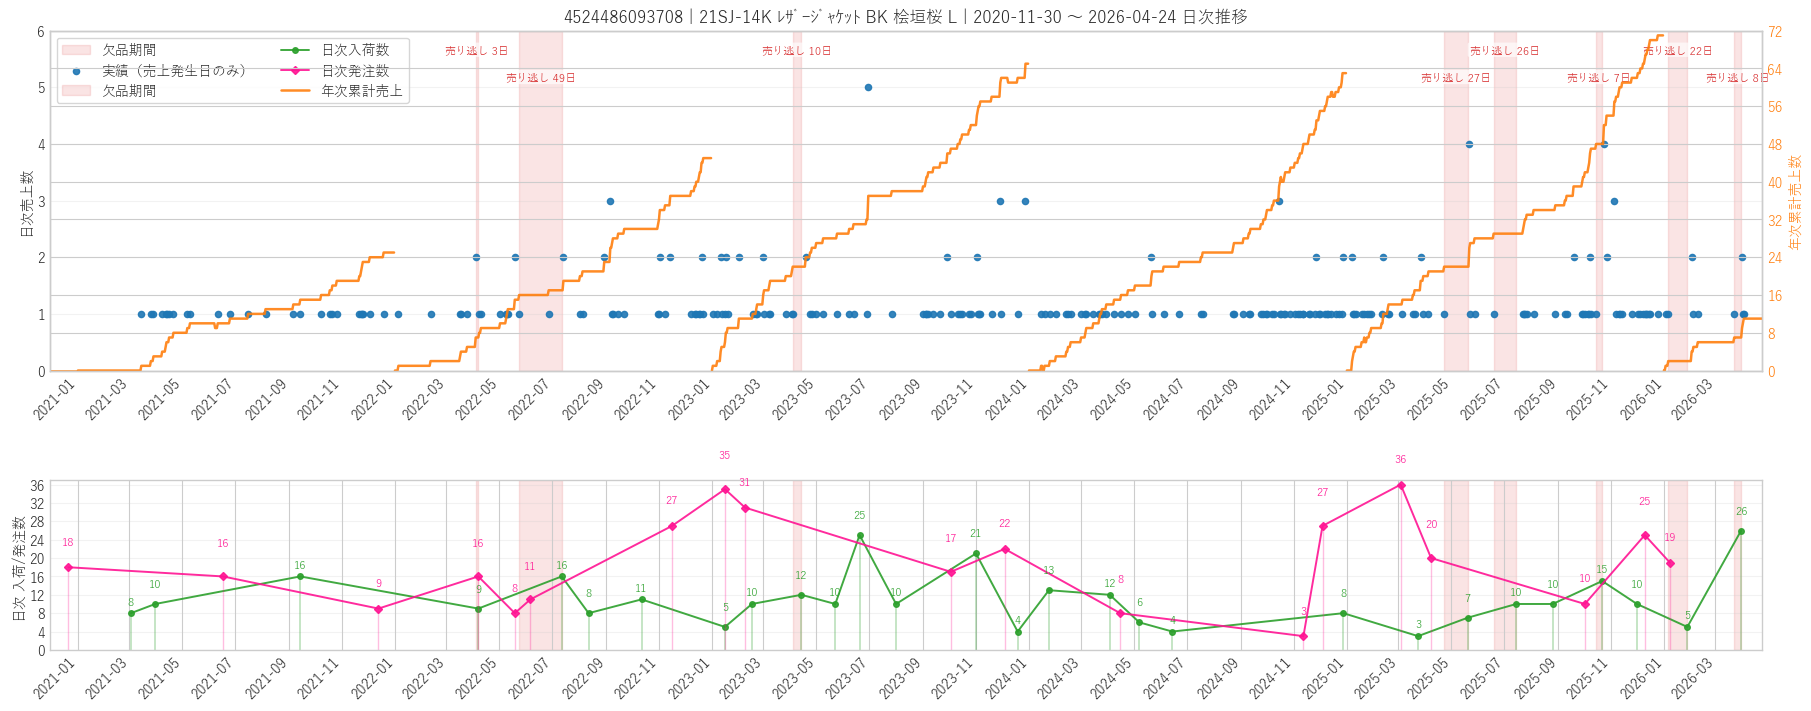

jan                                   4524486093708
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 桧垣桜 L
sales_total_qty                               280.0
sales_days                                      249
receipt_total_qty                             304.0
receipt_days                                     28
order_total_qty                               358.0
order_days                                       19
stockout_periods                                  8
stockout_total_days                           152.0
[2/53] 4524486093678


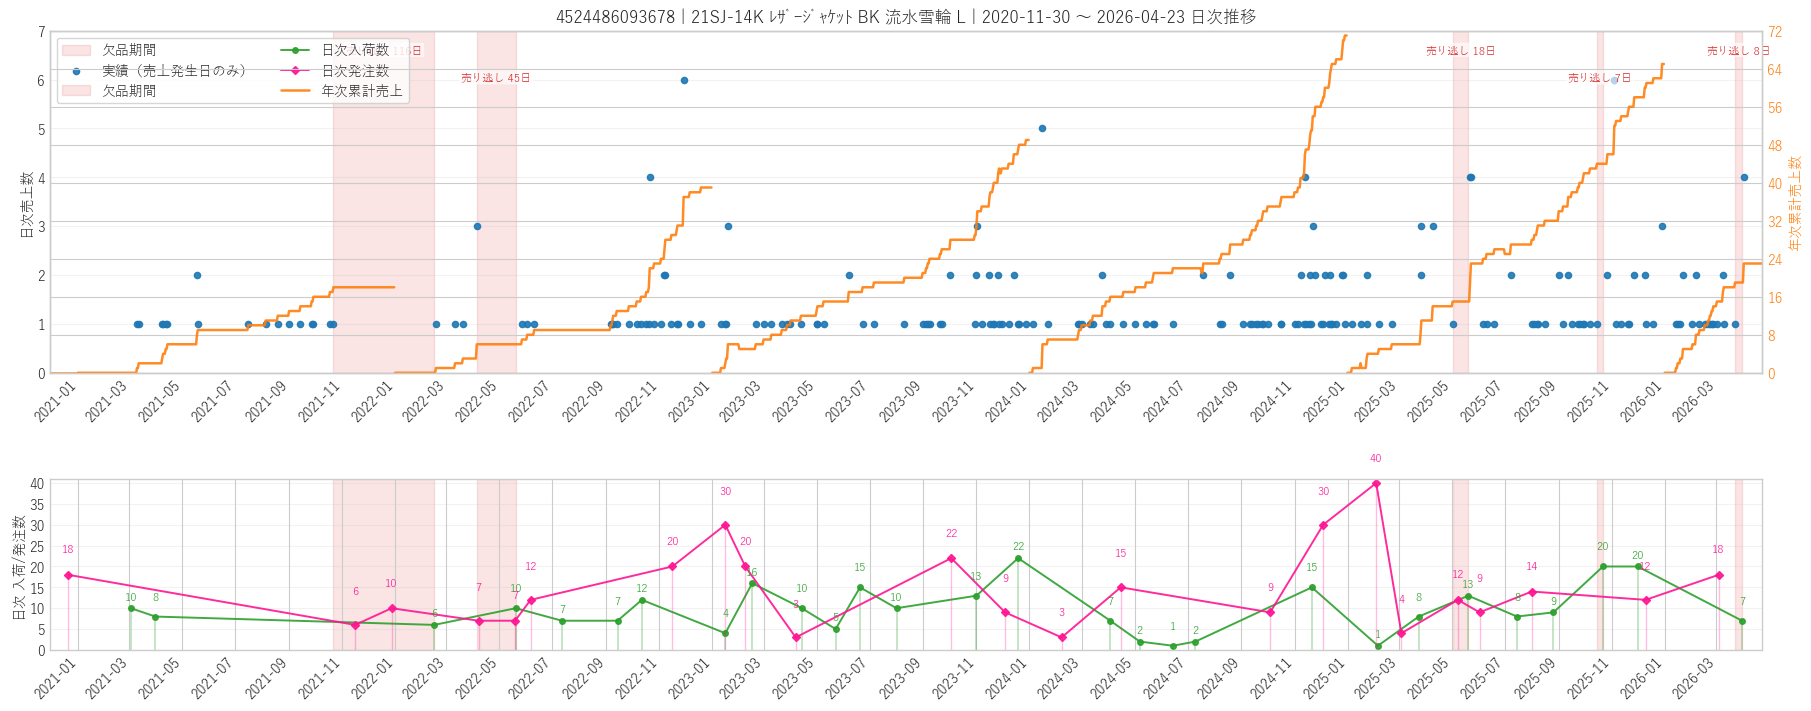

jan                                    4524486093678
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 流水雪輪 L
sales_total_qty                                265.0
sales_days                                       202
receipt_total_qty                              268.0
receipt_days                                      28
order_total_qty                                330.0
order_days                                        23
stockout_periods                                   5
stockout_total_days                            194.0
[3/53] 4524486093685


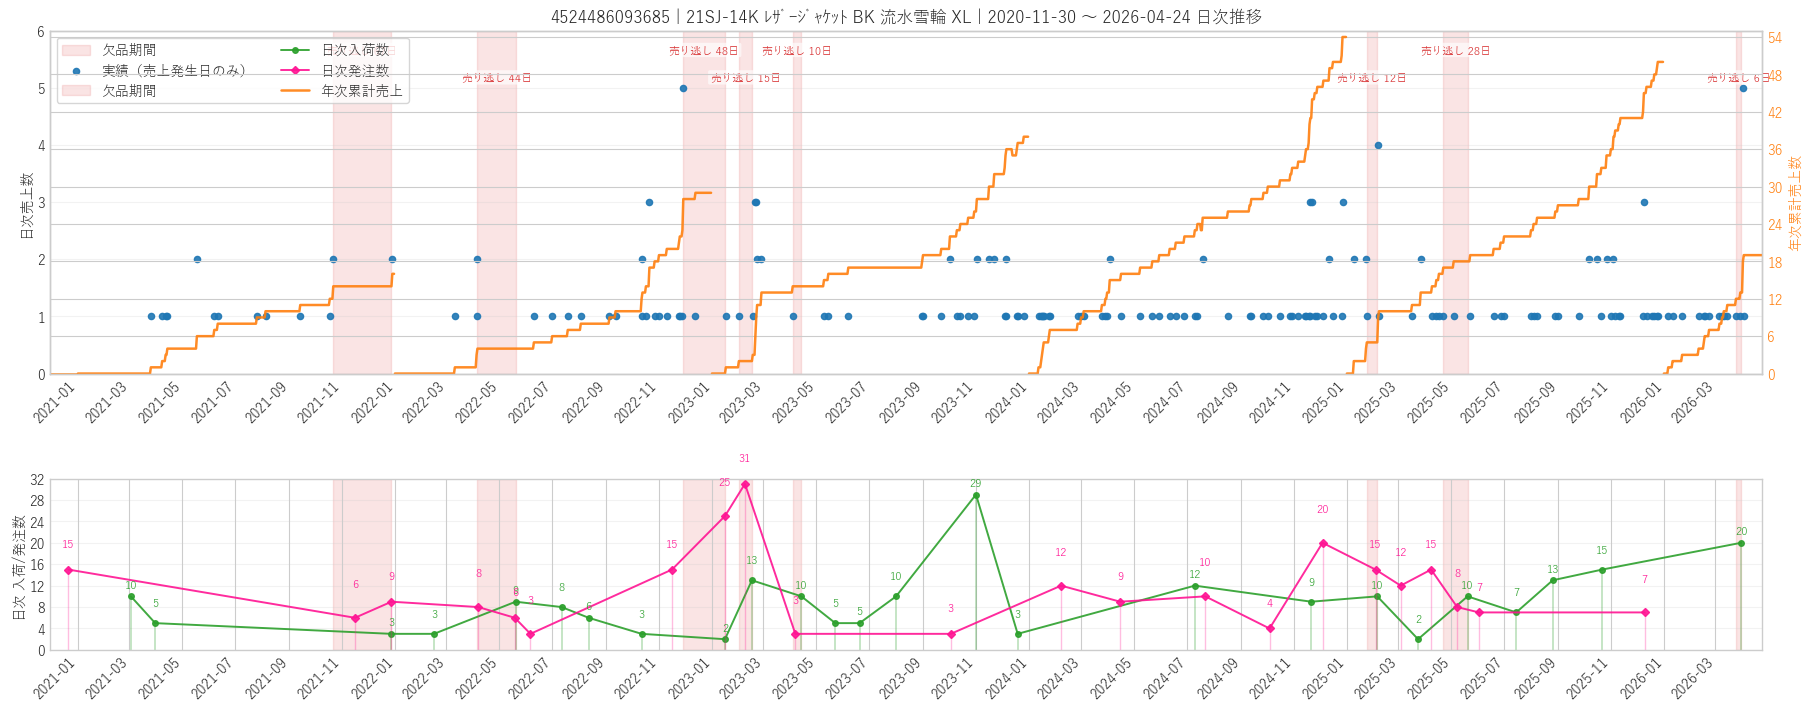

jan                                     4524486093685
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 流水雪輪 XL
sales_total_qty                                 206.0
sales_days                                        164
receipt_total_qty                               222.0
receipt_days                                       25
order_total_qty                                 243.0
order_days                                         22
stockout_periods                                    8
stockout_total_days                             230.0
[4/53] 4524486093692


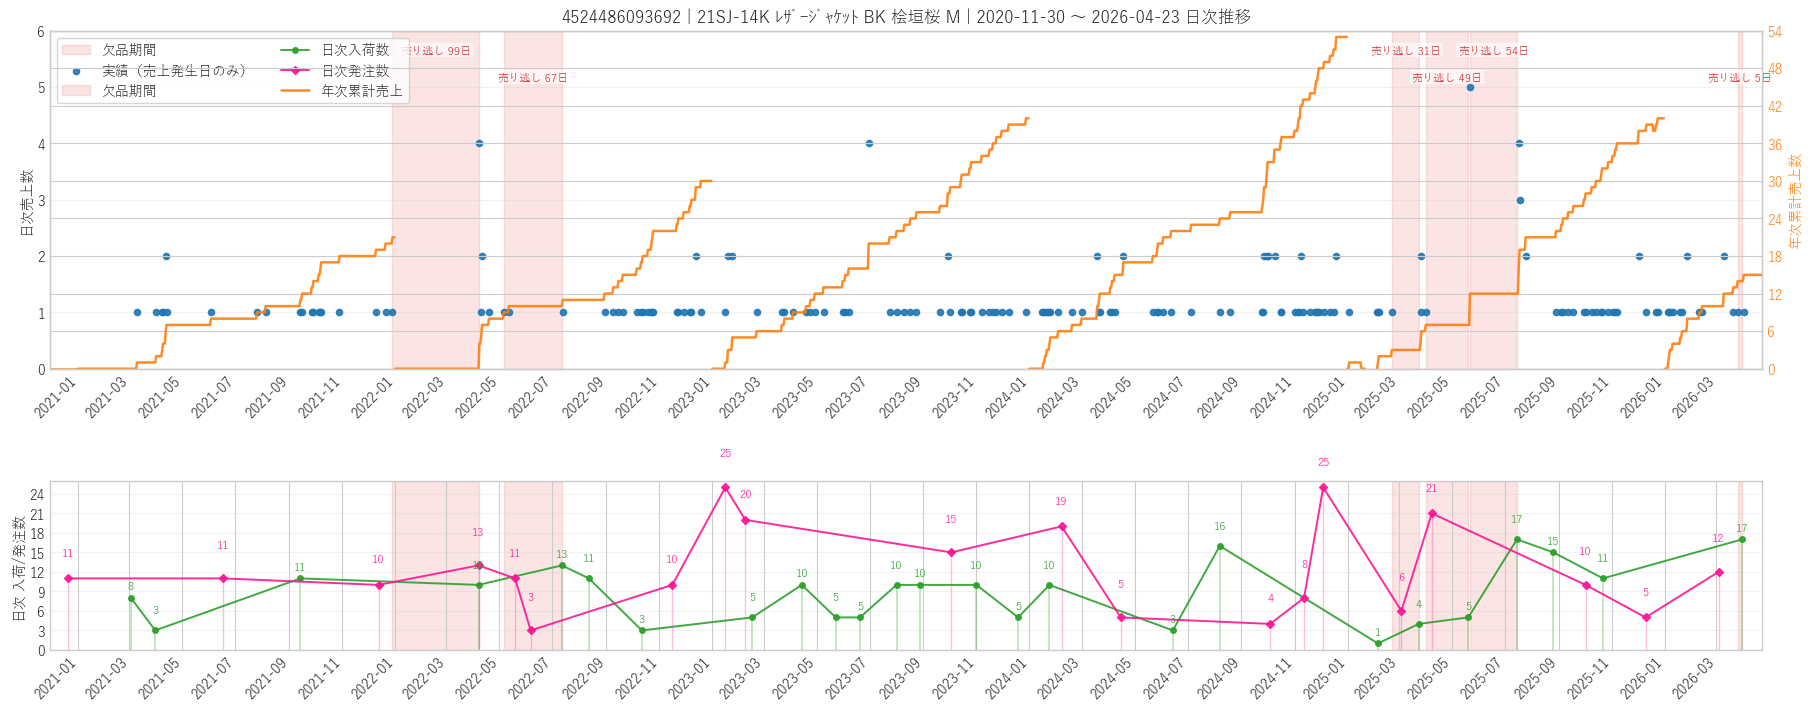

jan                                   4524486093692
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 桧垣桜 M
sales_total_qty                               199.0
sales_days                                      174
receipt_total_qty                             218.0
receipt_days                                     25
order_total_qty                               244.0
order_days                                       20
stockout_periods                                  6
stockout_total_days                           305.0
[5/53] 4524486093715


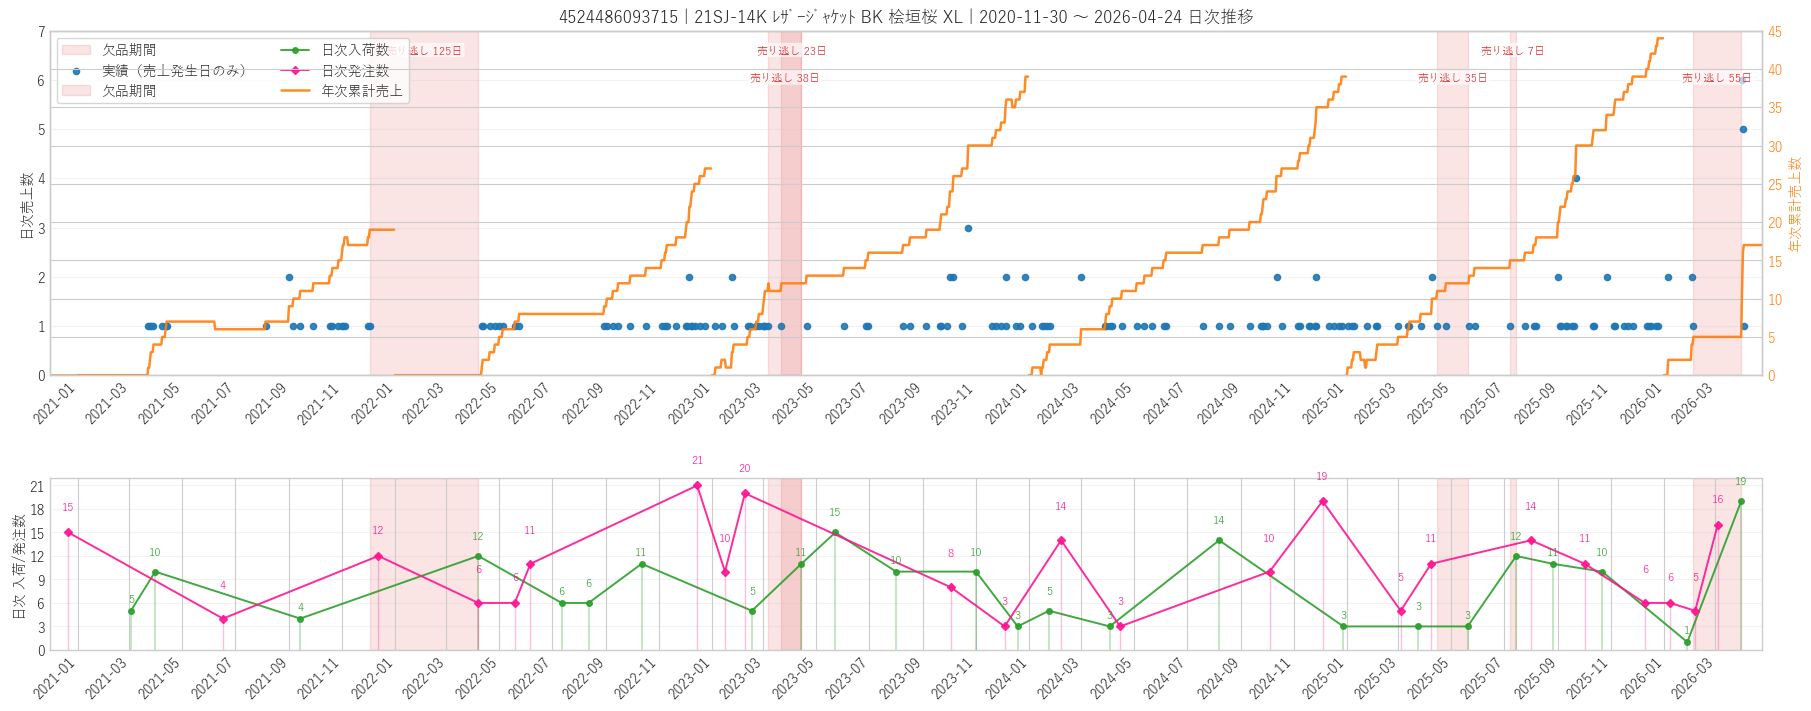

jan                                    4524486093715
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 桧垣桜 XL
sales_total_qty                                185.0
sales_days                                       174
receipt_total_qty                              192.0
receipt_days                                      24
order_total_qty                                236.0
order_days                                        23
stockout_periods                                   6
stockout_total_days                            283.0
[6/53] 4524486093661


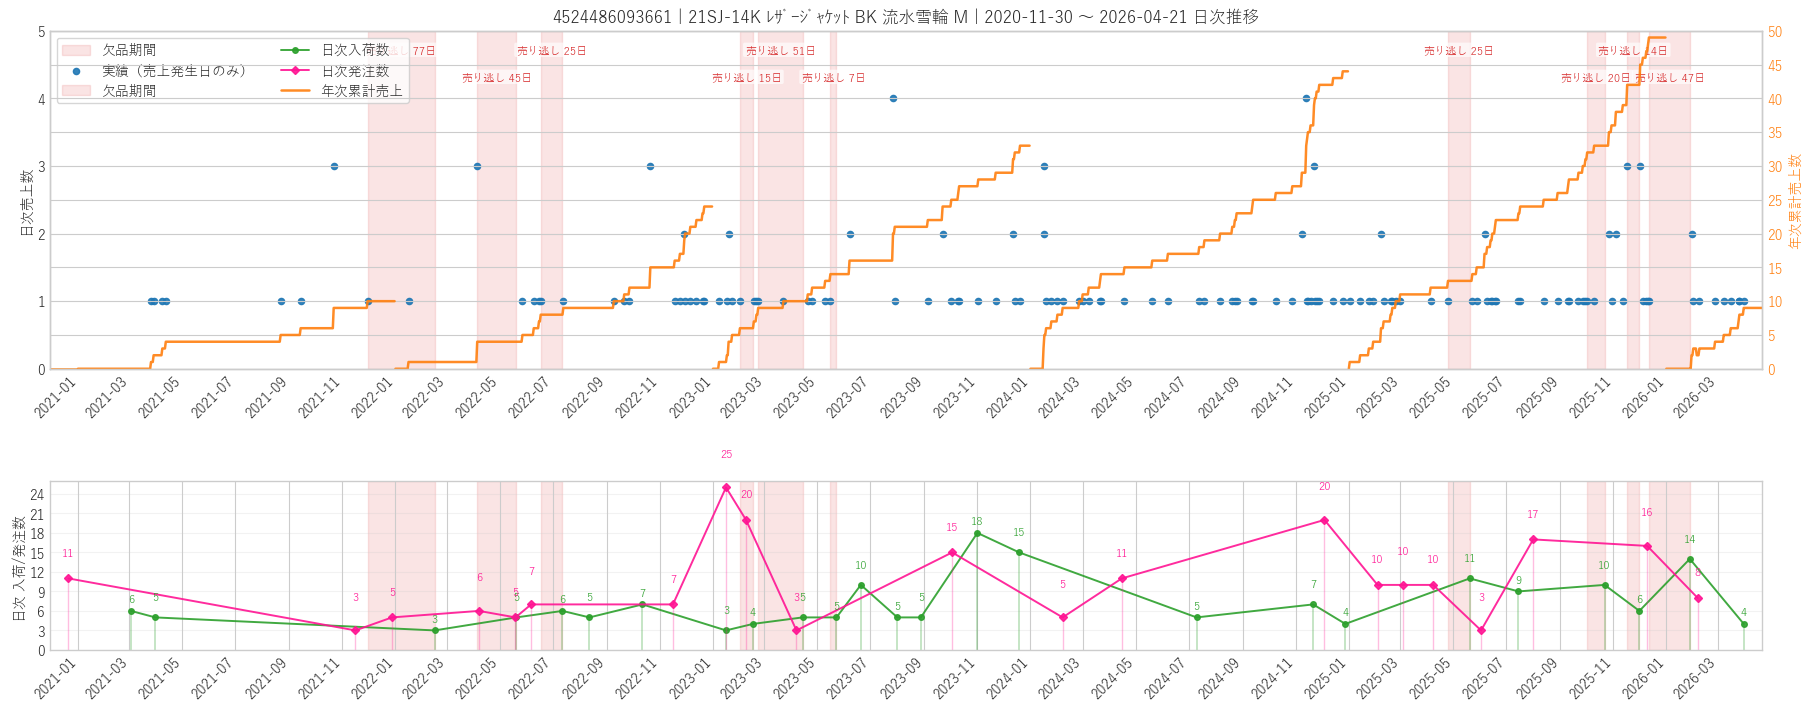

jan                                    4524486093661
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 流水雪輪 M
sales_total_qty                                169.0
sales_days                                       139
receipt_total_qty                              177.0
receipt_days                                      25
order_total_qty                                217.0
order_days                                        21
stockout_periods                                  10
stockout_total_days                            326.0
[7/53] 4524486094965


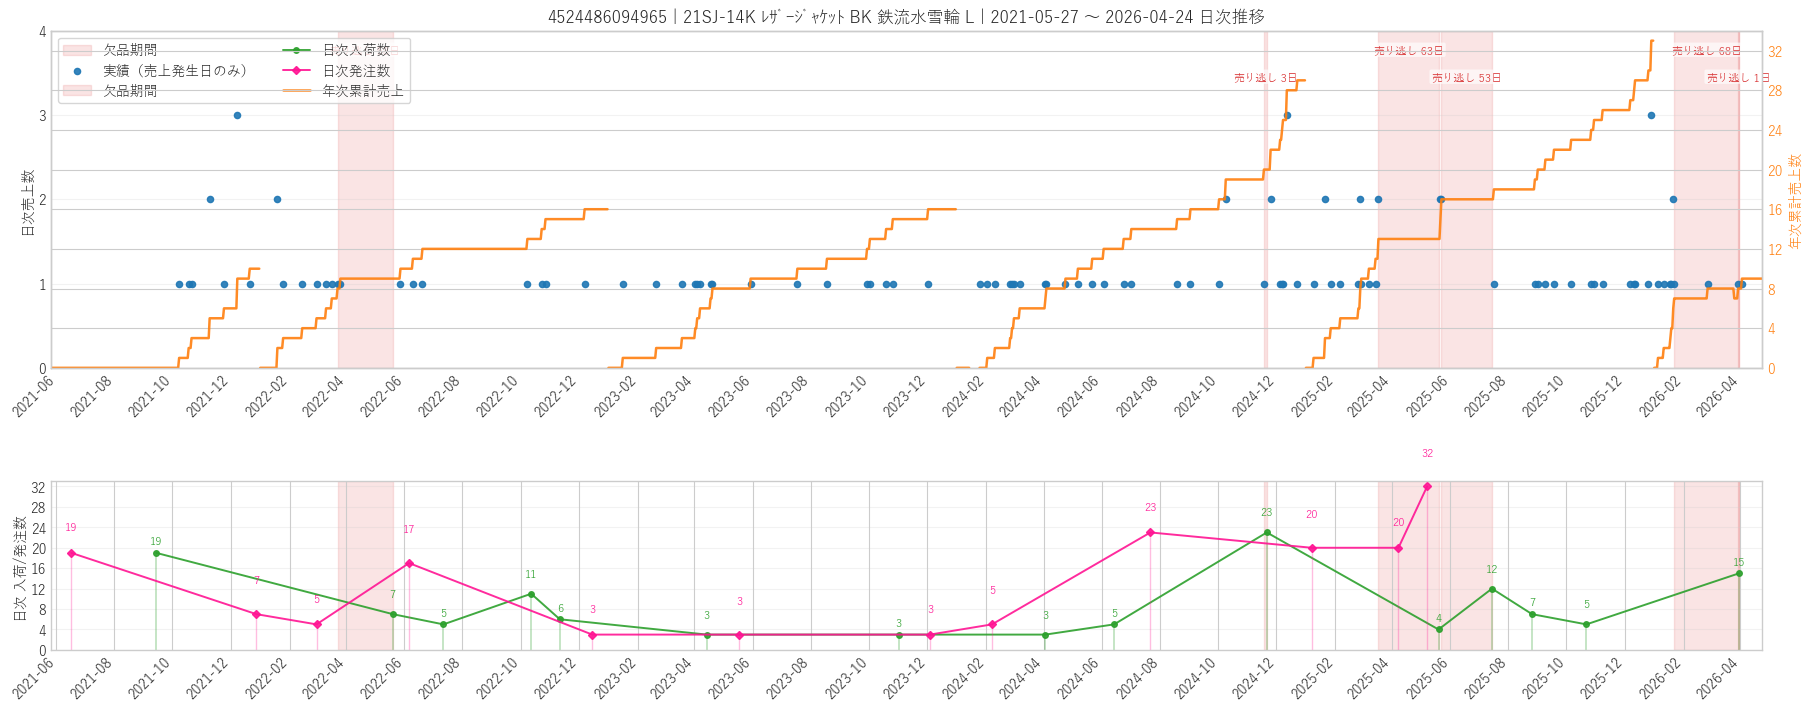

jan                                     4524486094965
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 鉄流水雪輪 L
sales_total_qty                                 113.0
sales_days                                        101
receipt_total_qty                               128.0
receipt_days                                       15
order_total_qty                                 157.0
order_days                                         12
stockout_periods                                    6
stockout_total_days                             246.0
[8/53] 4524486094972


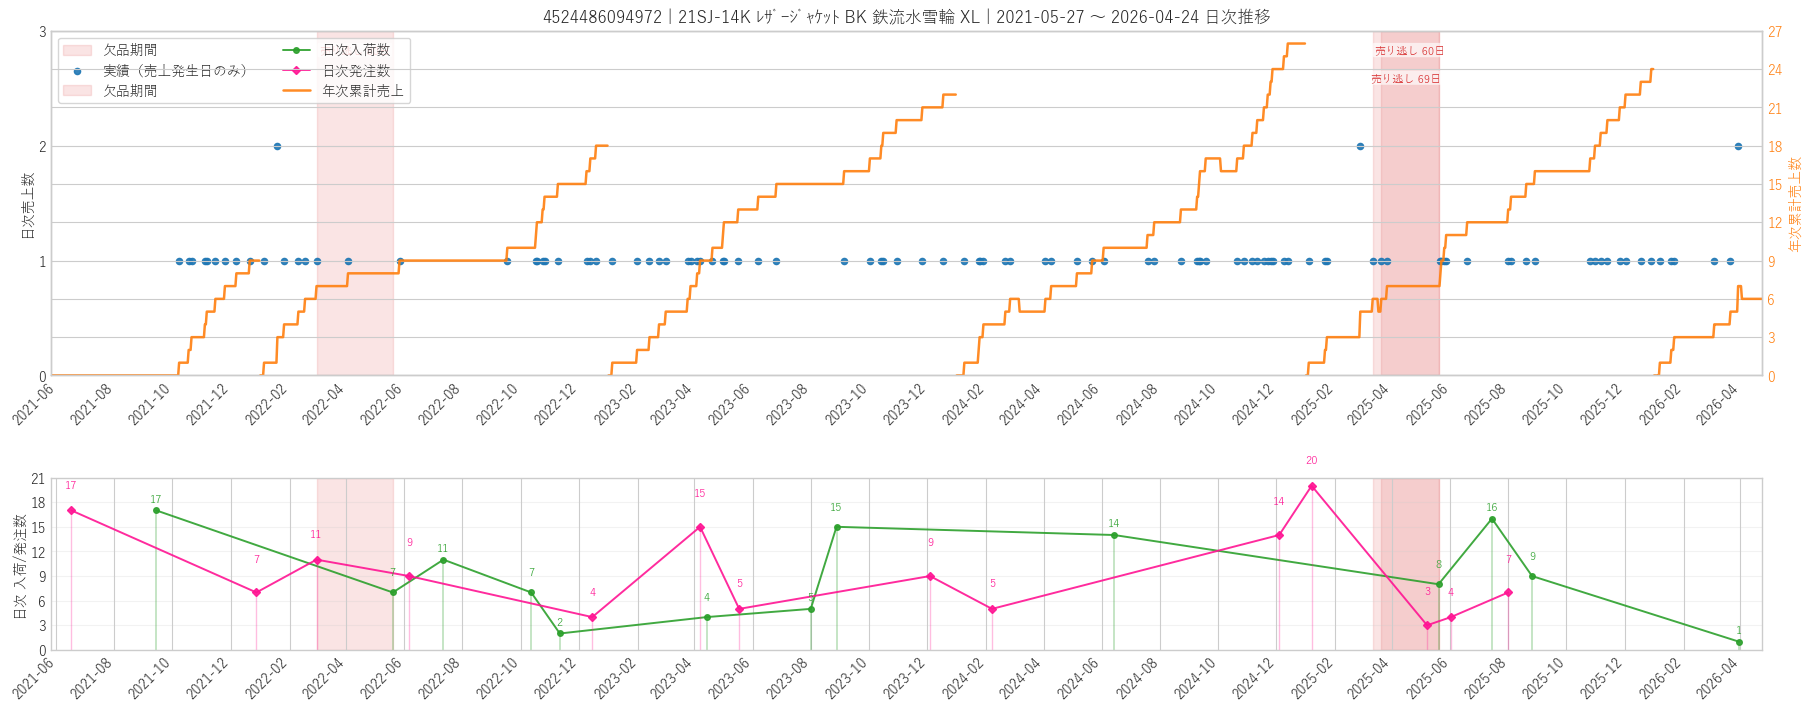

jan                                      4524486094972
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 鉄流水雪輪 XL
sales_total_qty                                  105.0
sales_days                                         110
receipt_total_qty                                116.0
receipt_days                                        13
order_total_qty                                  130.0
order_days                                          14
stockout_periods                                     3
stockout_total_days                              209.0
[9/53] 4524486103247


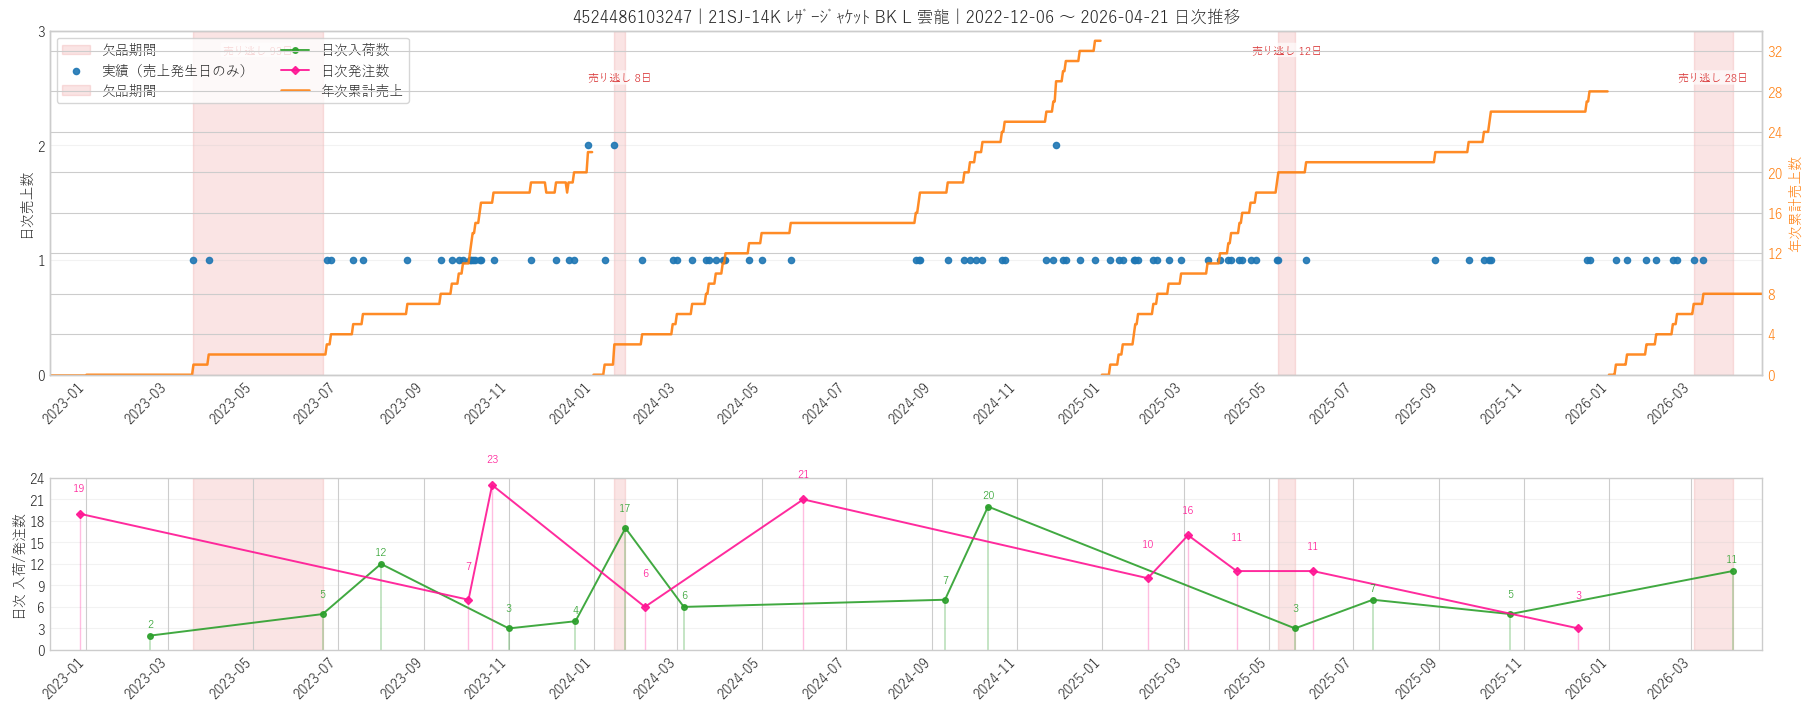

jan                                  4524486103247
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK L 雲龍
sales_total_qty                               91.0
sales_days                                      92
receipt_total_qty                            102.0
receipt_days                                    13
order_total_qty                              127.0
order_days                                      10
stockout_periods                                 4
stockout_total_days                          141.0
[10/53] 4524486093647


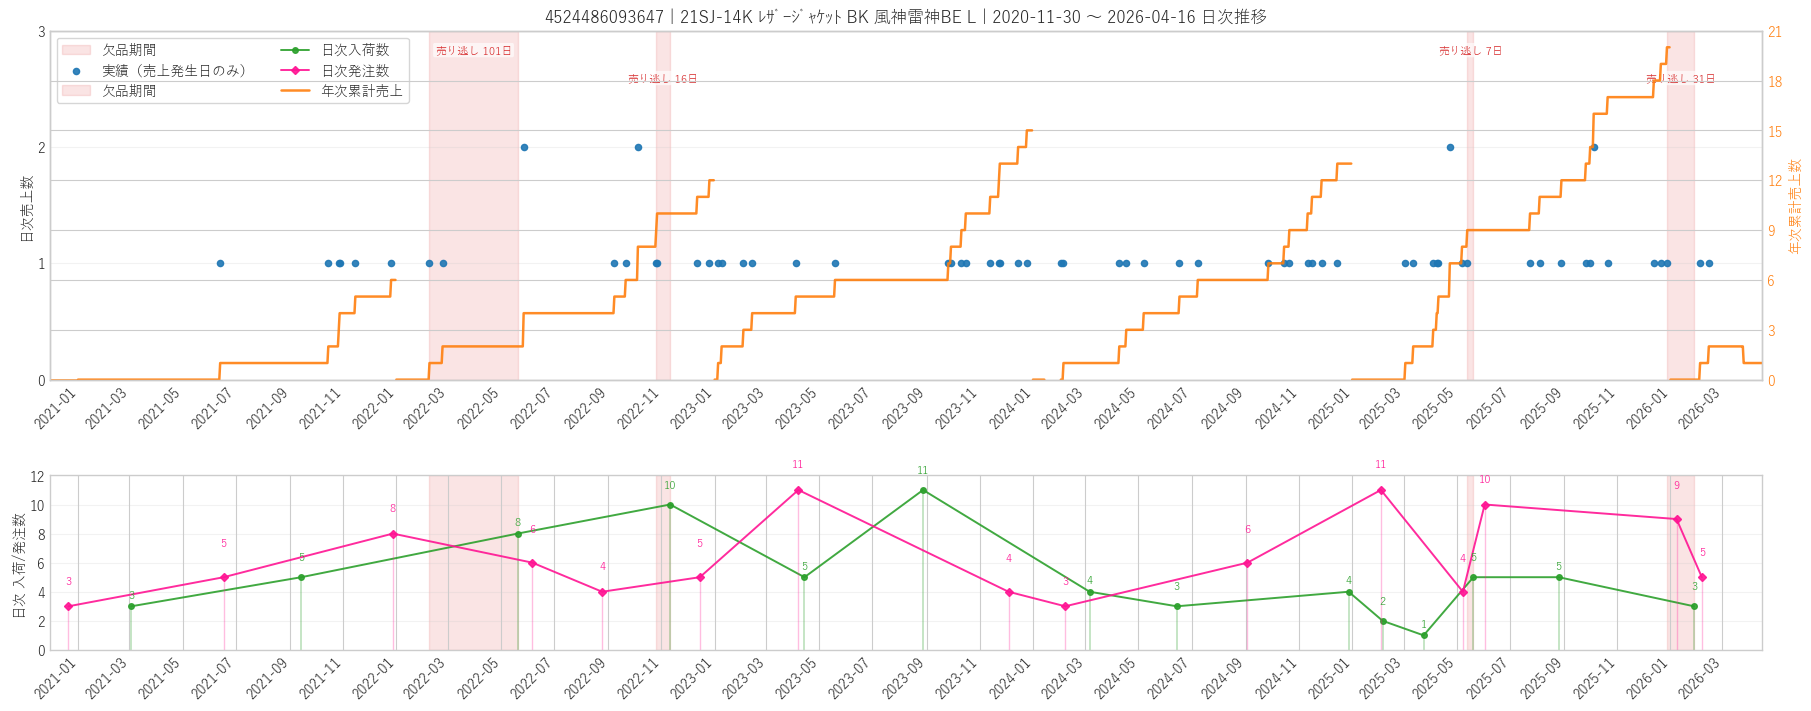

jan                                      4524486093647
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 風神雷神BE L
sales_total_qty                                   67.0
sales_days                                          67
receipt_total_qty                                 69.0
receipt_days                                        14
order_total_qty                                   94.0
order_days                                          15
stockout_periods                                     4
stockout_total_days                              155.0
[11/53] 4524486103254


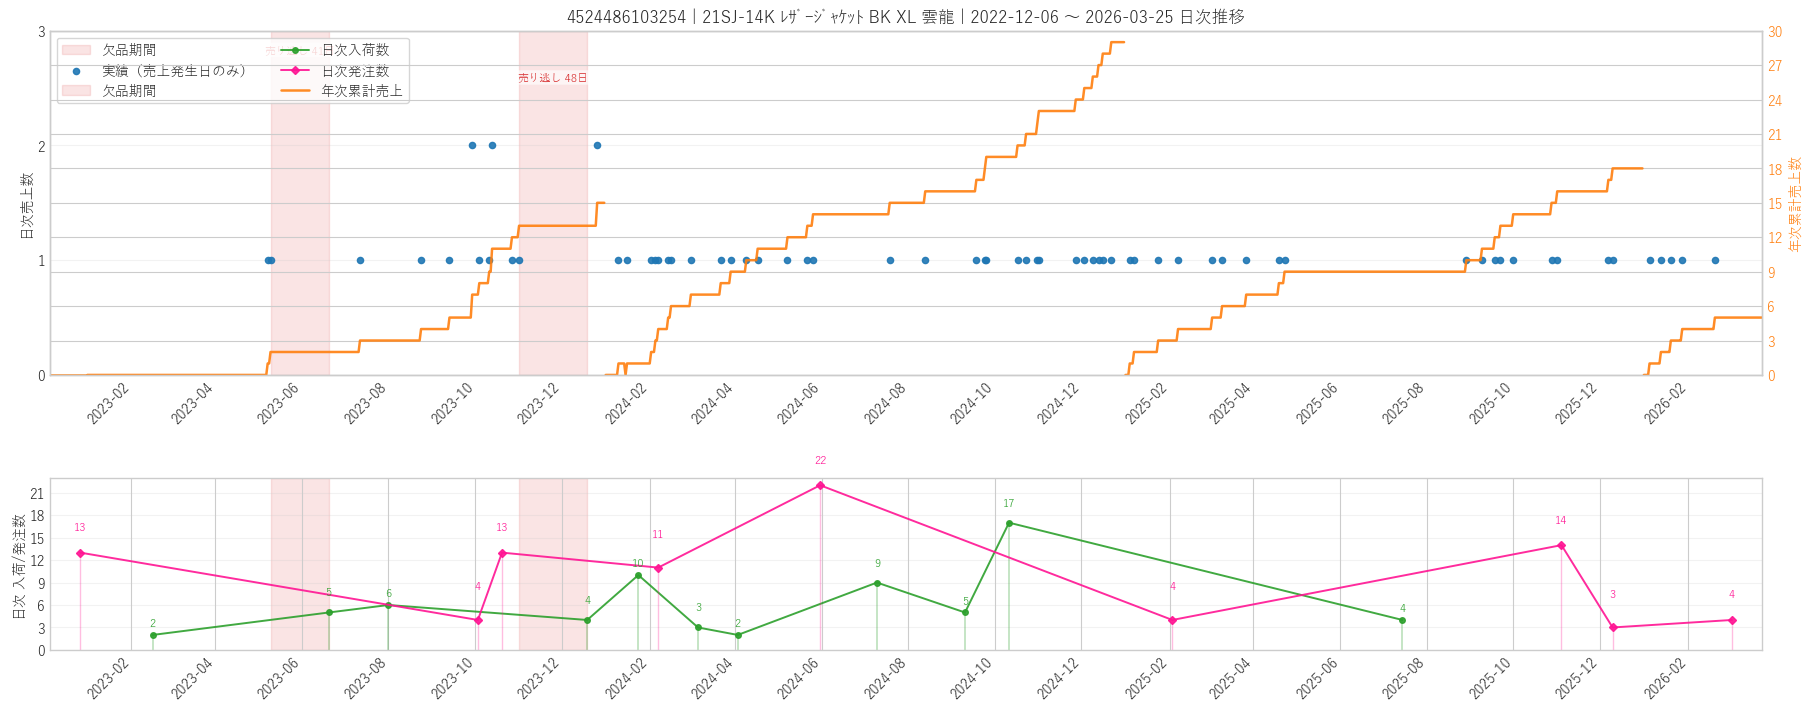

jan                                   4524486103254
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK XL 雲龍
sales_total_qty                                67.0
sales_days                                       66
receipt_total_qty                              67.0
receipt_days                                     11
order_total_qty                                88.0
order_days                                        9
stockout_periods                                  2
stockout_total_days                            89.0
[12/53] 4524486106545


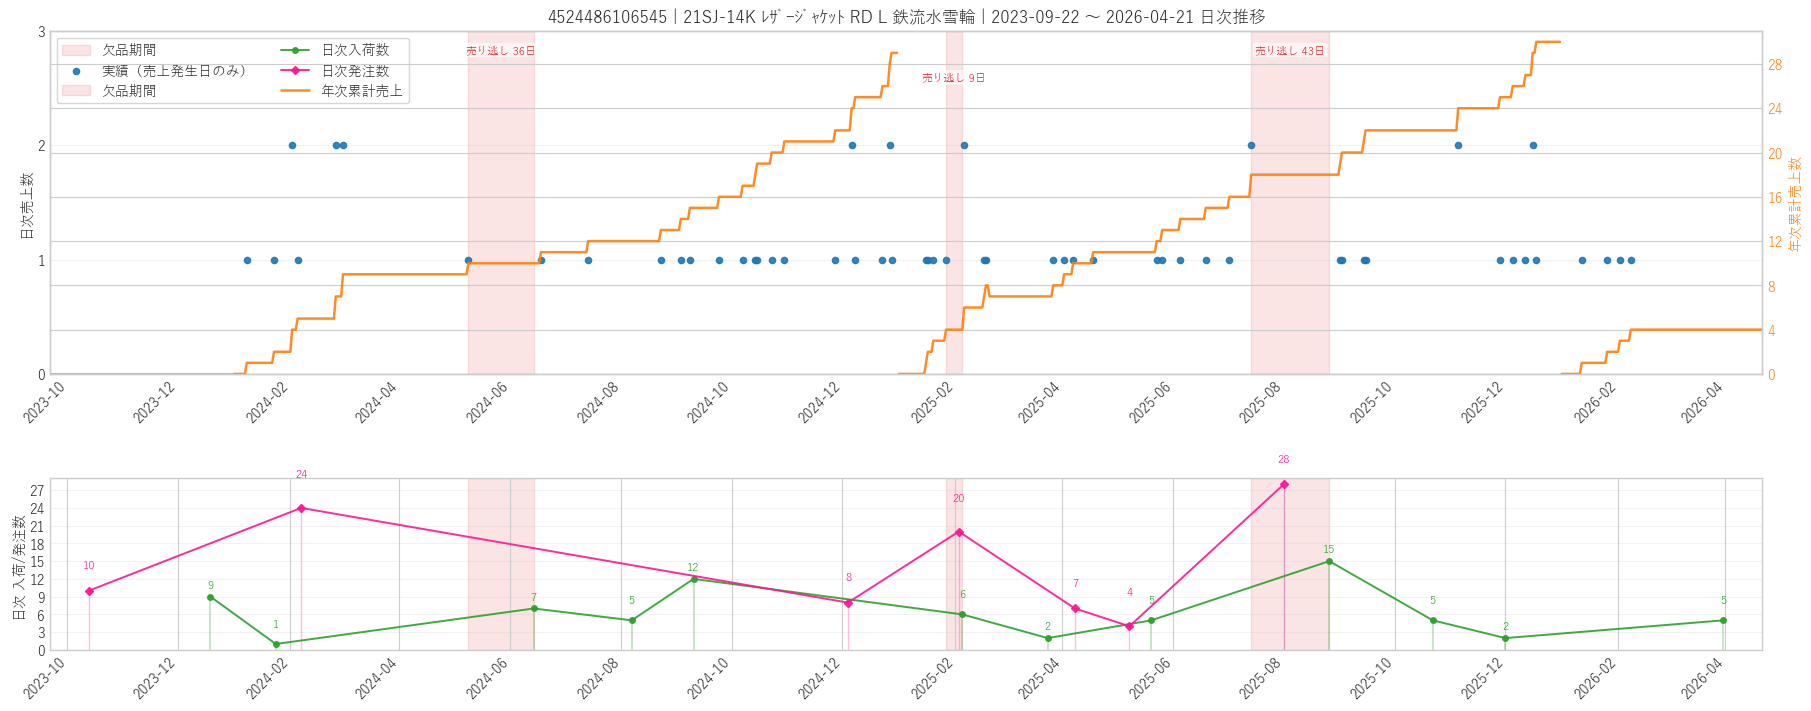

jan                                     4524486106545
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ RD L 鉄流水雪輪
sales_total_qty                                  63.0
sales_days                                         56
receipt_total_qty                                74.0
receipt_days                                       12
order_total_qty                                 101.0
order_days                                          7
stockout_periods                                    3
stockout_total_days                              88.0
[13/53] 4524486094958


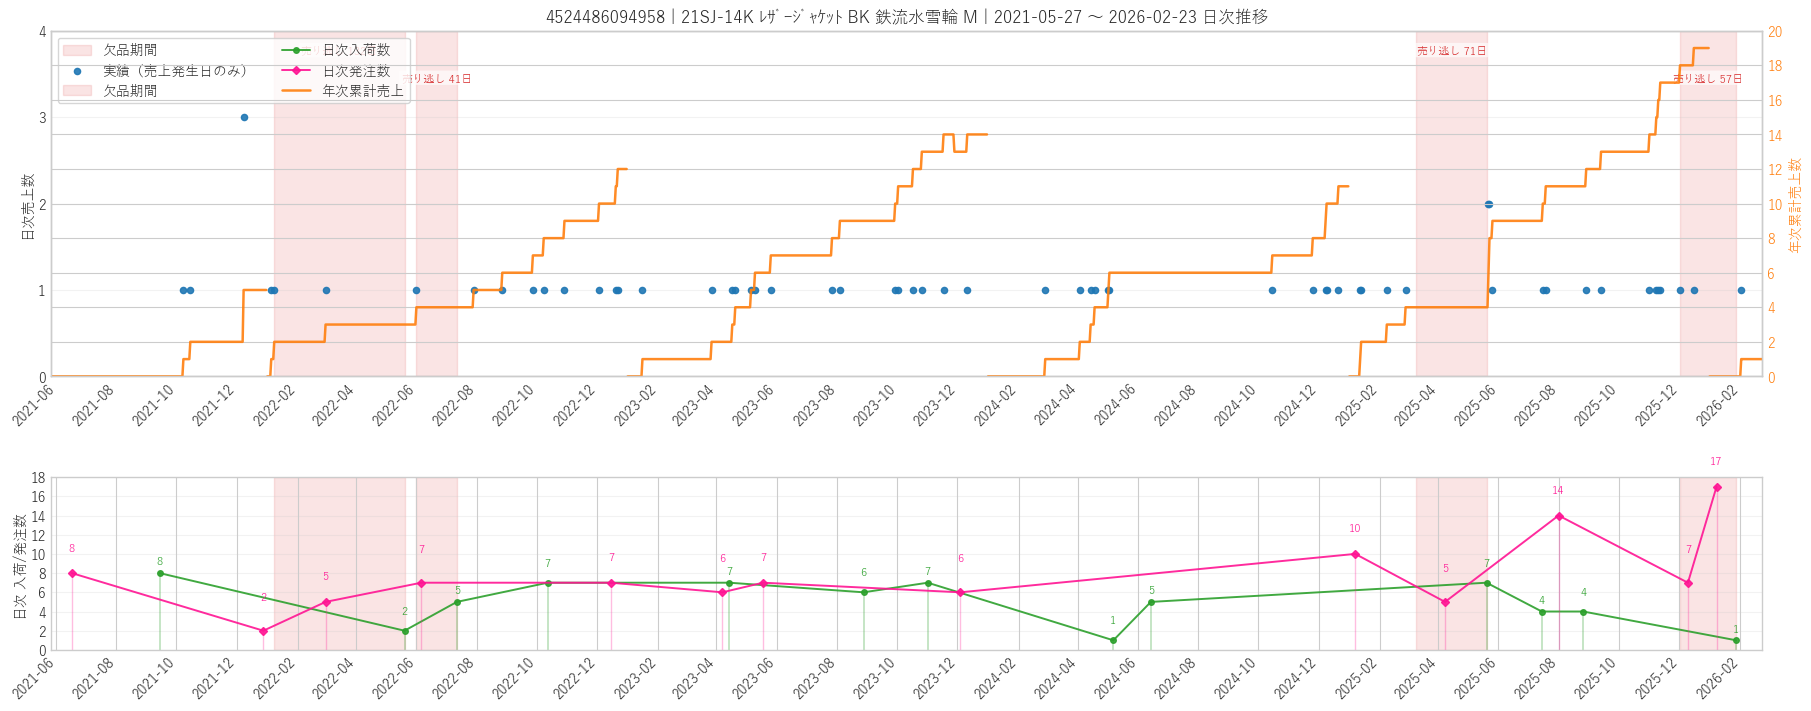

jan                                     4524486094958
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 鉄流水雪輪 M
sales_total_qty                                  62.0
sales_days                                         60
receipt_total_qty                                64.0
receipt_days                                       13
order_total_qty                                 101.0
order_days                                         13
stockout_periods                                    4
stockout_total_days                             301.0
[14/53] 4524486097973


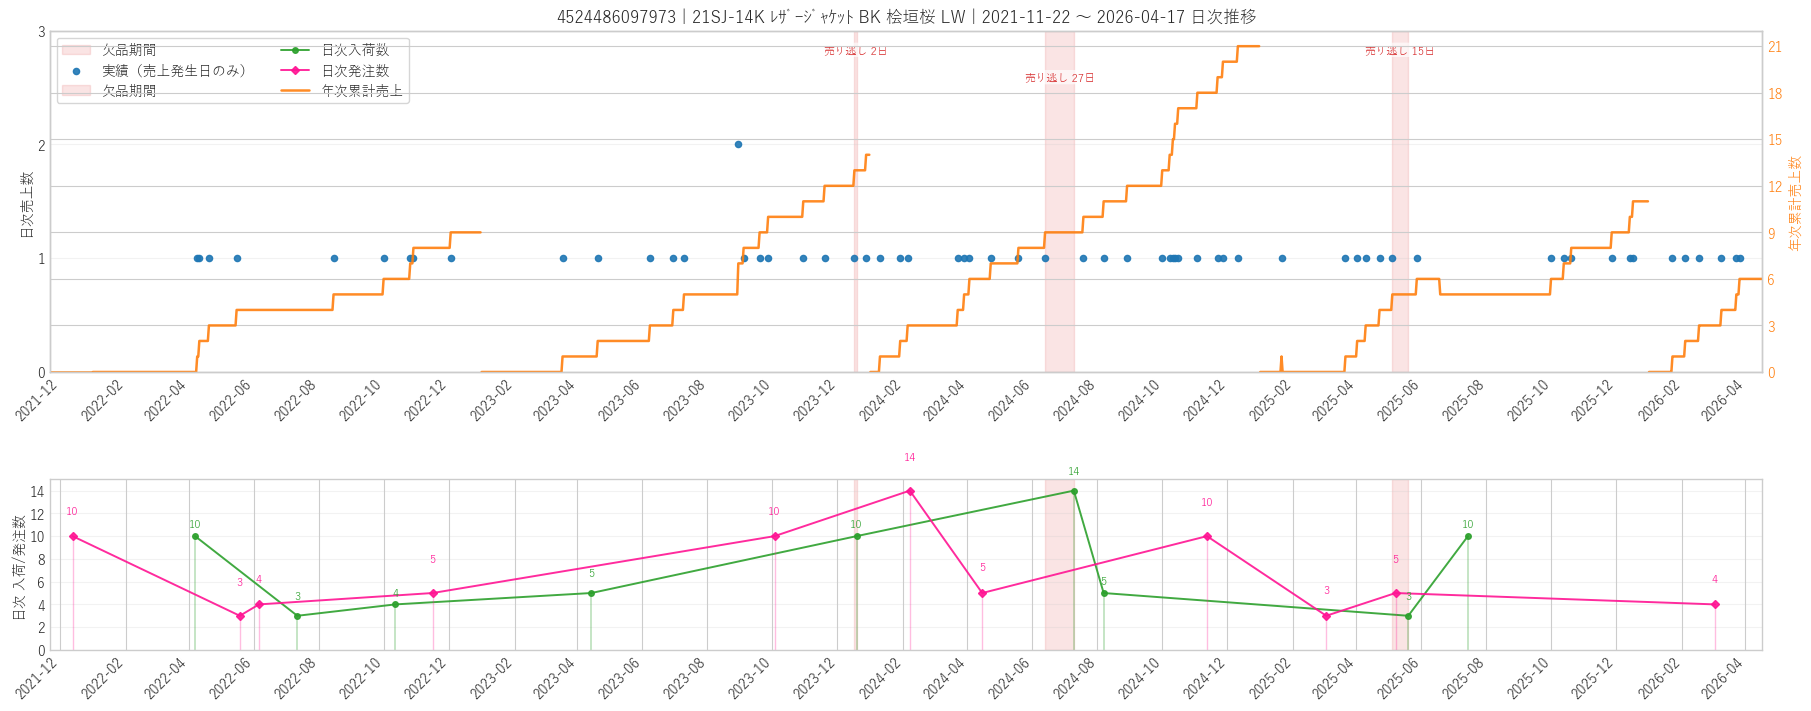

jan                                    4524486097973
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 桧垣桜 LW
sales_total_qty                                 61.0
sales_days                                        65
receipt_total_qty                               64.0
receipt_days                                       9
order_total_qty                                 73.0
order_days                                        11
stockout_periods                                   3
stockout_total_days                             44.0
[15/53] 4524486103230


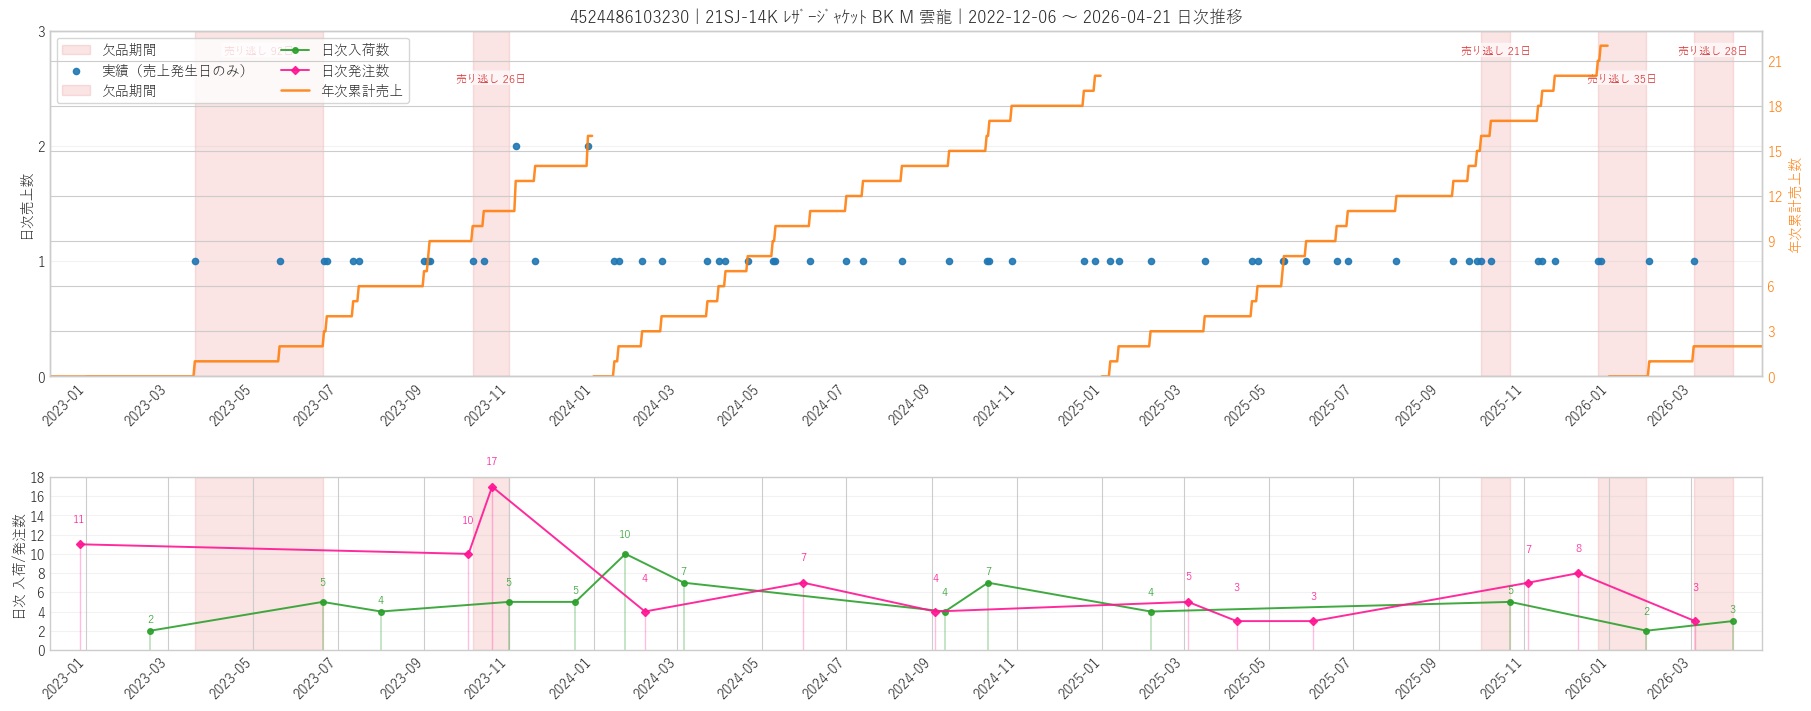

jan                                  4524486103230
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK M 雲龍
sales_total_qty                               60.0
sales_days                                      58
receipt_total_qty                             63.0
receipt_days                                    13
order_total_qty                               82.0
order_days                                      12
stockout_periods                                 5
stockout_total_days                          202.0
[16/53] 4524486106552


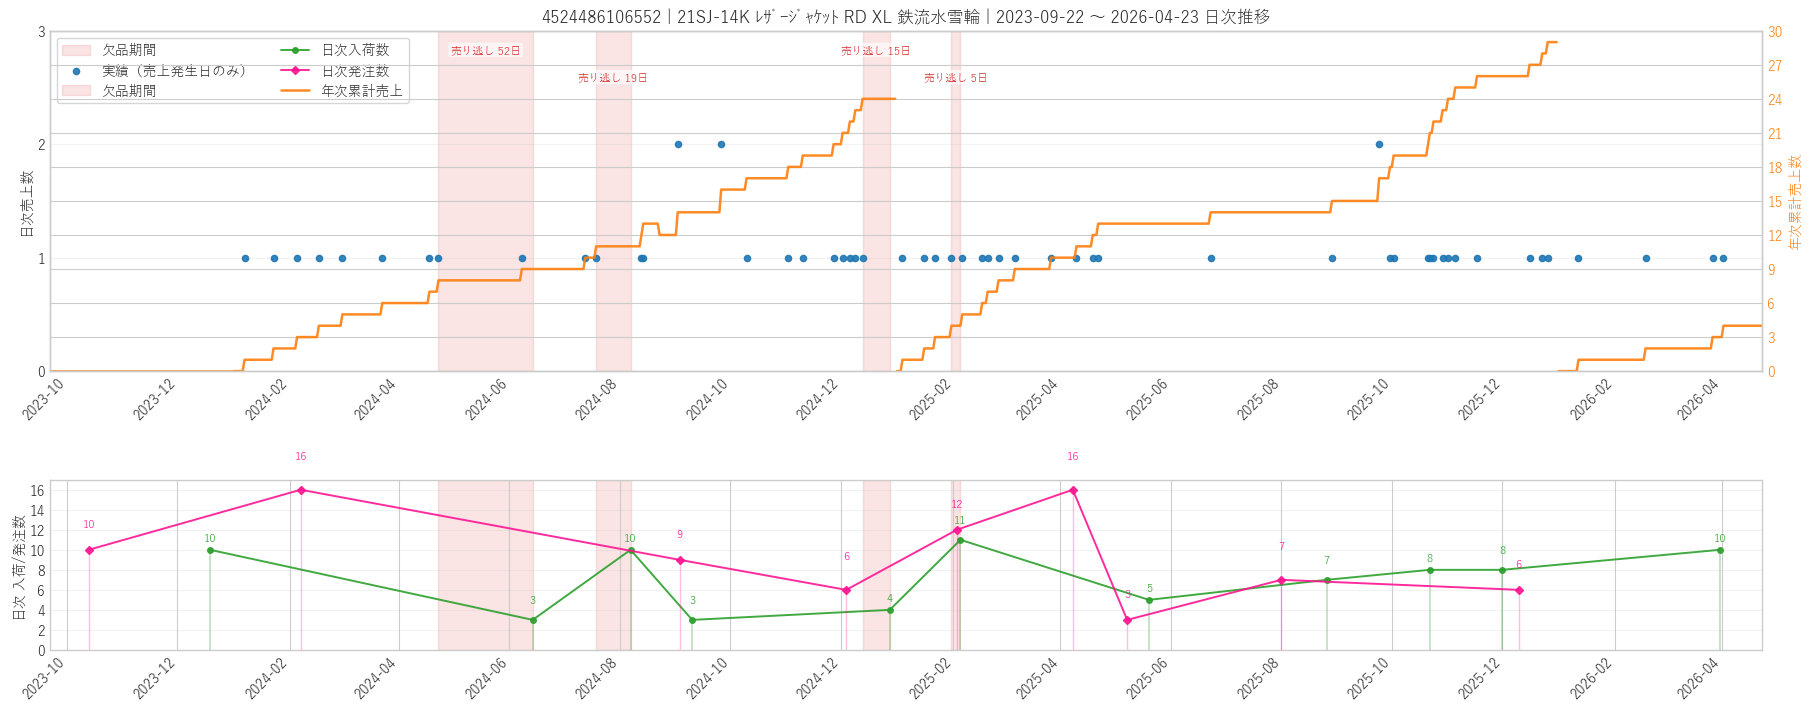

jan                                      4524486106552
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ RD XL 鉄流水雪輪
sales_total_qty                                   57.0
sales_days                                          56
receipt_total_qty                                 79.0
receipt_days                                        11
order_total_qty                                   85.0
order_days                                           9
stockout_periods                                     4
stockout_total_days                               91.0
[17/53] 4524486097959


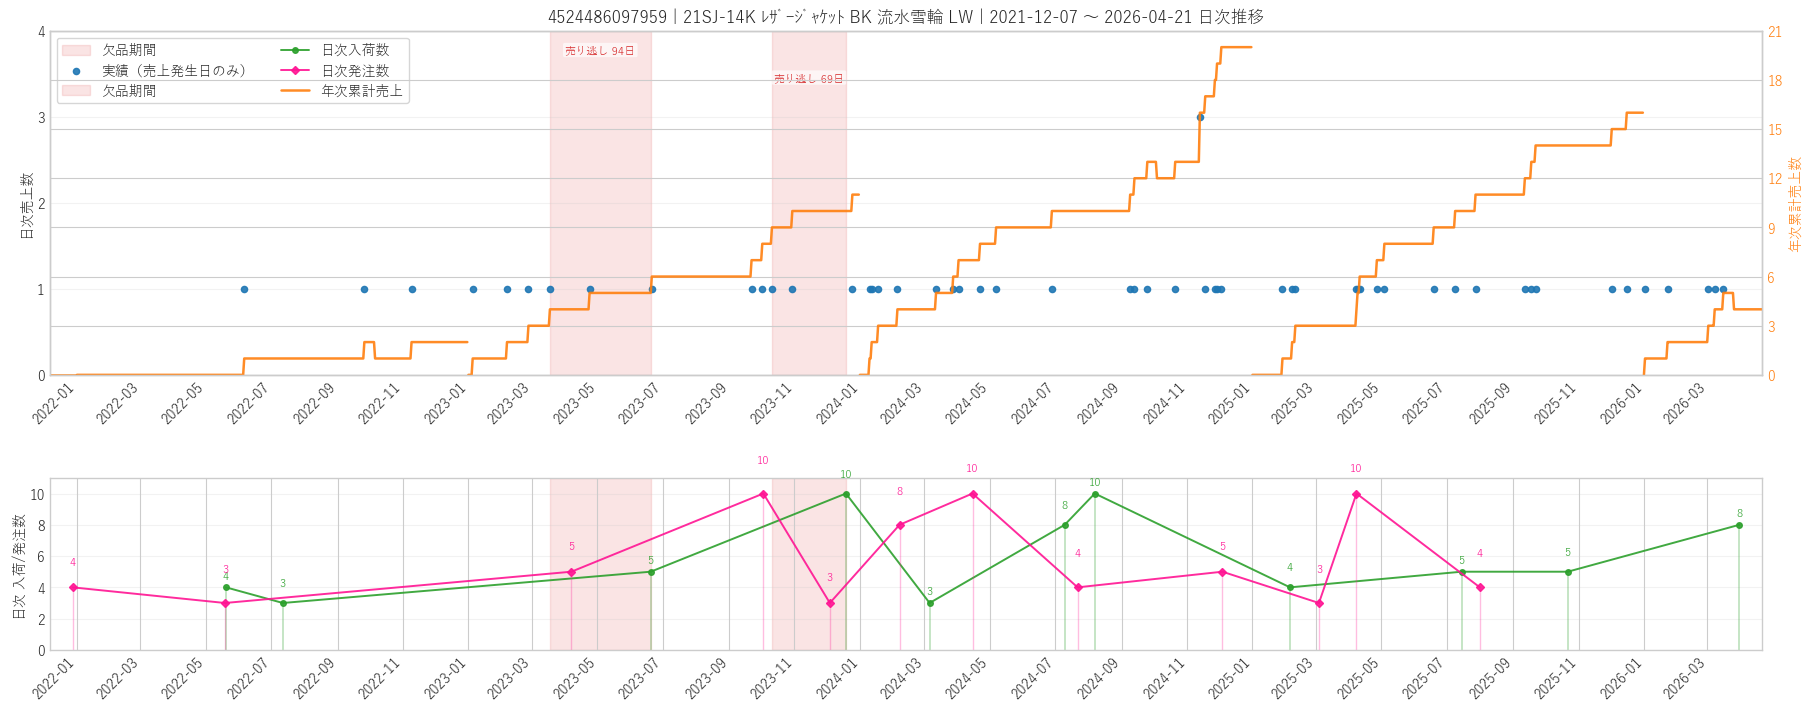

jan                                     4524486097959
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 流水雪輪 LW
sales_total_qty                                  53.0
sales_days                                         57
receipt_total_qty                                65.0
receipt_days                                       11
order_total_qty                                  69.0
order_days                                         12
stockout_periods                                    2
stockout_total_days                             163.0
[18/53] 4524486109492


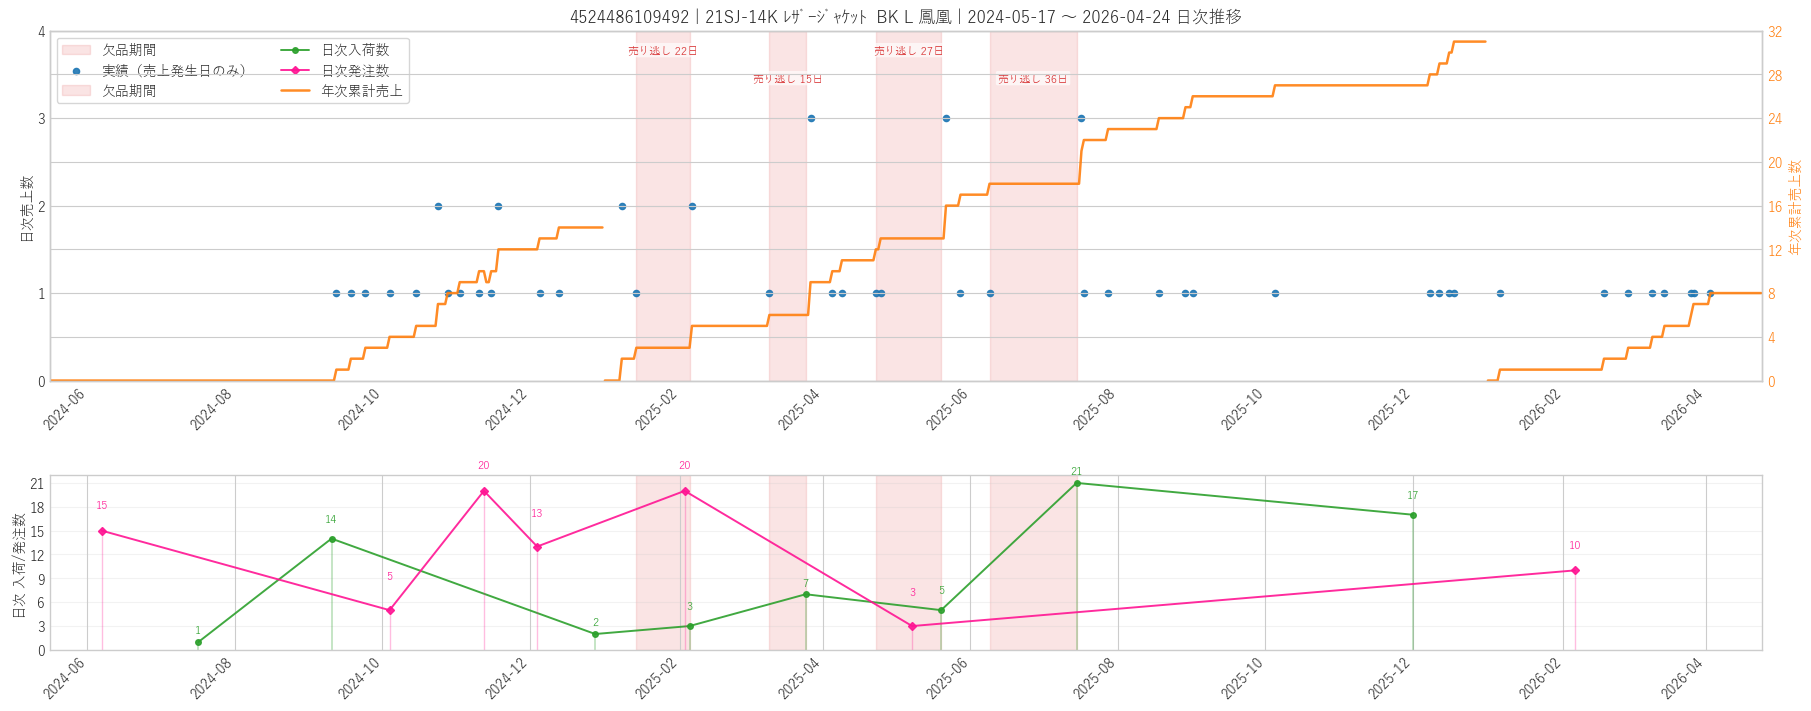

jan                                   4524486109492
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ  BK L 鳳凰
sales_total_qty                                53.0
sales_days                                       45
receipt_total_qty                              70.0
receipt_days                                      8
order_total_qty                                86.0
order_days                                        7
stockout_periods                                  4
stockout_total_days                           100.0
[19/53] 4524486109508


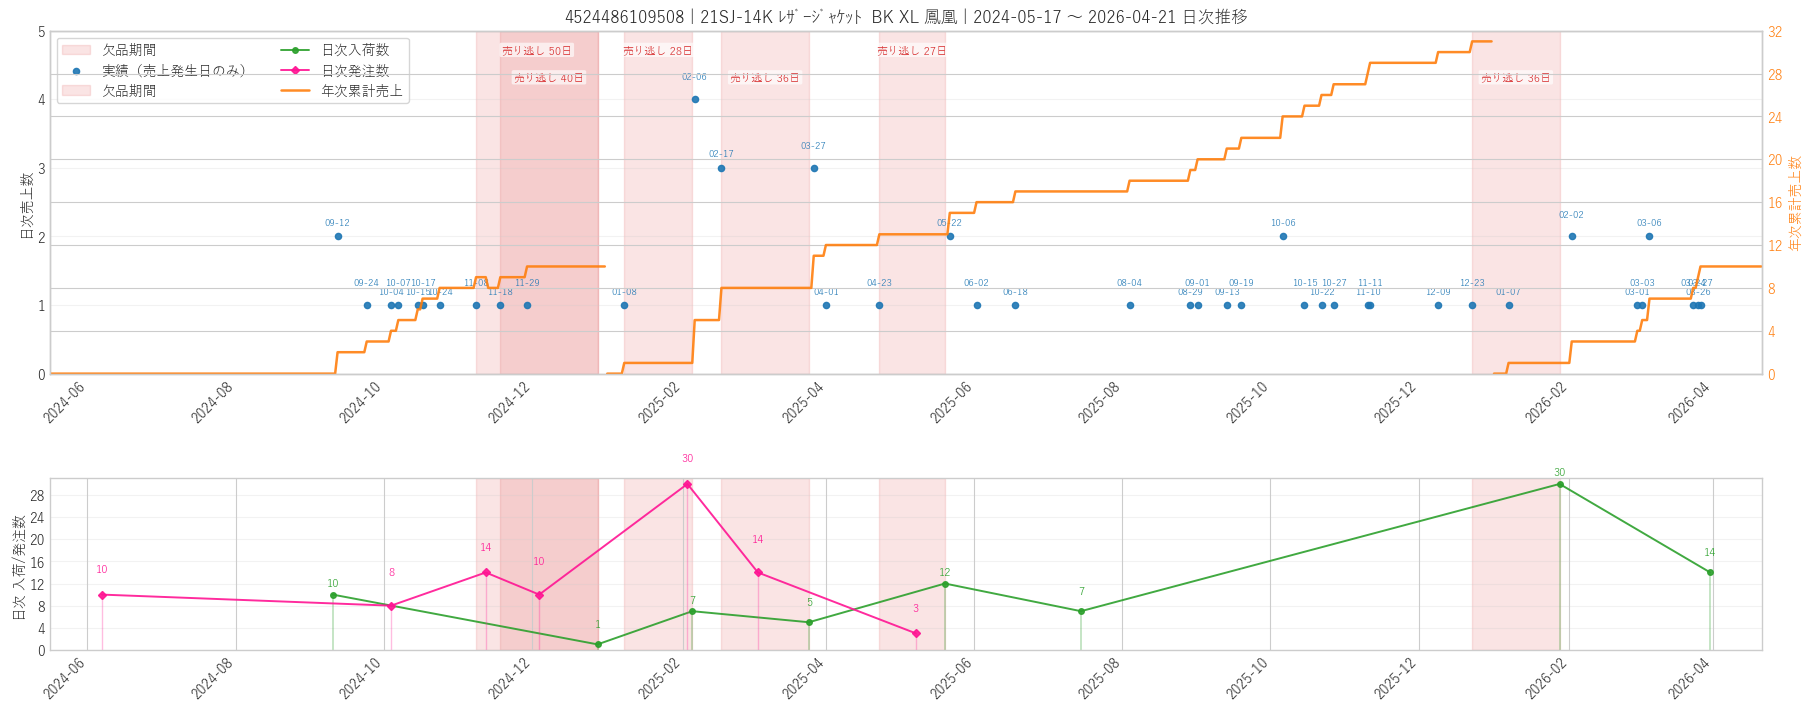

jan                                    4524486109508
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ  BK XL 鳳凰
sales_total_qty                                 51.0
sales_days                                        41
receipt_total_qty                               86.0
receipt_days                                       8
order_total_qty                                 89.0
order_days                                         7
stockout_periods                                   6
stockout_total_days                            217.0
[20/53] 4524486093654


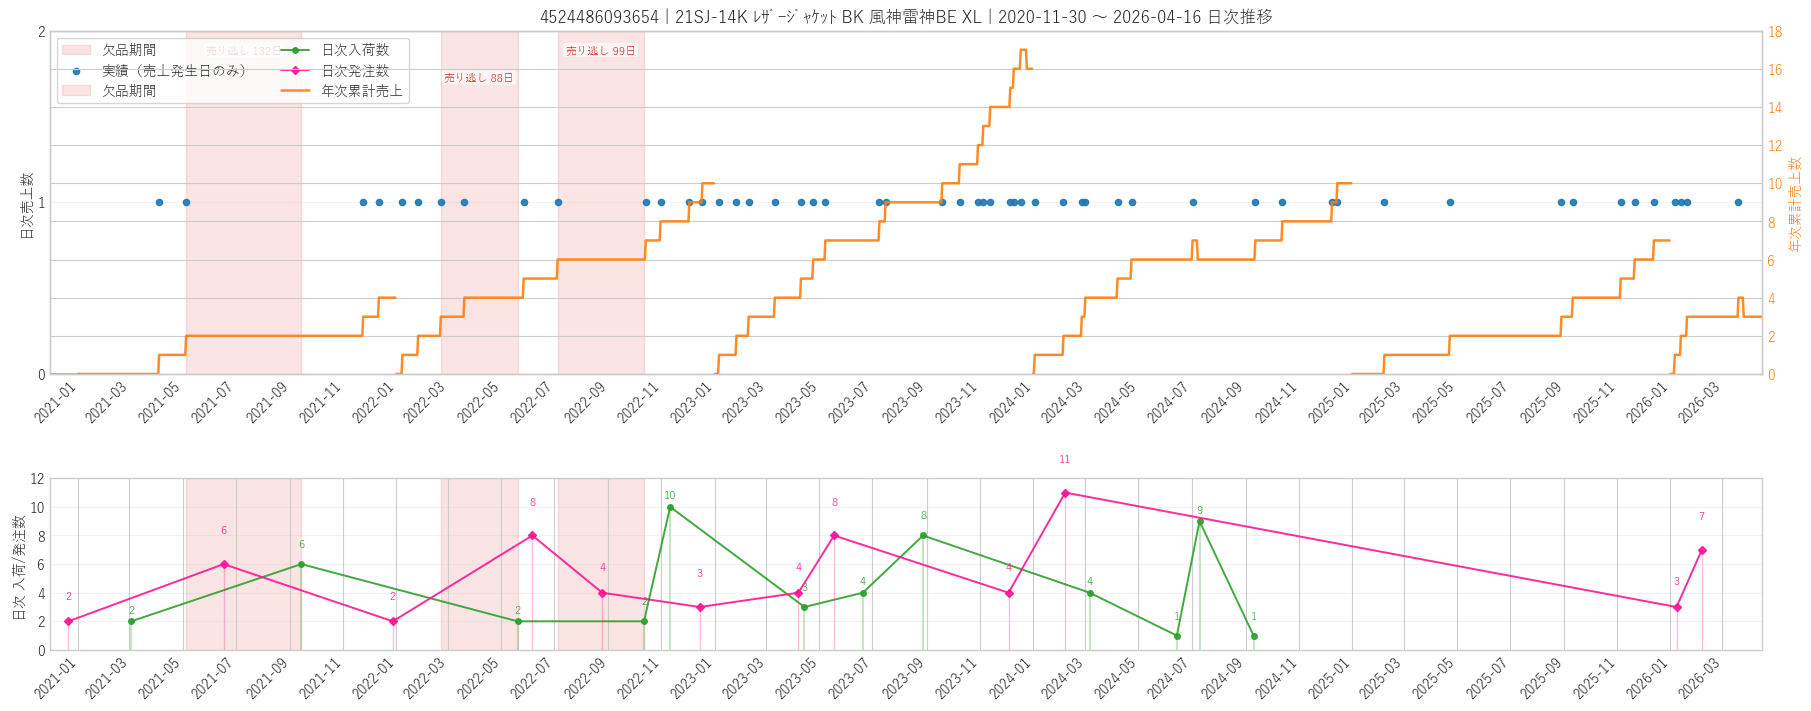

jan                                       4524486093654
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 風神雷神BE XL
sales_total_qty                                    50.0
sales_days                                           56
receipt_total_qty                                  52.0
receipt_days                                         12
order_total_qty                                    62.0
order_days                                           12
stockout_periods                                      3
stockout_total_days                               319.0
[21/53] 4524486109485


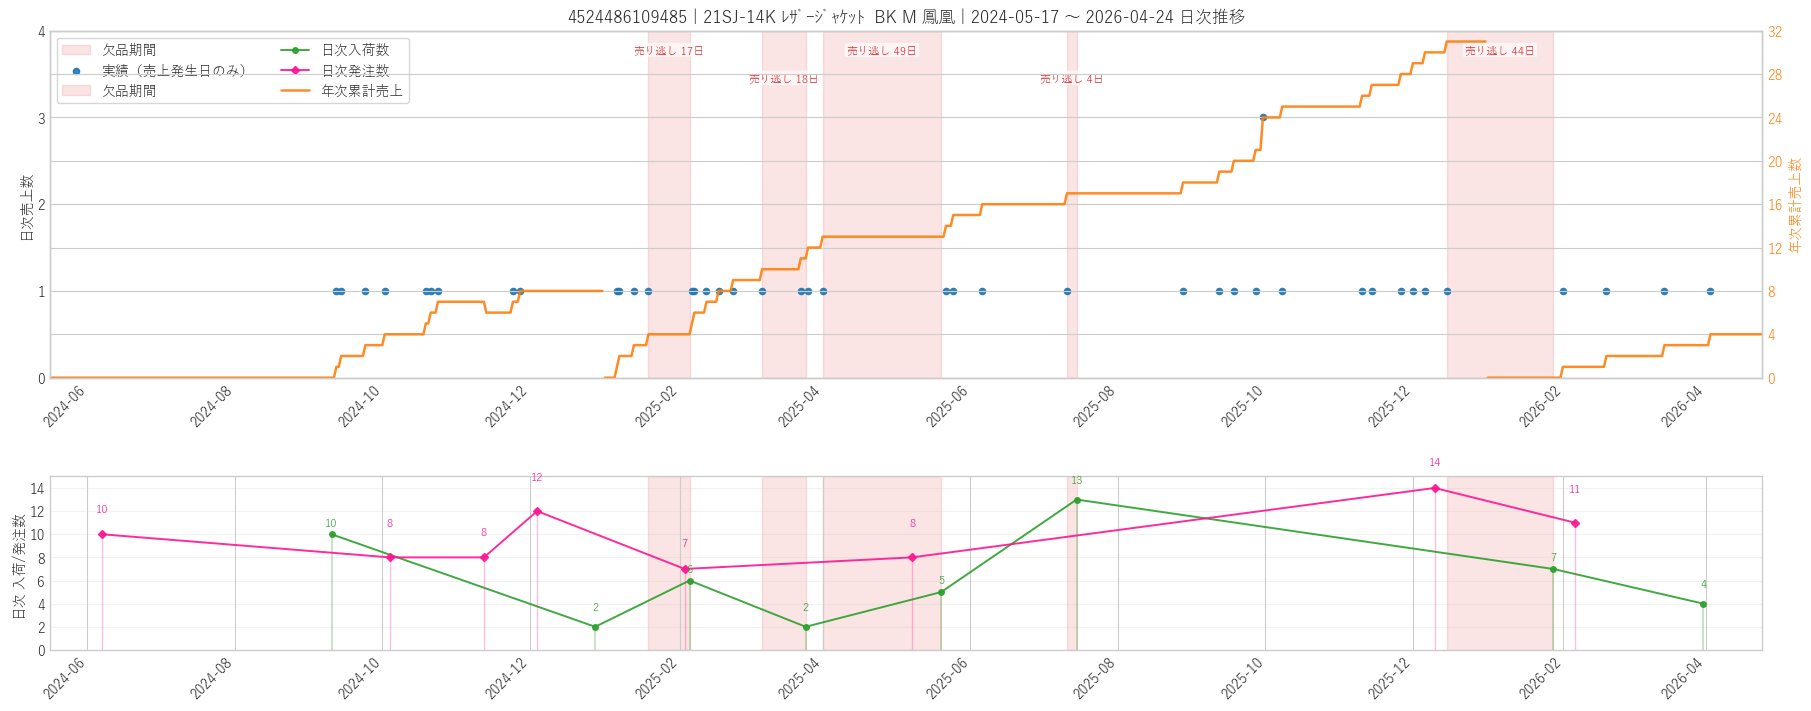

jan                                   4524486109485
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ  BK M 鳳凰
sales_total_qty                                43.0
sales_days                                       43
receipt_total_qty                              49.0
receipt_days                                      8
order_total_qty                                78.0
order_days                                        8
stockout_periods                                  5
stockout_total_days                           132.0
[22/53] 4524486106538


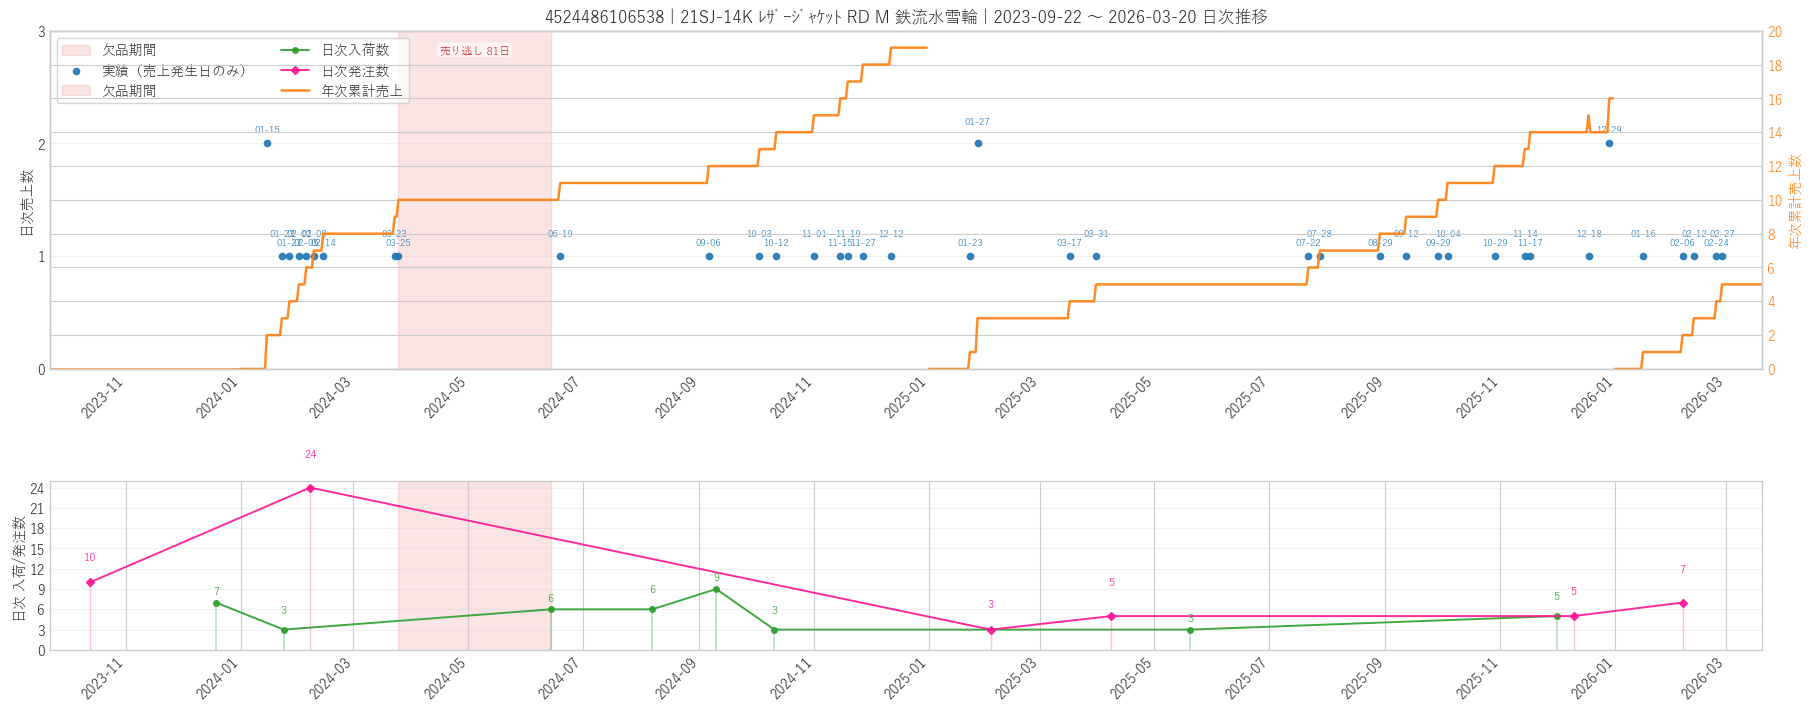

jan                                     4524486106538
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ RD M 鉄流水雪輪
sales_total_qty                                  40.0
sales_days                                         39
receipt_total_qty                                42.0
receipt_days                                        8
order_total_qty                                  54.0
order_days                                          6
stockout_periods                                    1
stockout_total_days                              81.0
[23/53] 4524486093630


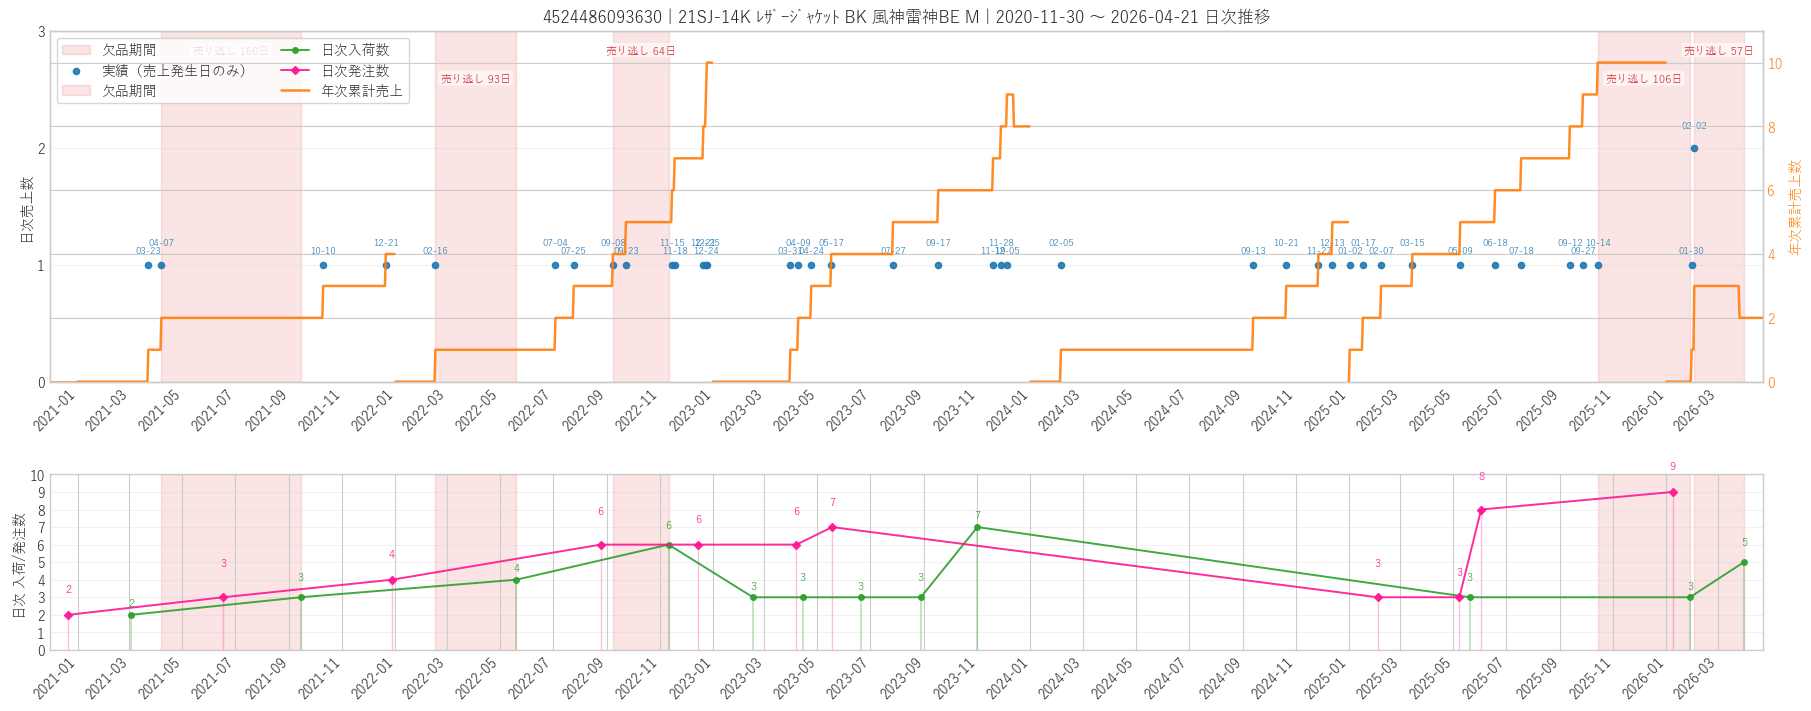

jan                                      4524486093630
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 風神雷神BE M
sales_total_qty                                   39.0
sales_days                                          42
receipt_total_qty                                 45.0
receipt_days                                        12
order_total_qty                                   57.0
order_days                                          11
stockout_periods                                     5
stockout_total_days                              480.0
[24/53] 4524486097966


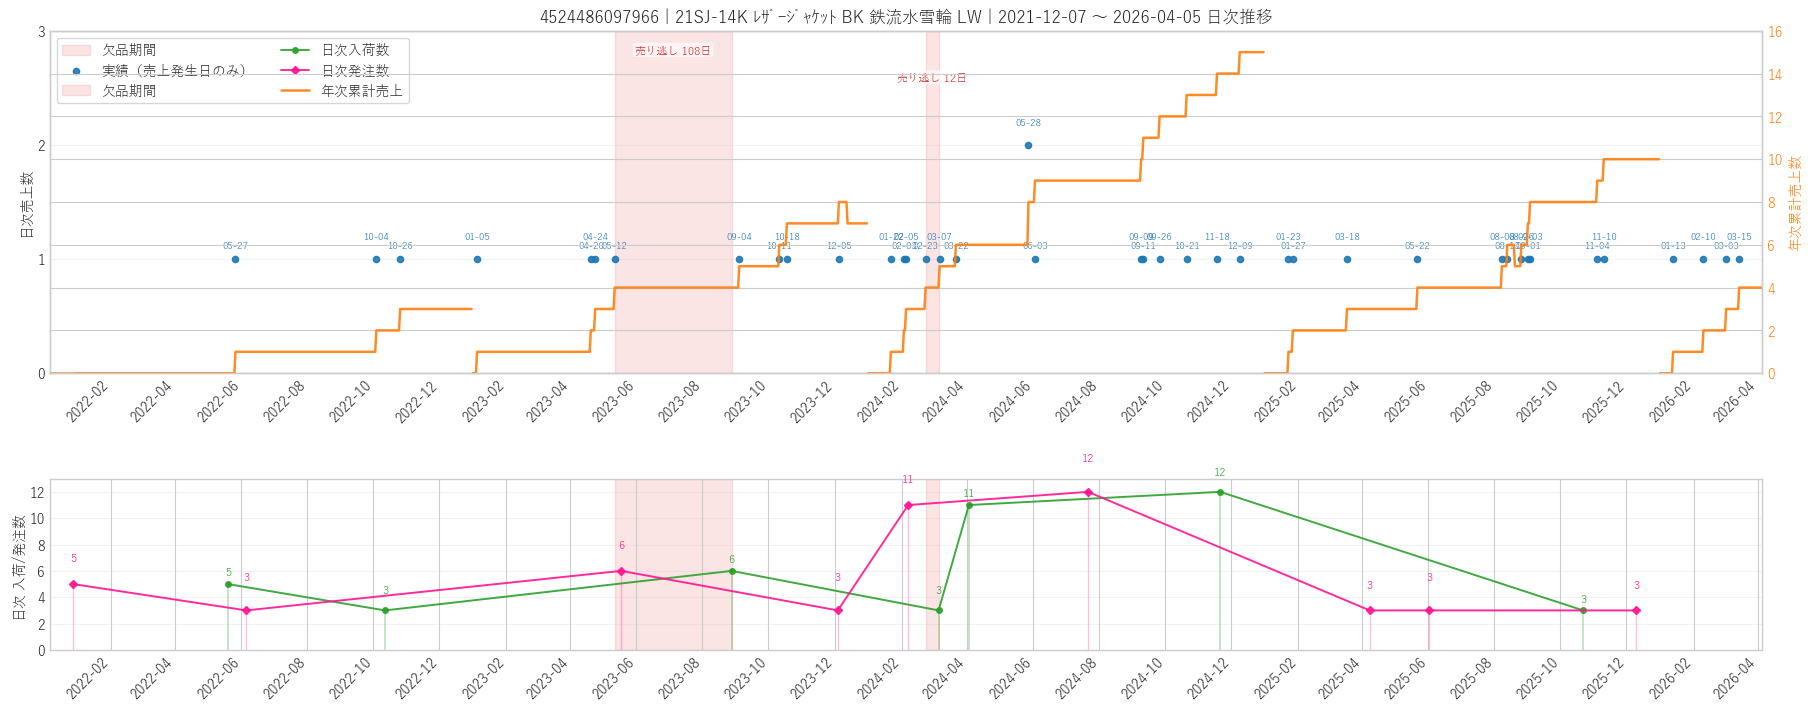

jan                                      4524486097966
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 鉄流水雪輪 LW
sales_total_qty                                   39.0
sales_days                                          42
receipt_total_qty                                 43.0
receipt_days                                         7
order_total_qty                                   49.0
order_days                                           9
stockout_periods                                     2
stockout_total_days                              120.0
[25/53] 4524486109515


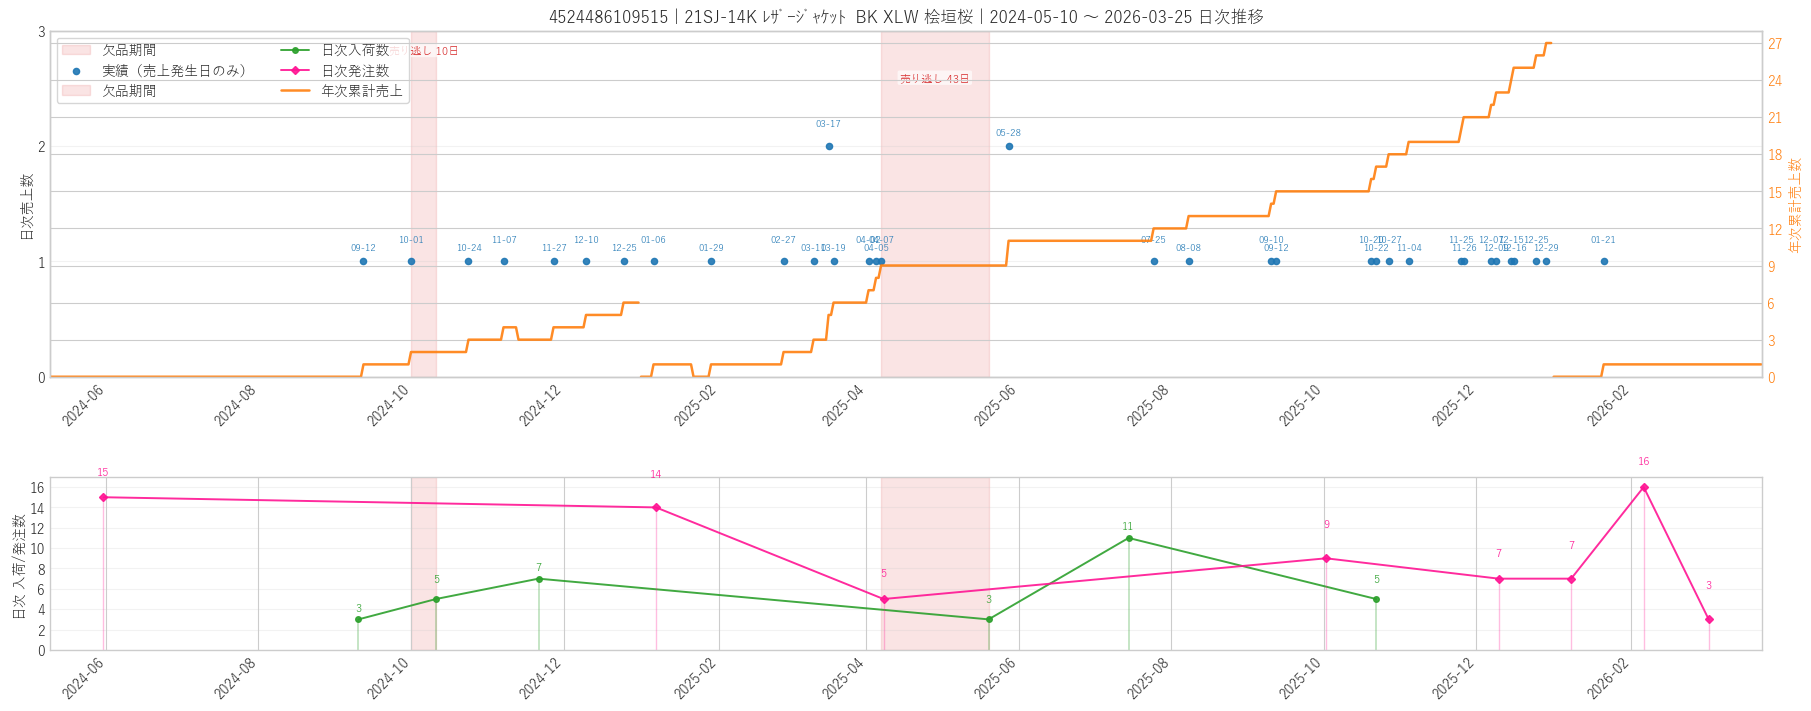

jan                                      4524486109515
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ  BK XLW 桧垣桜
sales_total_qty                                   34.0
sales_days                                          37
receipt_total_qty                                 34.0
receipt_days                                         6
order_total_qty                                   76.0
order_days                                           8
stockout_periods                                     2
stockout_total_days                               53.0
[26/53] 4524486109522


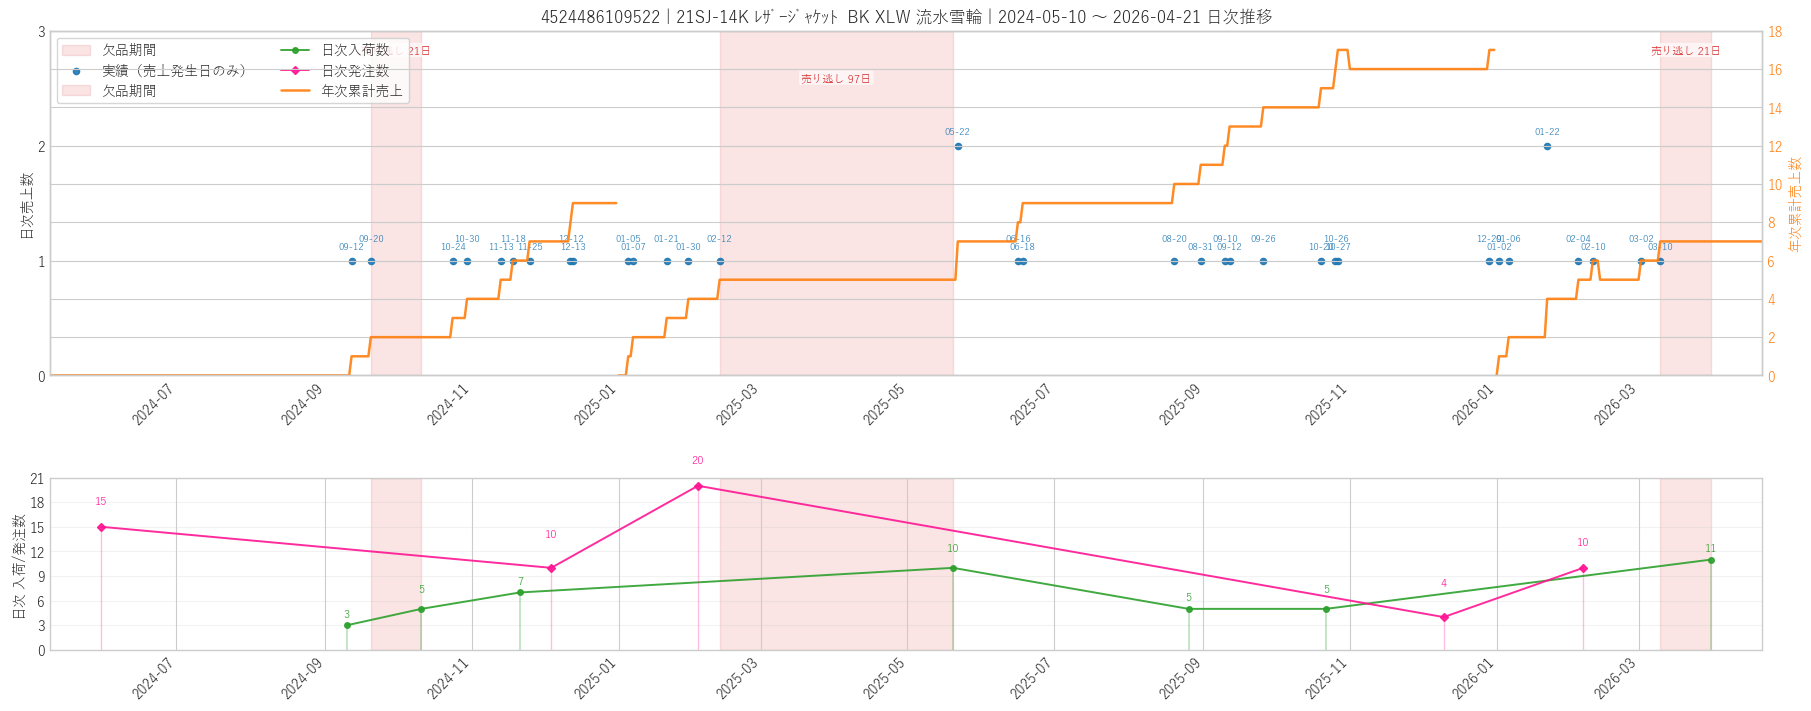

jan                                       4524486109522
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ  BK XLW 流水雪輪
sales_total_qty                                    33.0
sales_days                                           35
receipt_total_qty                                  46.0
receipt_days                                          7
order_total_qty                                    59.0
order_days                                            5
stockout_periods                                      3
stockout_total_days                               139.0
[27/53] 4524486111495


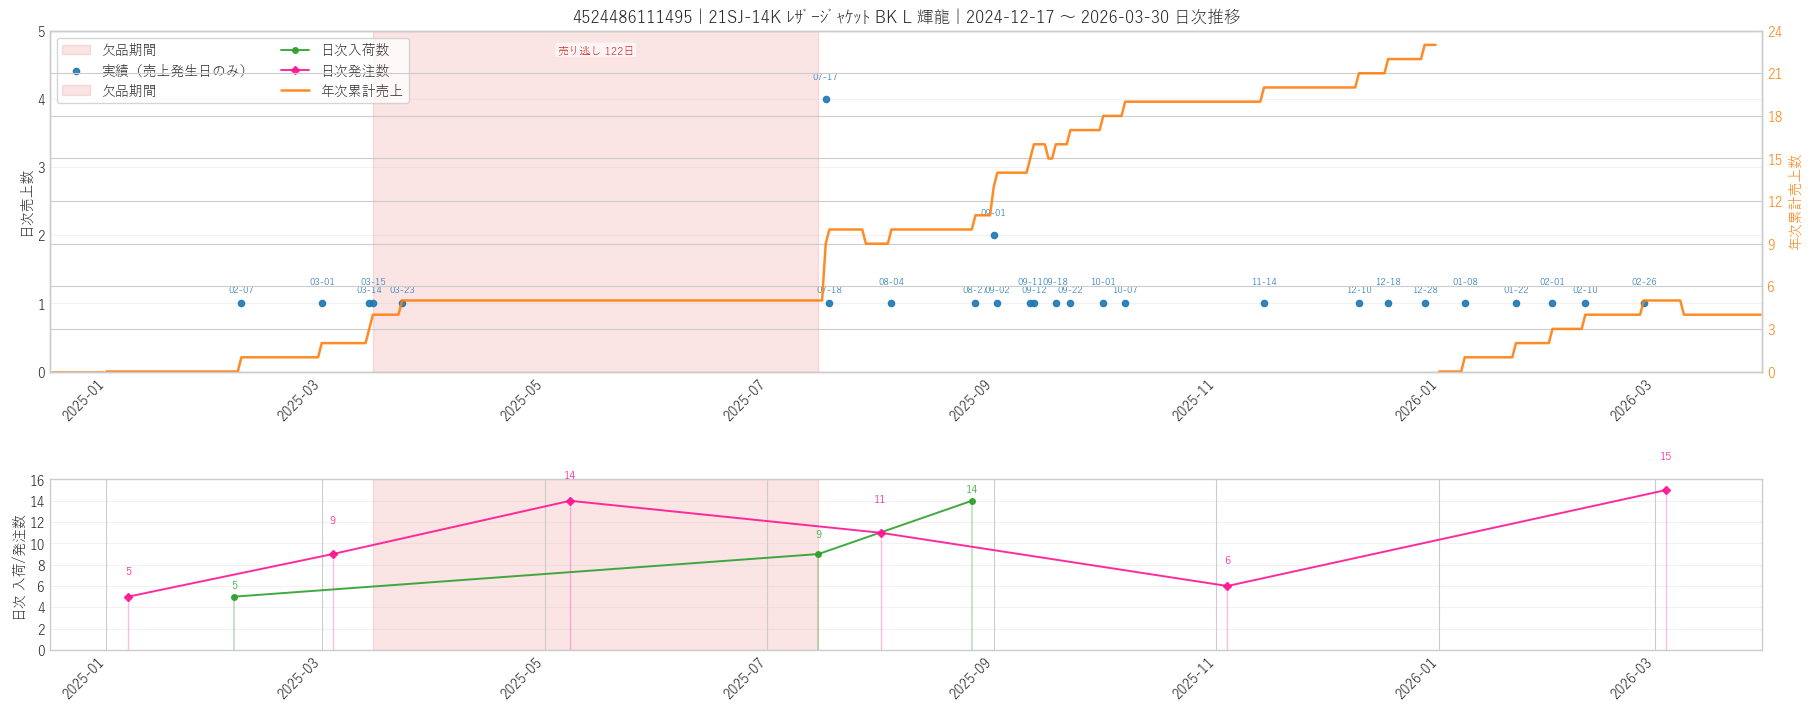

jan                                  4524486111495
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK L 輝龍
sales_total_qty                               27.0
sales_days                                      29
receipt_total_qty                             28.0
receipt_days                                     3
order_total_qty                               60.0
order_days                                       6
stockout_periods                                 1
stockout_total_days                          122.0
[28/53] 4524486107566


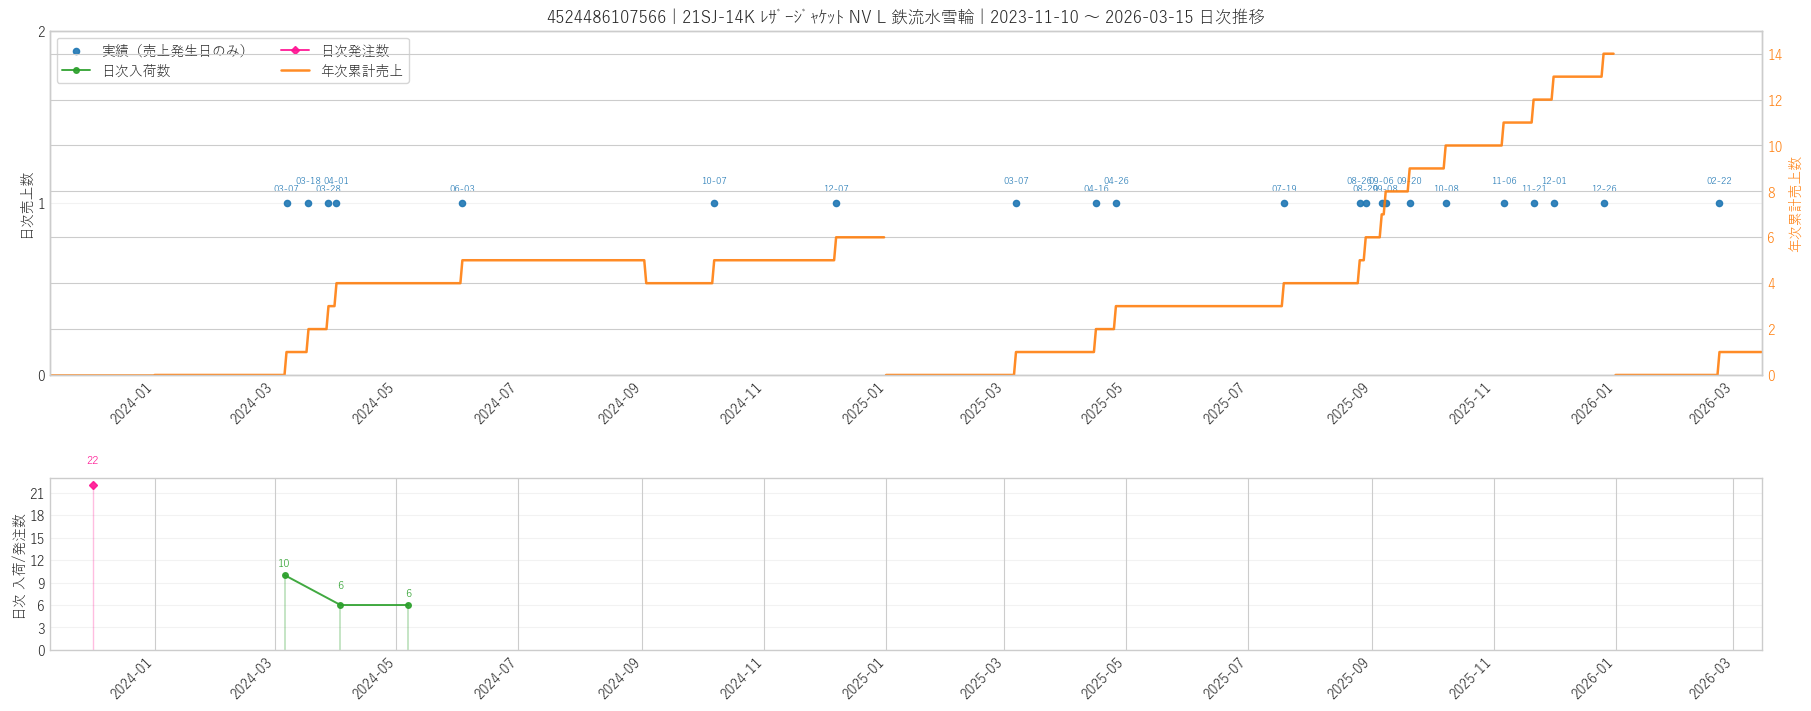

jan                                     4524486107566
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ NV L 鉄流水雪輪
sales_total_qty                                  21.0
sales_days                                         23
receipt_total_qty                                22.0
receipt_days                                        3
order_total_qty                                  22.0
order_days                                          1
stockout_periods                                    0
stockout_total_days                               0.0
[29/53] 4524486111501


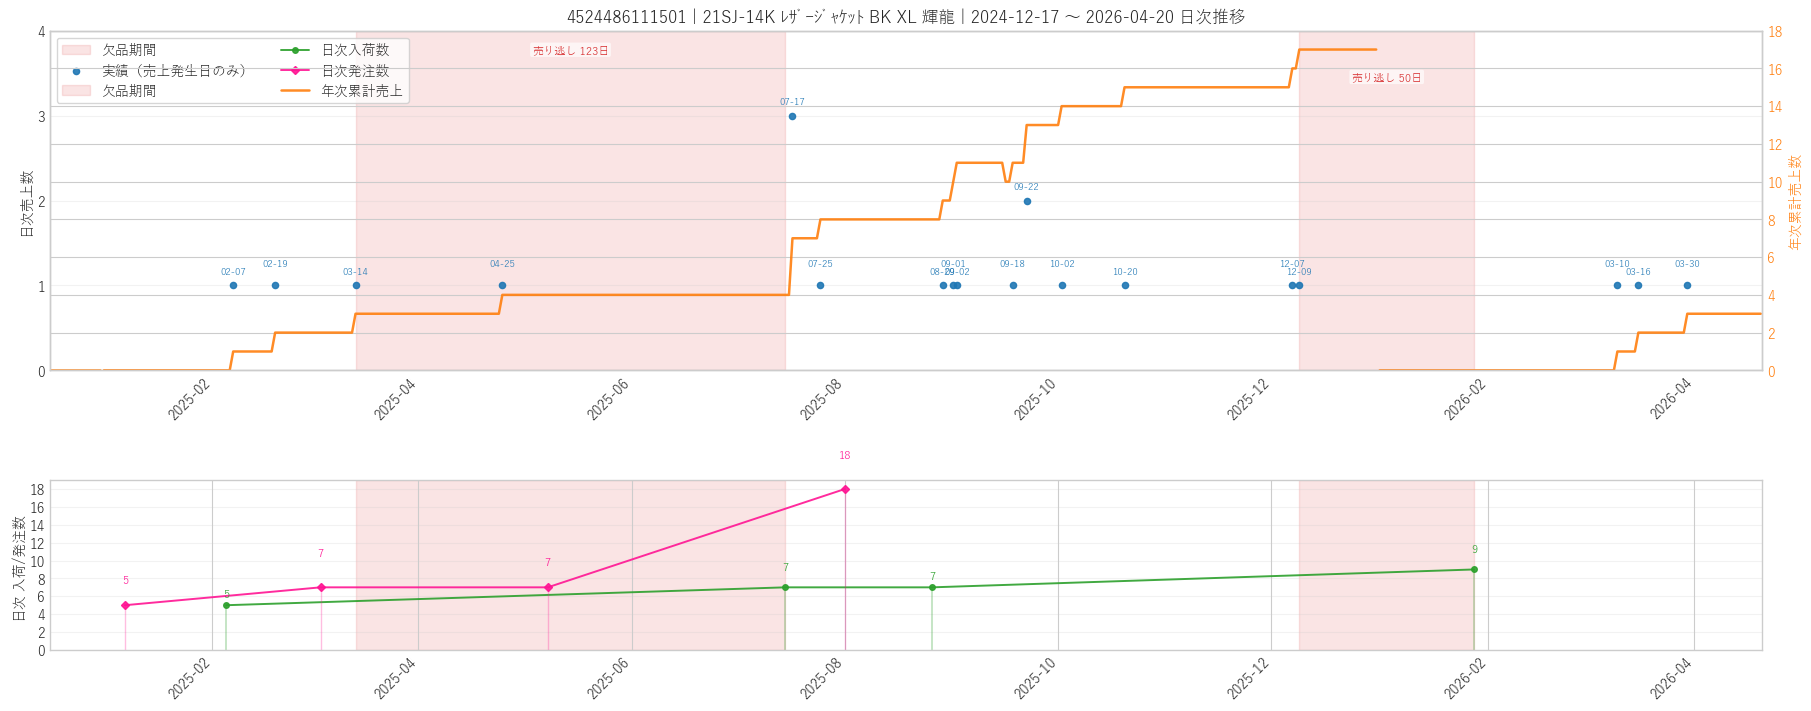

jan                                   4524486111501
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK XL 輝龍
sales_total_qty                                20.0
sales_days                                       19
receipt_total_qty                              28.0
receipt_days                                      4
order_total_qty                                37.0
order_days                                        4
stockout_periods                                  2
stockout_total_days                           173.0
[30/53] 4524486111488


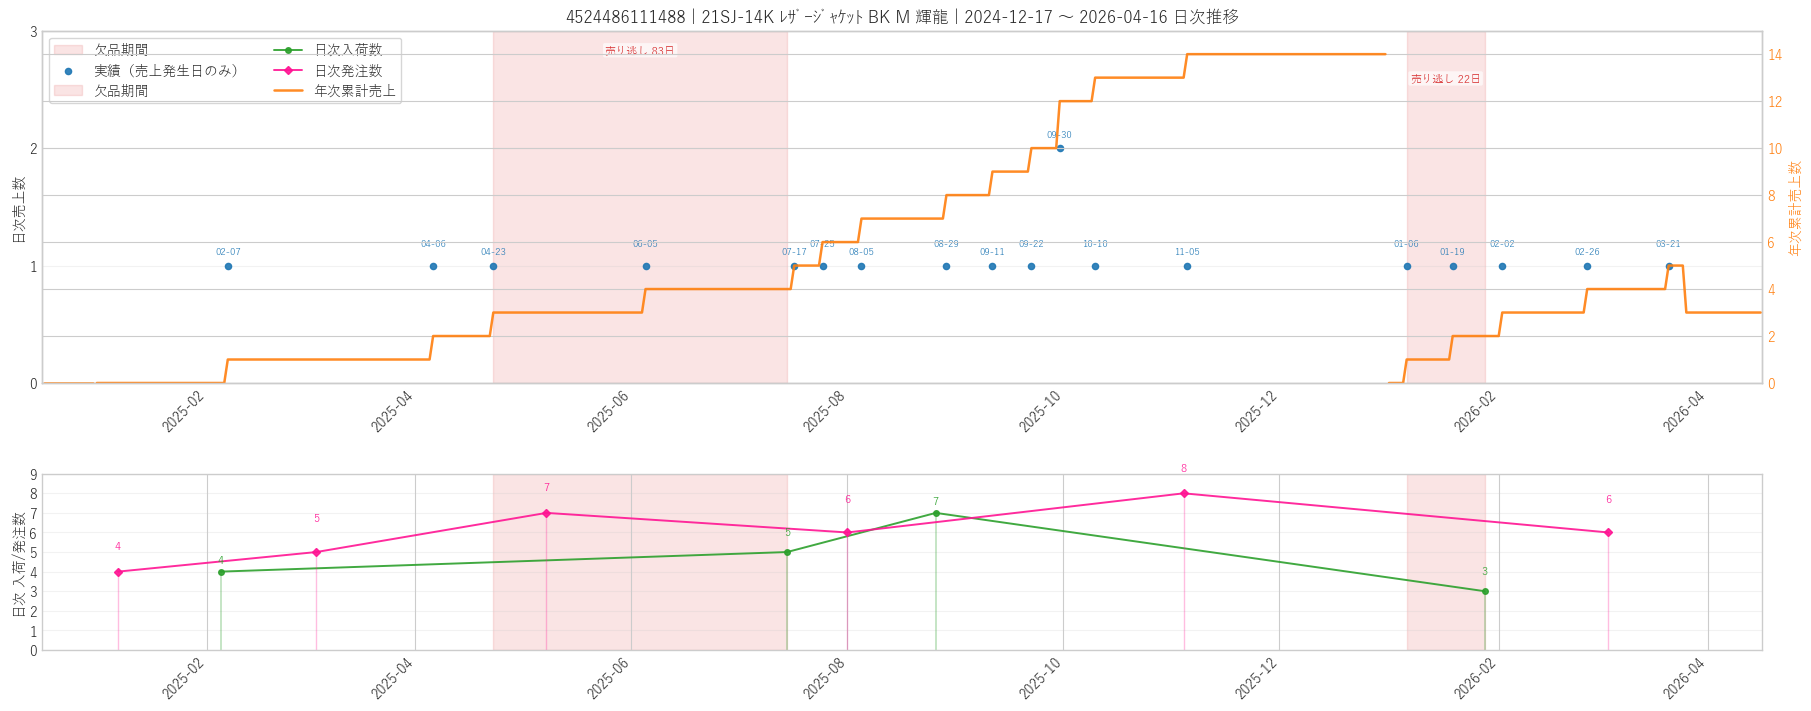

jan                                  4524486111488
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK M 輝龍
sales_total_qty                               17.0
sales_days                                      19
receipt_total_qty                             19.0
receipt_days                                     4
order_total_qty                               36.0
order_days                                       6
stockout_periods                                 2
stockout_total_days                          105.0
[31/53] 4524486107559


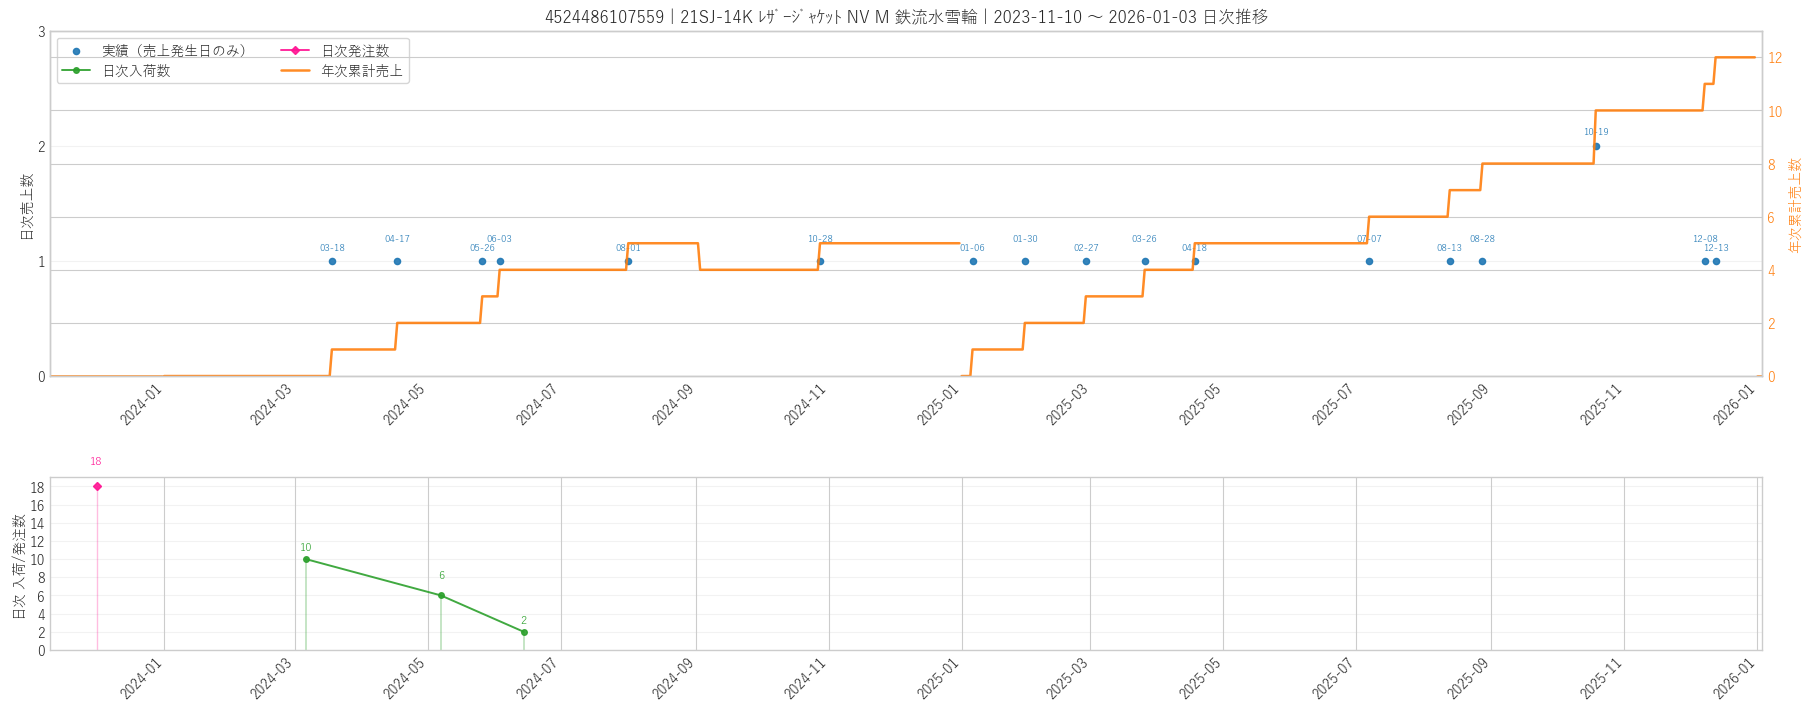

jan                                     4524486107559
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ NV M 鉄流水雪輪
sales_total_qty                                  17.0
sales_days                                         18
receipt_total_qty                                18.0
receipt_days                                        3
order_total_qty                                  18.0
order_days                                          1
stockout_periods                                    0
stockout_total_days                               0.0
[32/53] 4524486107573


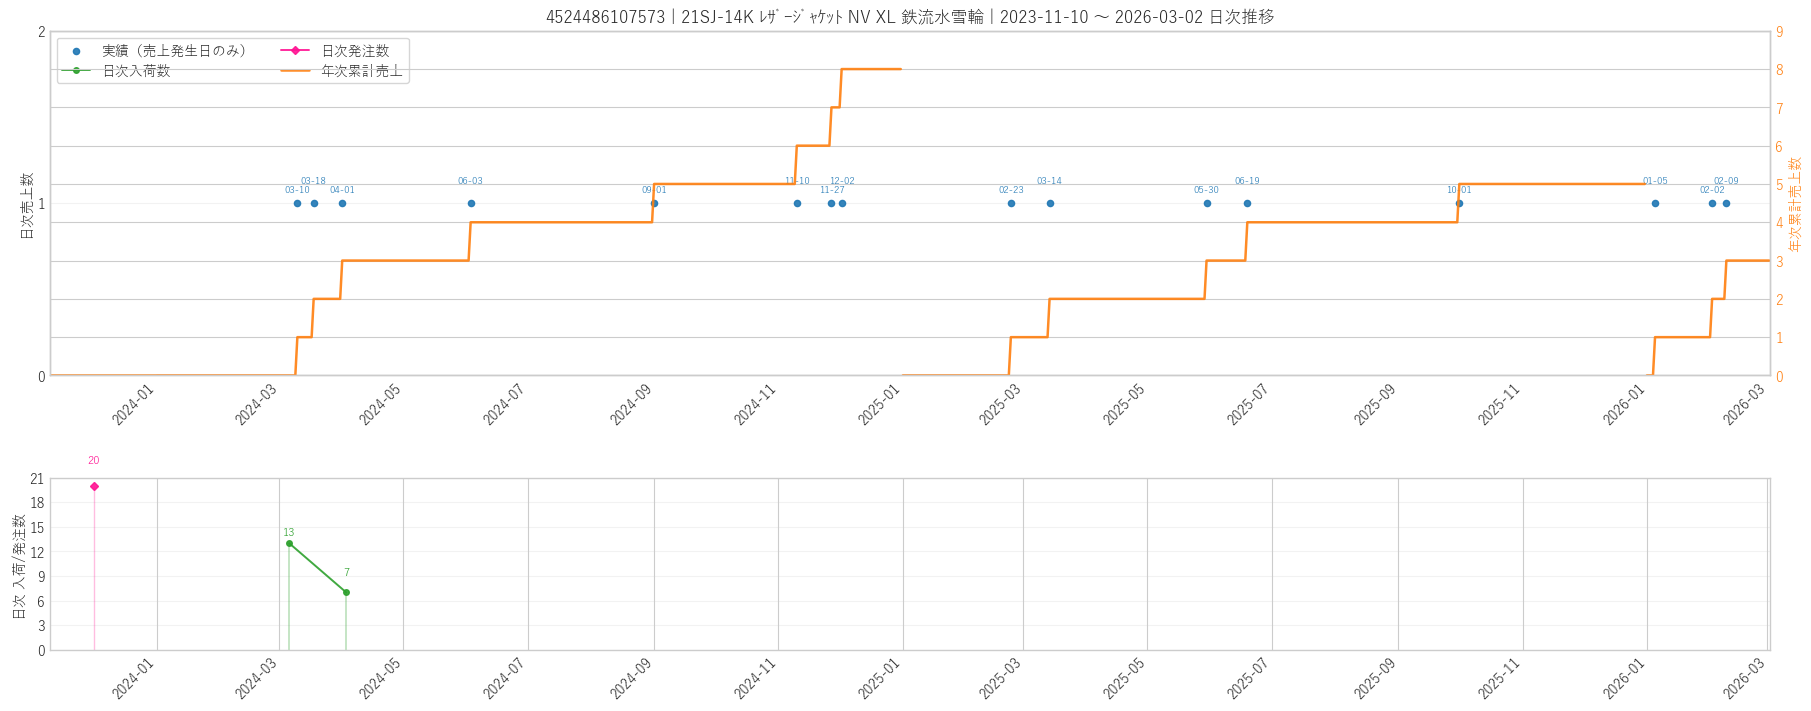

jan                                      4524486107573
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ NV XL 鉄流水雪輪
sales_total_qty                                   16.0
sales_days                                          16
receipt_total_qty                                 20.0
receipt_days                                         2
order_total_qty                                   20.0
order_days                                           1
stockout_periods                                     0
stockout_total_days                                0.0
[33/53] 4524486114328


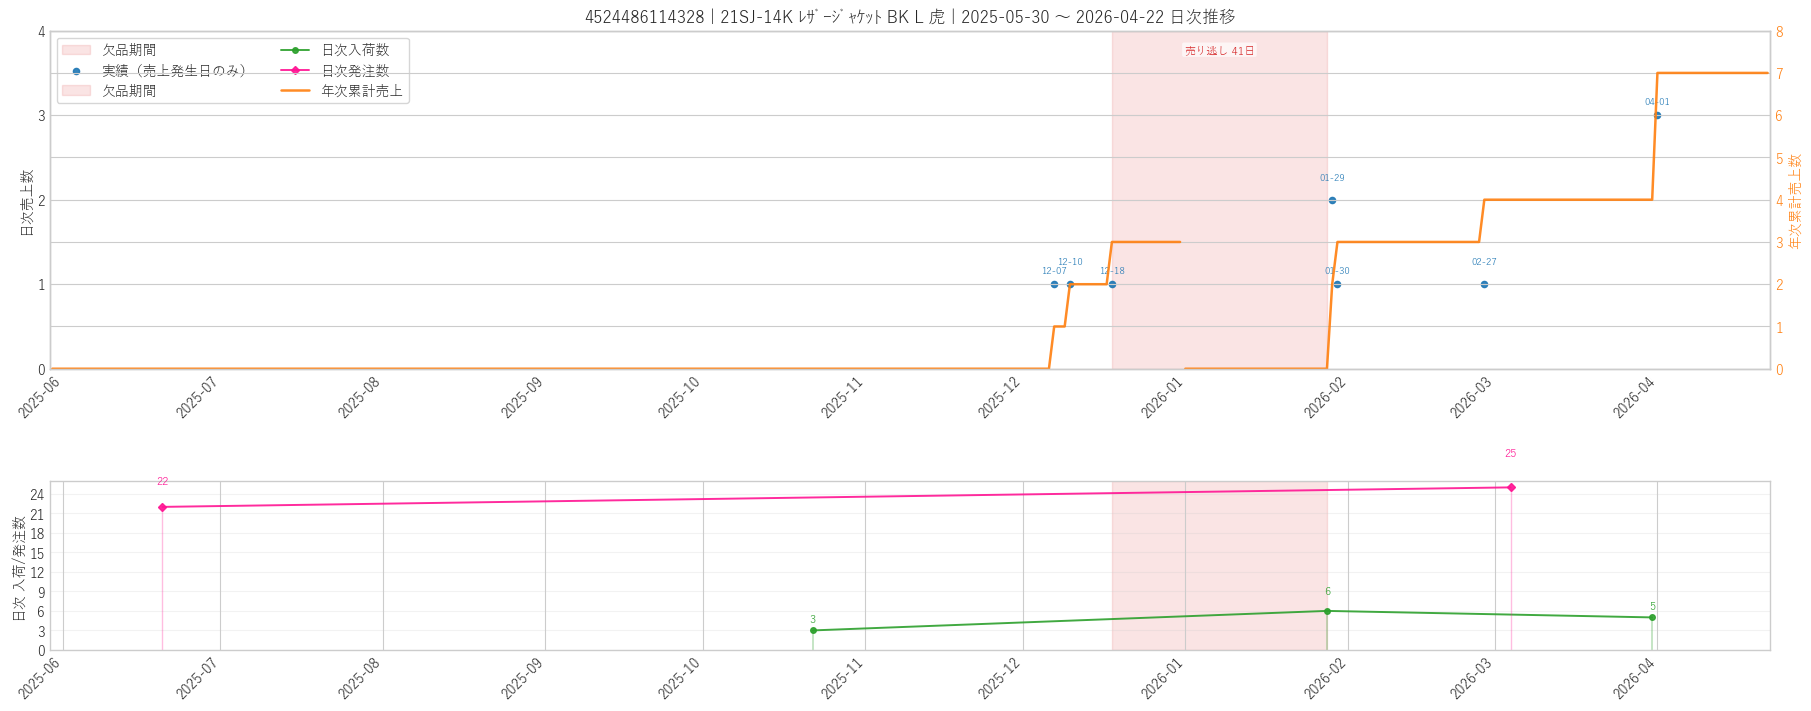

jan                                 4524486114328
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK L 虎
sales_total_qty                              10.0
sales_days                                      7
receipt_total_qty                            14.0
receipt_days                                    3
order_total_qty                              47.0
order_days                                      2
stockout_periods                                1
stockout_total_days                          41.0
[34/53] 4524486113499


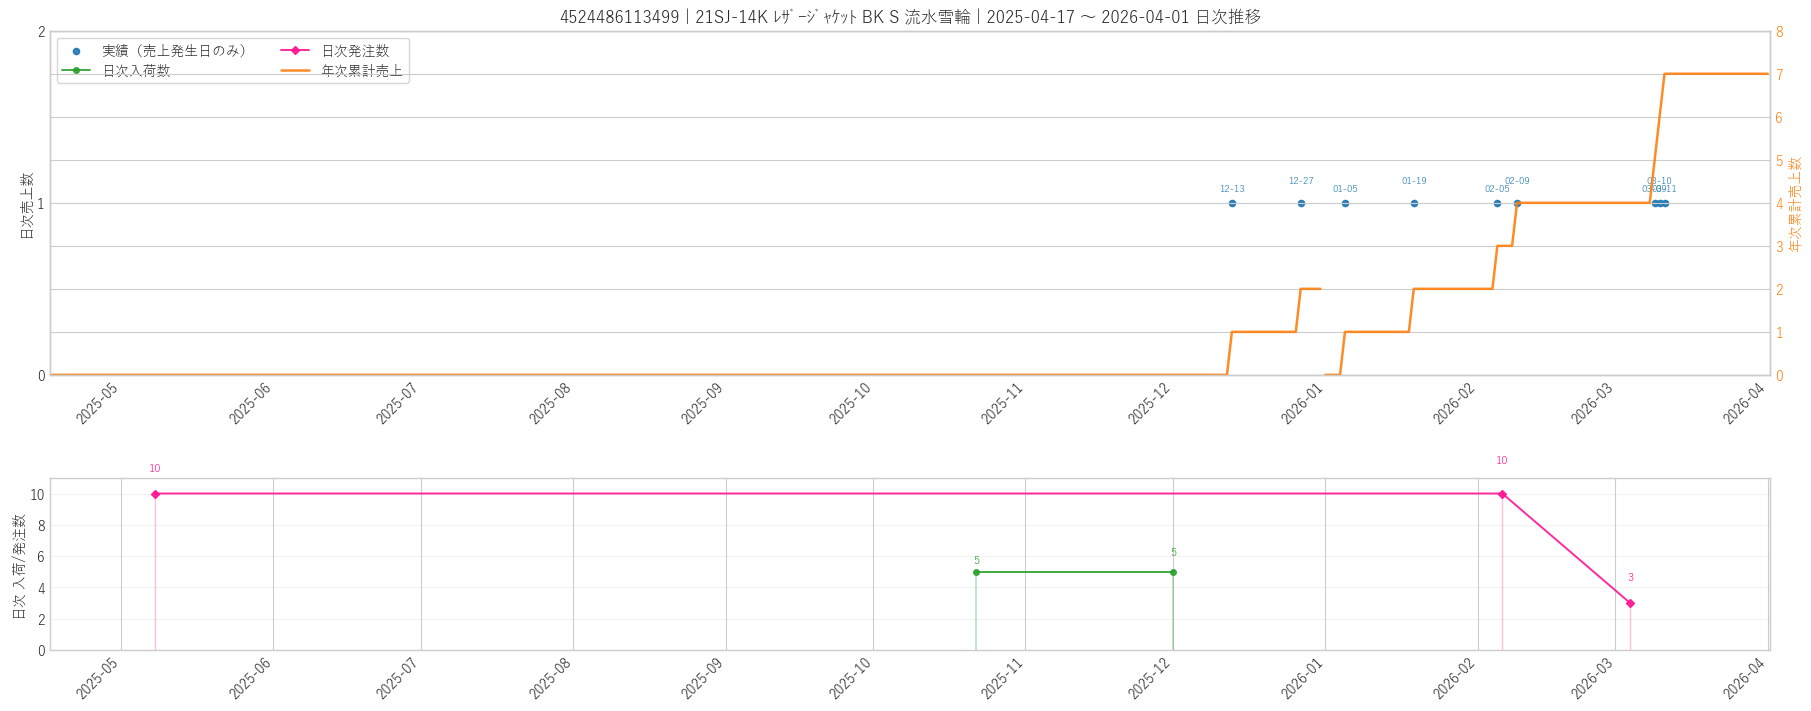

jan                                    4524486113499
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK S 流水雪輪
sales_total_qty                                  9.0
sales_days                                         9
receipt_total_qty                               10.0
receipt_days                                       2
order_total_qty                                 23.0
order_days                                         3
stockout_periods                                   0
stockout_total_days                              0.0
[35/53] 4524486103308


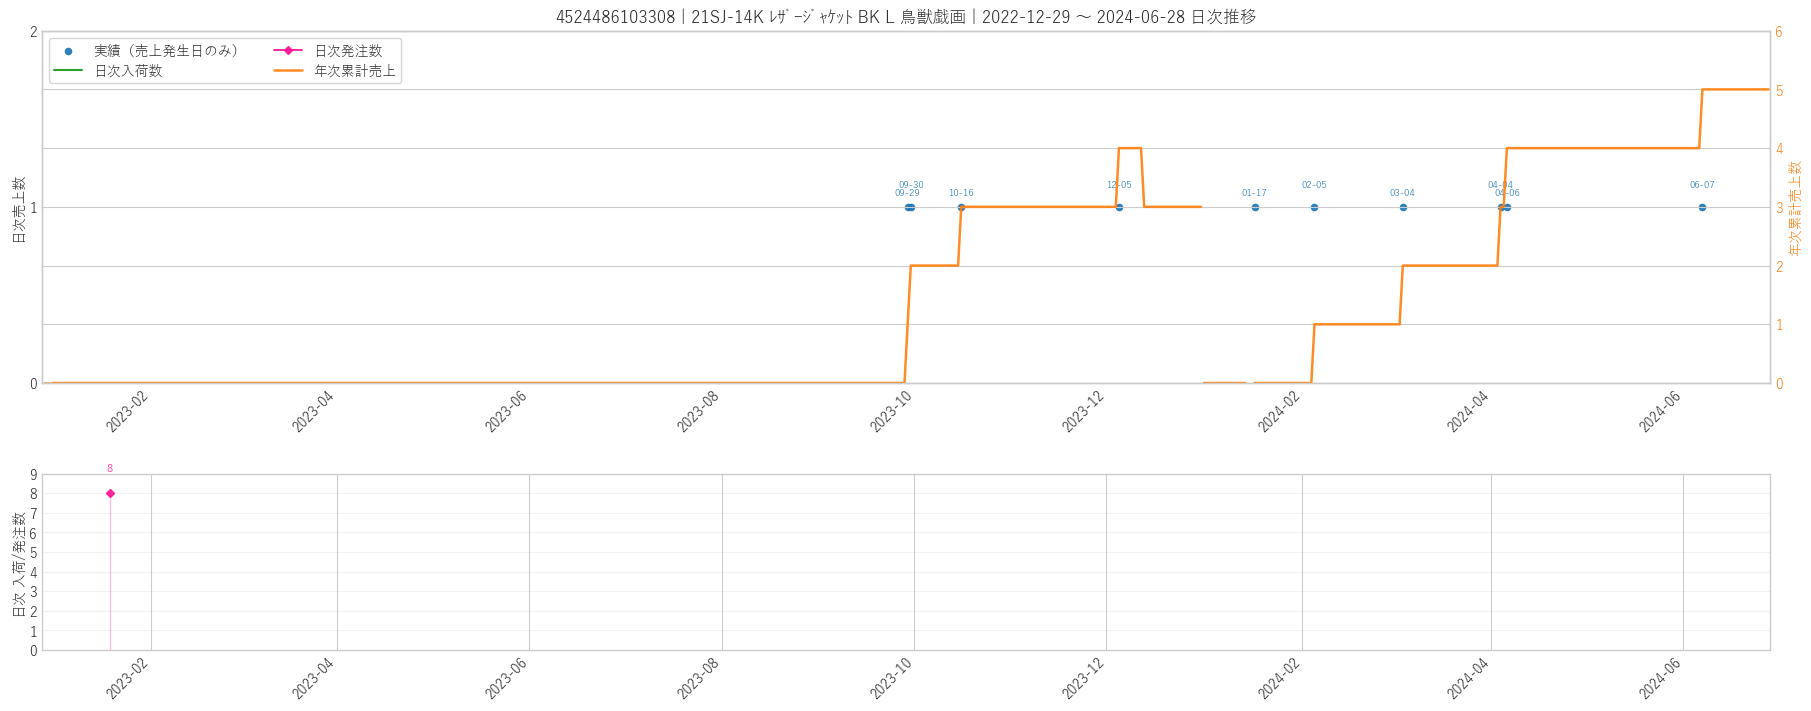

jan                                    4524486103308
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK L 鳥獣戯画
sales_total_qty                                  8.0
sales_days                                        12
receipt_total_qty                                0.0
receipt_days                                       0
order_total_qty                                  8.0
order_days                                         1
stockout_periods                                   0
stockout_total_days                              0.0
[36/53] 4524486107740


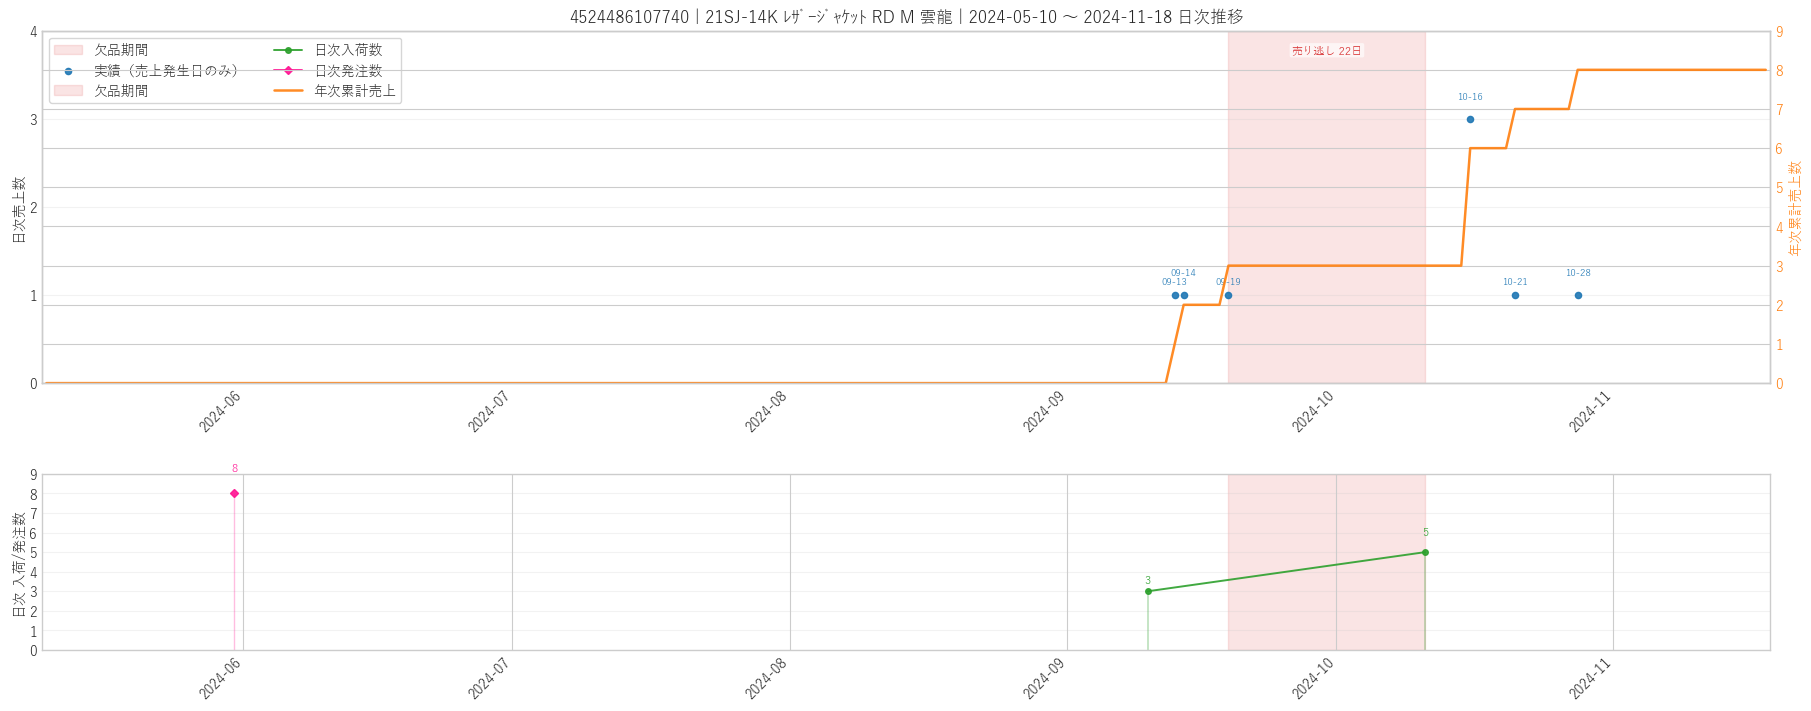

jan                                  4524486107740
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ RD M 雲龍
sales_total_qty                                8.0
sales_days                                       6
receipt_total_qty                              8.0
receipt_days                                     2
order_total_qty                                8.0
order_days                                       1
stockout_periods                                 1
stockout_total_days                           22.0
[37/53] 4524486107757


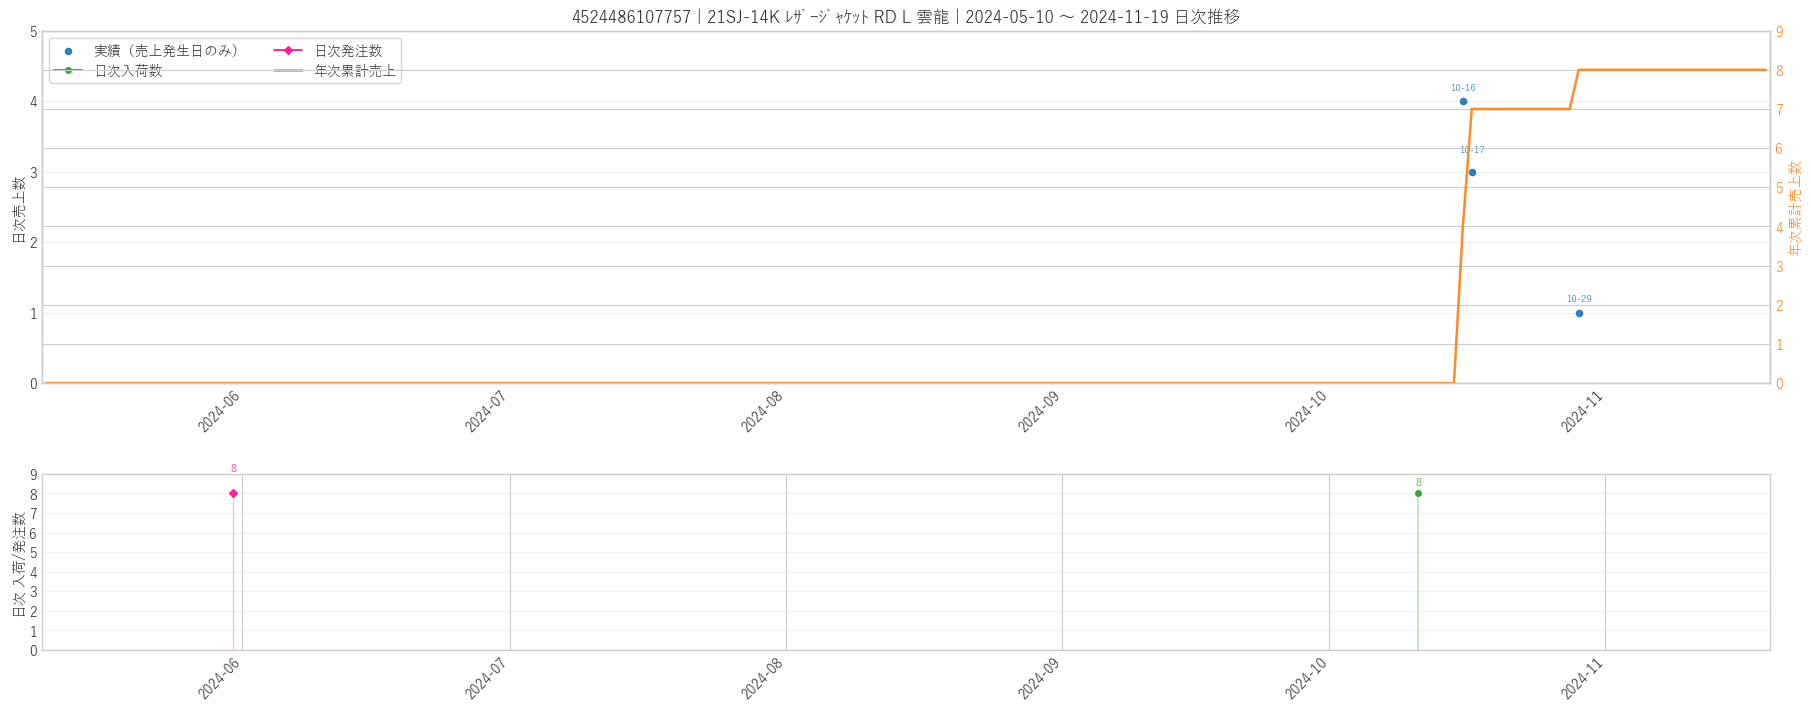

jan                                  4524486107757
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ RD L 雲龍
sales_total_qty                                8.0
sales_days                                       3
receipt_total_qty                              8.0
receipt_days                                     1
order_total_qty                                8.0
order_days                                       1
stockout_periods                                 0
stockout_total_days                            0.0
[38/53] 4524486103315


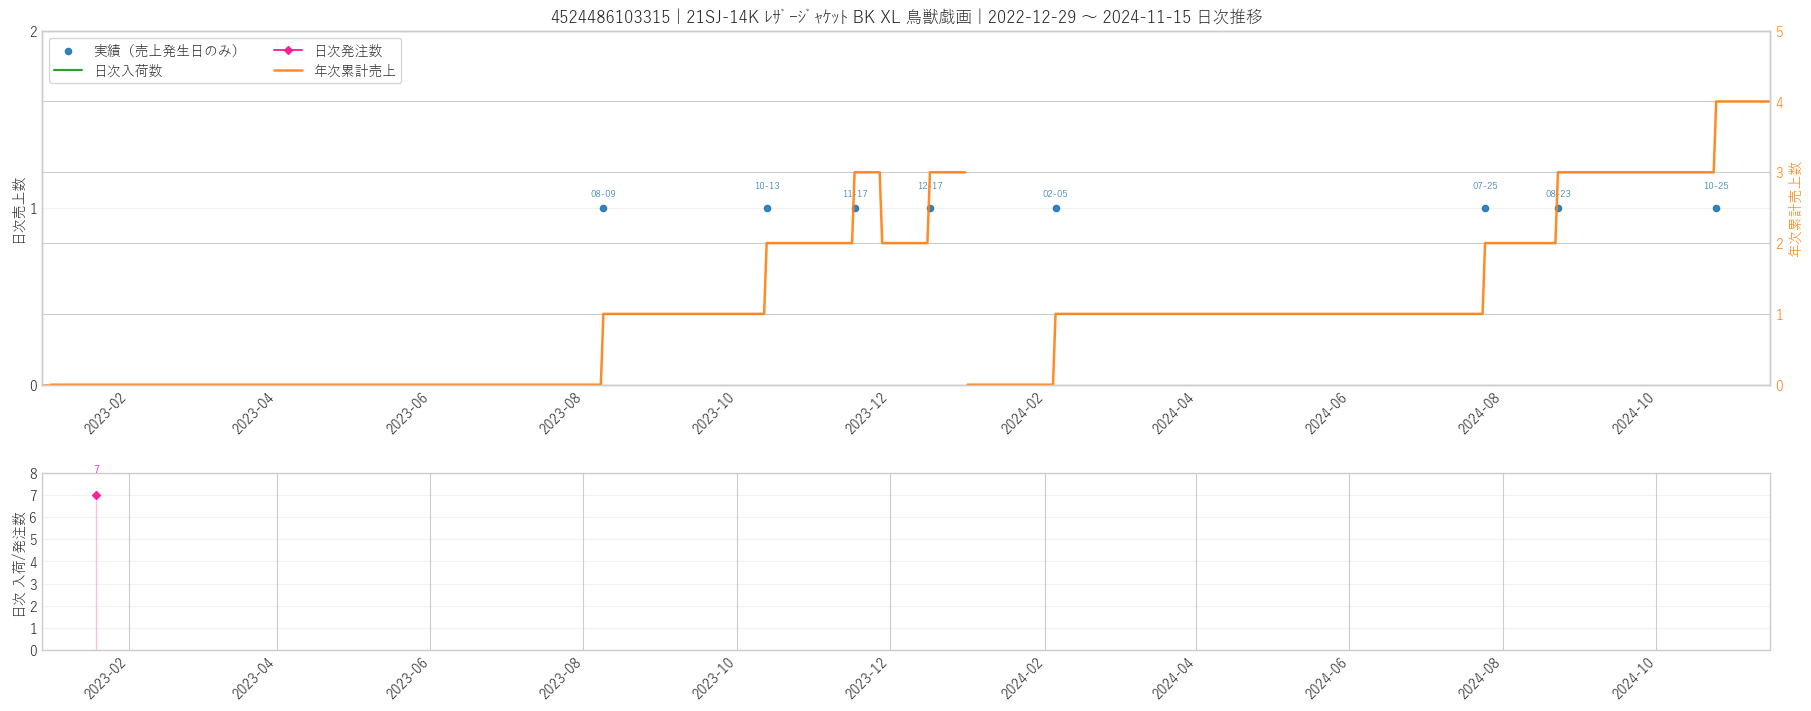

jan                                     4524486103315
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK XL 鳥獣戯画
sales_total_qty                                   7.0
sales_days                                          9
receipt_total_qty                                 0.0
receipt_days                                        0
order_total_qty                                   7.0
order_days                                          1
stockout_periods                                    0
stockout_total_days                               0.0
[39/53] 4524486113505


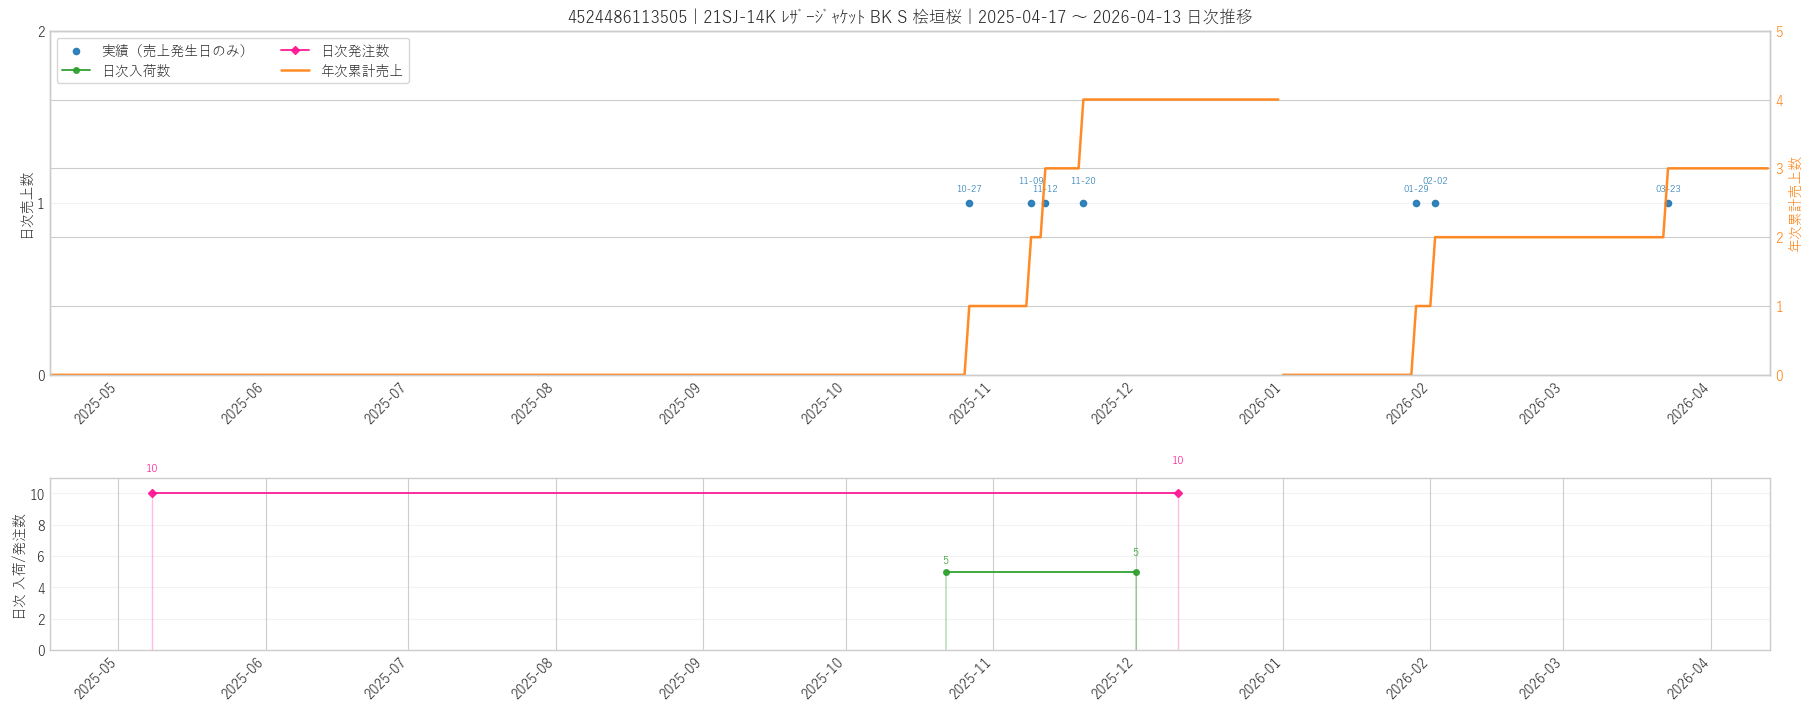

jan                                   4524486113505
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK S 桧垣桜
sales_total_qty                                 7.0
sales_days                                        7
receipt_total_qty                              10.0
receipt_days                                      2
order_total_qty                                20.0
order_days                                        2
stockout_periods                                  0
stockout_total_days                             0.0
[40/53] 4524486107764


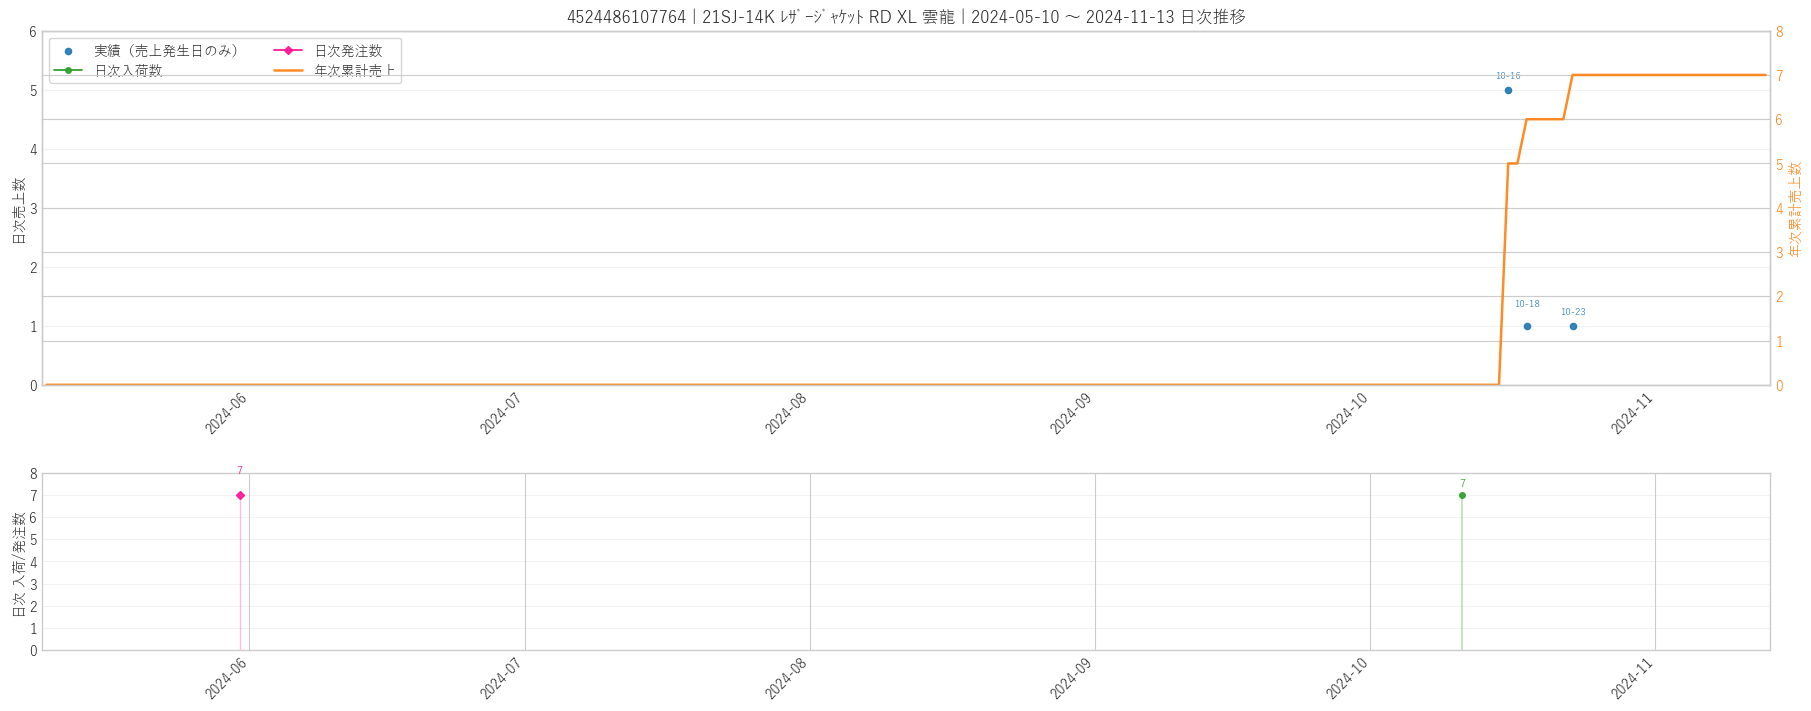

jan                                   4524486107764
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ RD XL 雲龍
sales_total_qty                                 7.0
sales_days                                        3
receipt_total_qty                               7.0
receipt_days                                      1
order_total_qty                                 7.0
order_days                                        1
stockout_periods                                  0
stockout_total_days                             0.0
[41/53] 4524486103292


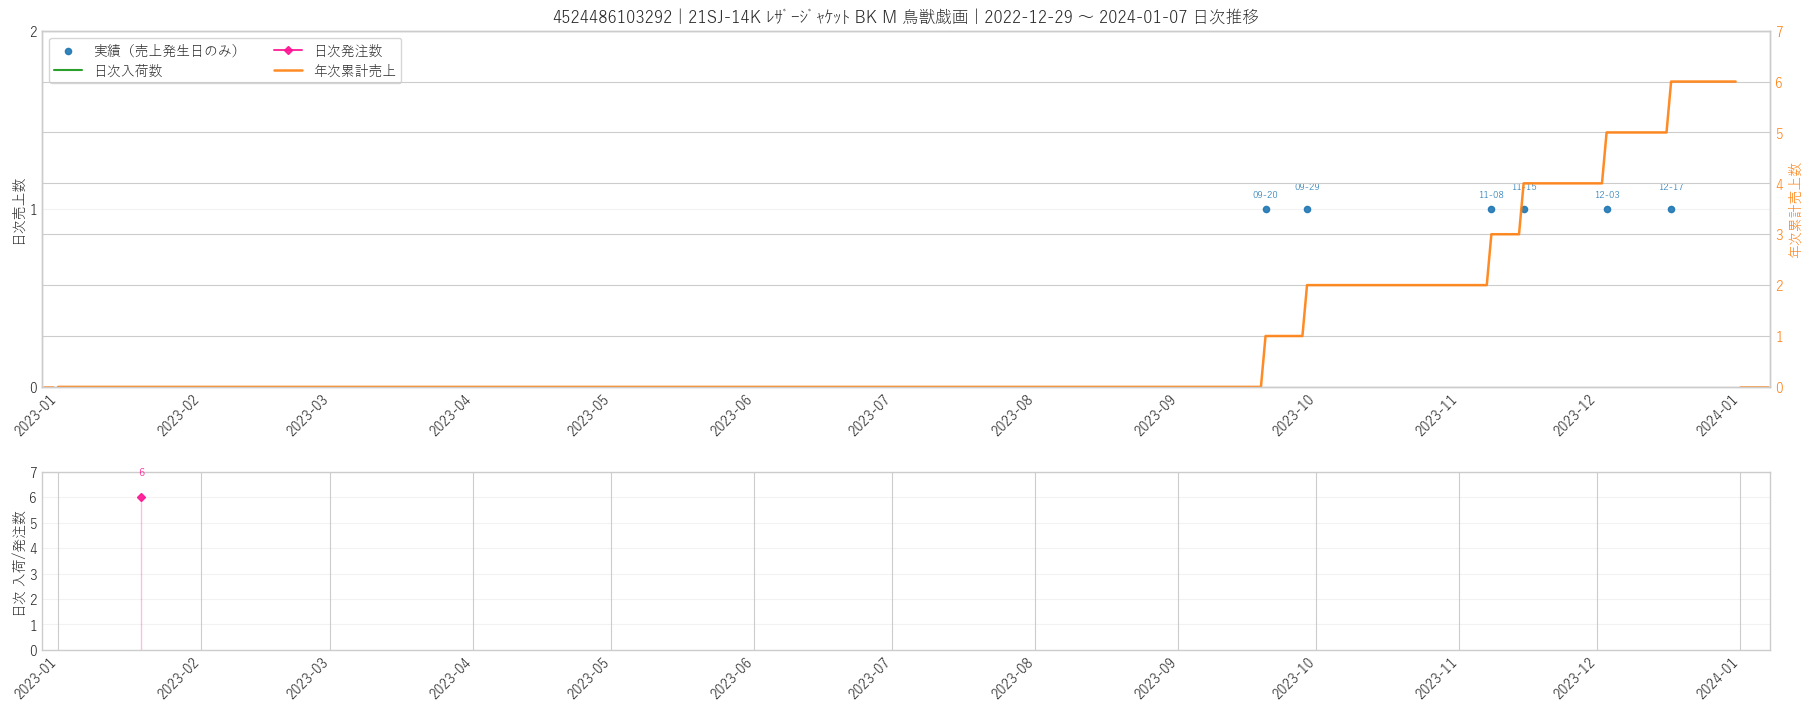

jan                                    4524486103292
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK M 鳥獣戯画
sales_total_qty                                  6.0
sales_days                                         6
receipt_total_qty                                0.0
receipt_days                                       0
order_total_qty                                  6.0
order_days                                         1
stockout_periods                                   0
stockout_total_days                              0.0
[42/53] 4524486114311


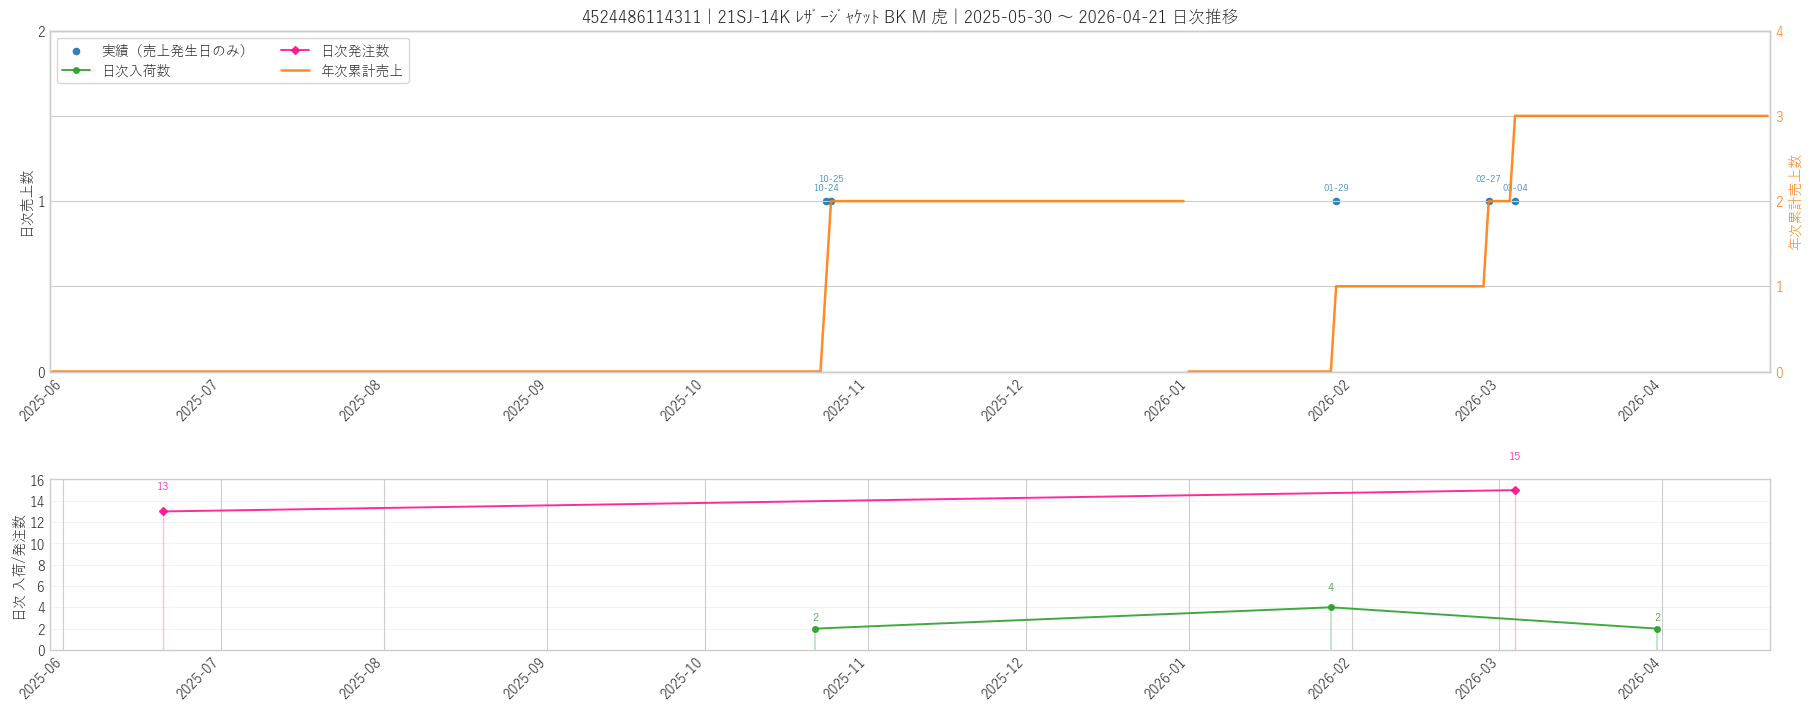

jan                                 4524486114311
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK M 虎
sales_total_qty                               5.0
sales_days                                      5
receipt_total_qty                             8.0
receipt_days                                    3
order_total_qty                              28.0
order_days                                      2
stockout_periods                                0
stockout_total_days                           0.0
[43/53] 4524486114335


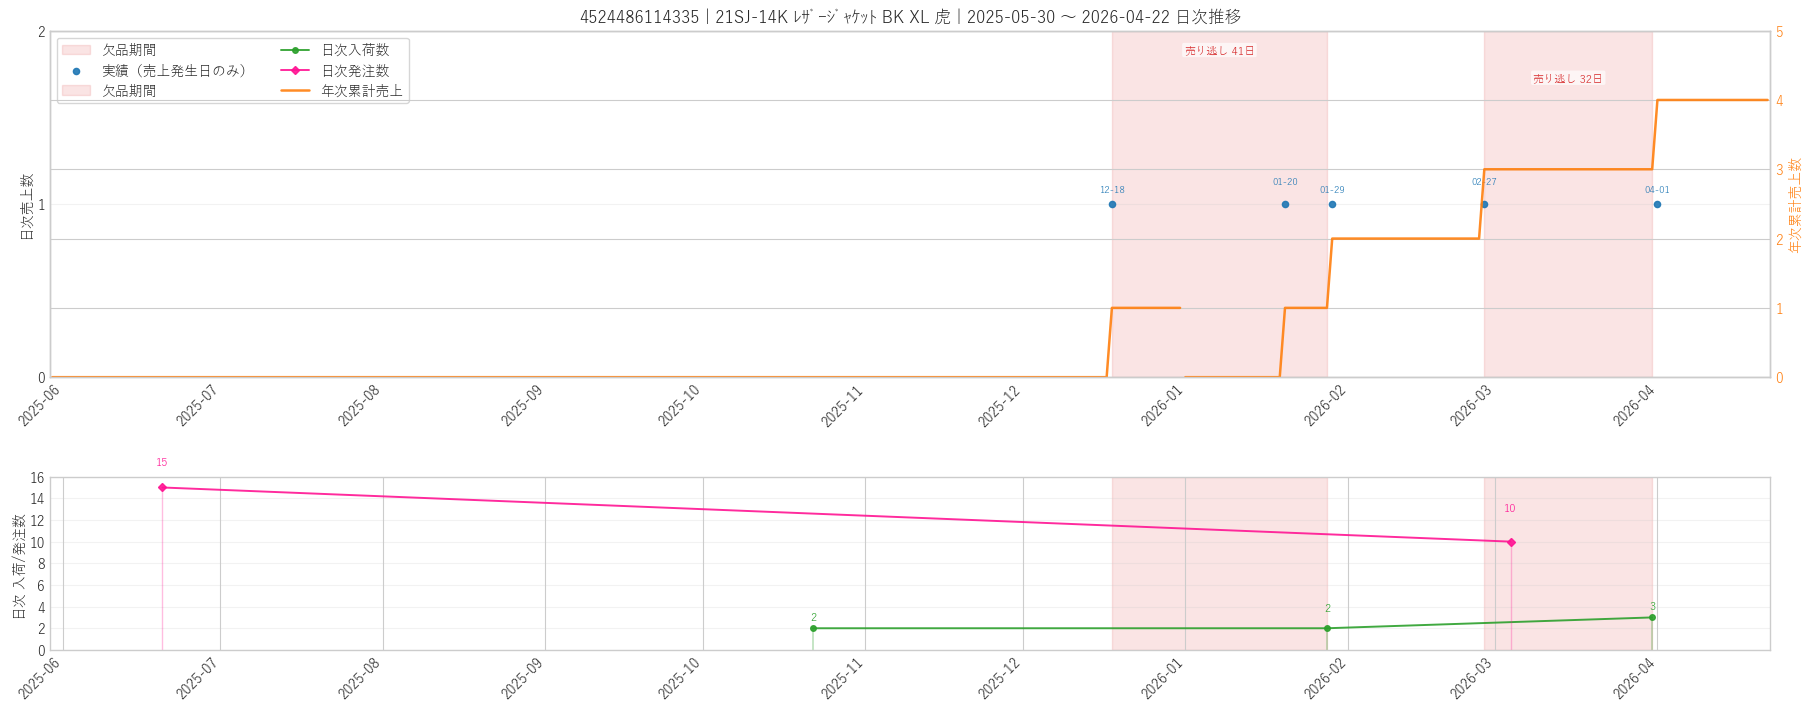

jan                                  4524486114335
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK XL 虎
sales_total_qty                                5.0
sales_days                                       5
receipt_total_qty                              7.0
receipt_days                                     3
order_total_qty                               25.0
order_days                                       2
stockout_periods                                 2
stockout_total_days                           73.0
[44/53] 4524486094934


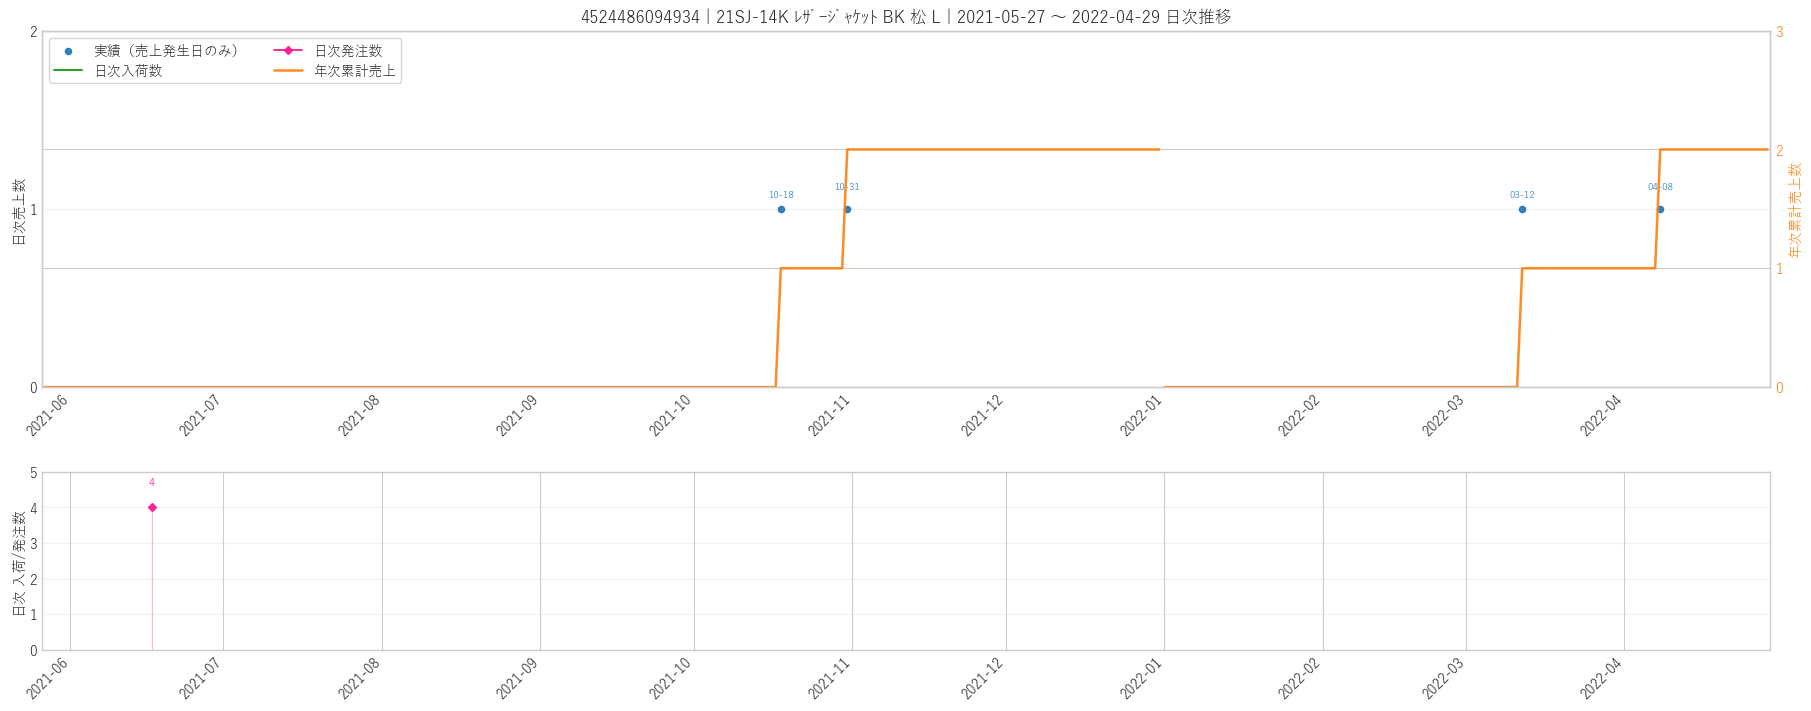

jan                                 4524486094934
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 松 L
sales_total_qty                               4.0
sales_days                                      4
receipt_total_qty                             0.0
receipt_days                                    0
order_total_qty                               4.0
order_days                                      1
stockout_periods                                0
stockout_total_days                           0.0
[45/53] 4524486094927


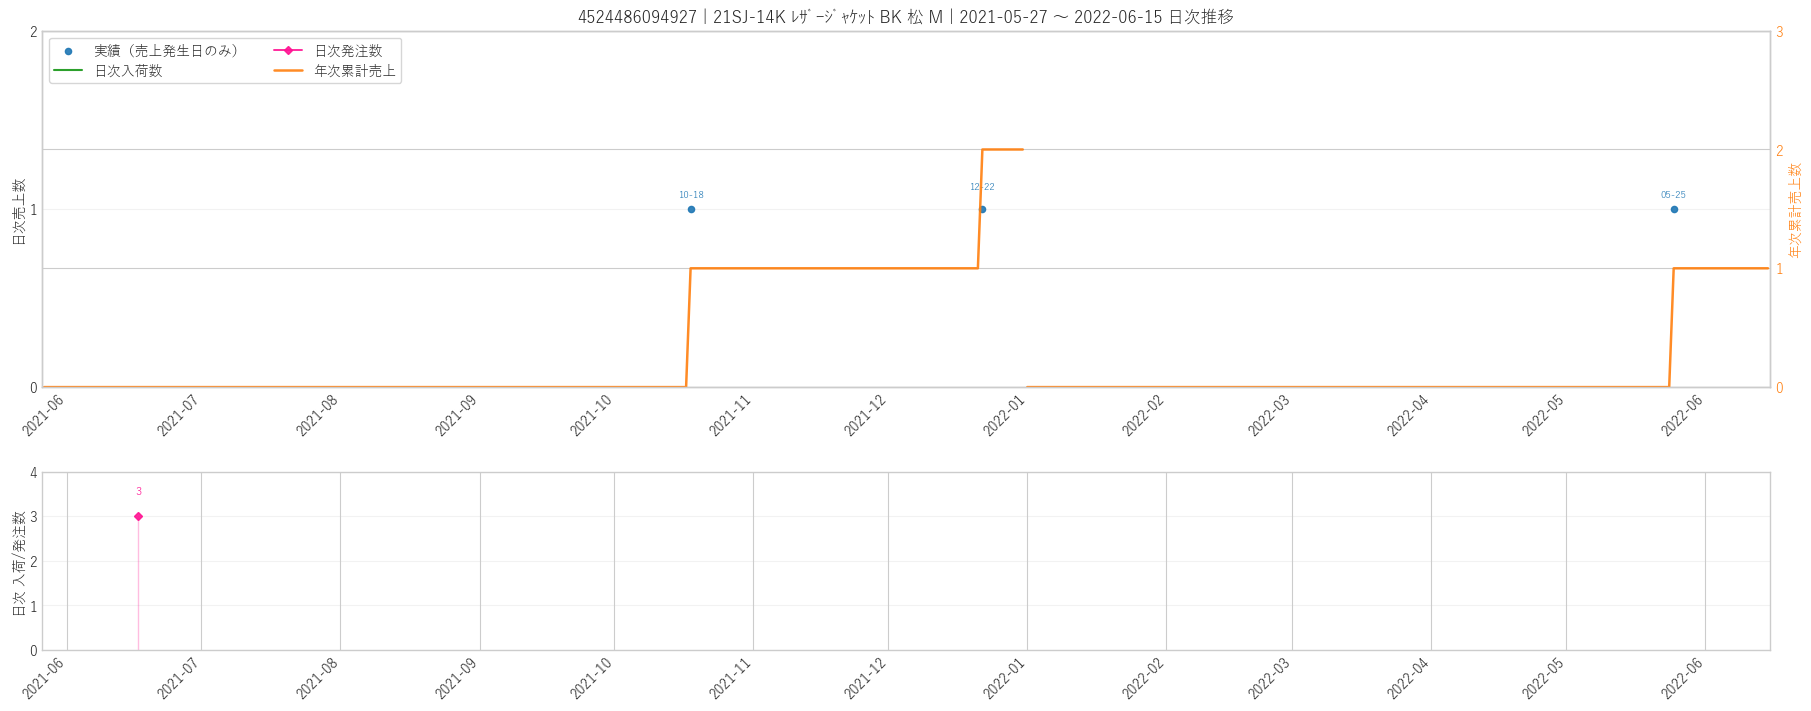

jan                                 4524486094927
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 松 M
sales_total_qty                               3.0
sales_days                                      3
receipt_total_qty                             0.0
receipt_days                                    0
order_total_qty                               3.0
order_days                                      1
stockout_periods                                0
stockout_total_days                           0.0
[46/53] 4524486094941


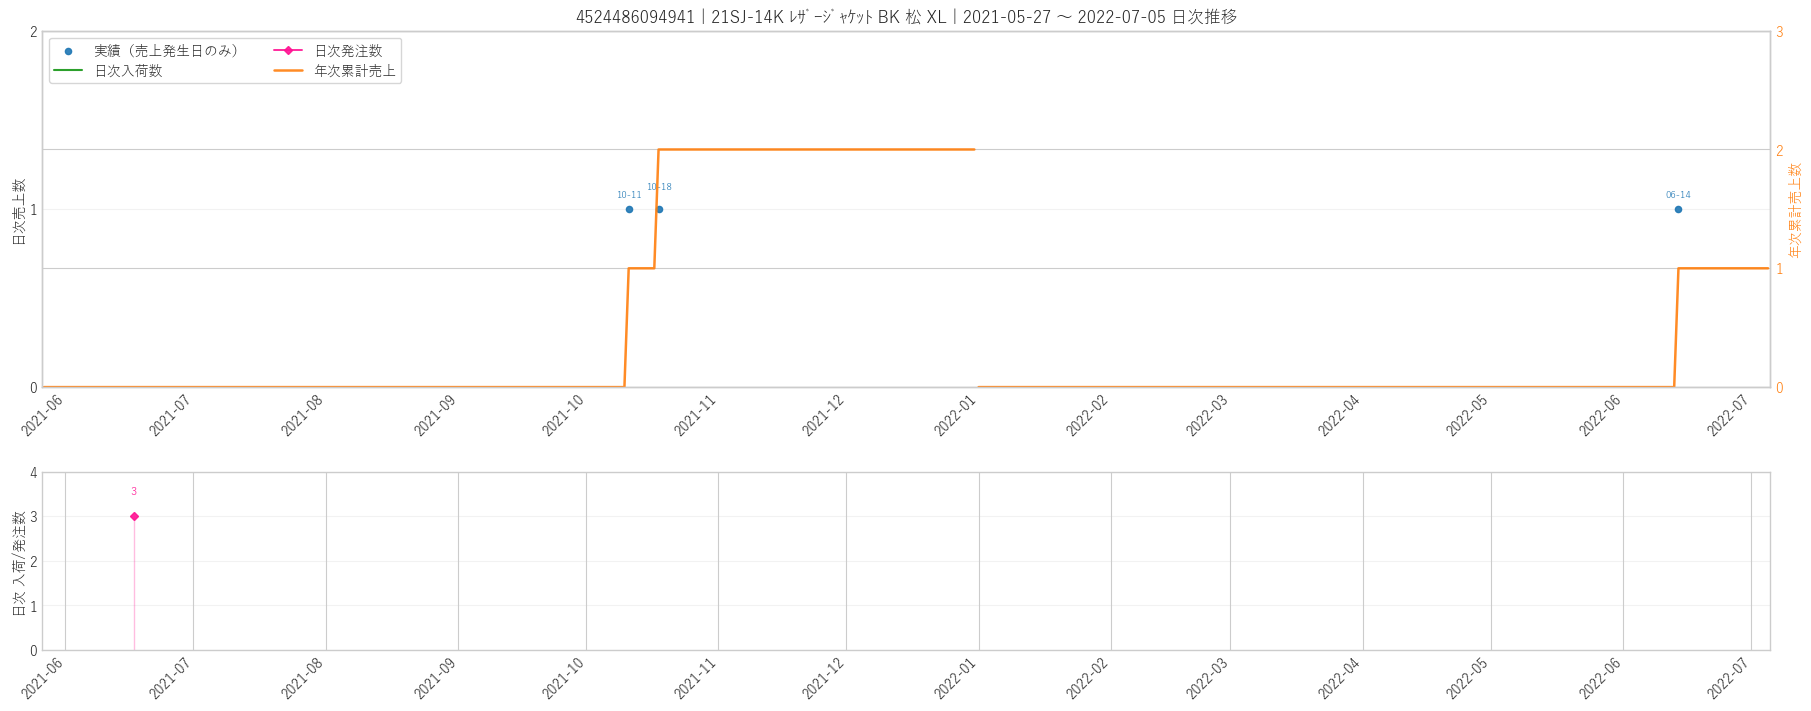

jan                                  4524486094941
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 松 XL
sales_total_qty                                3.0
sales_days                                       3
receipt_total_qty                              0.0
receipt_days                                     0
order_total_qty                                3.0
order_days                                       1
stockout_periods                                 0
stockout_total_days                            0.0
[47/53] 4524486106590


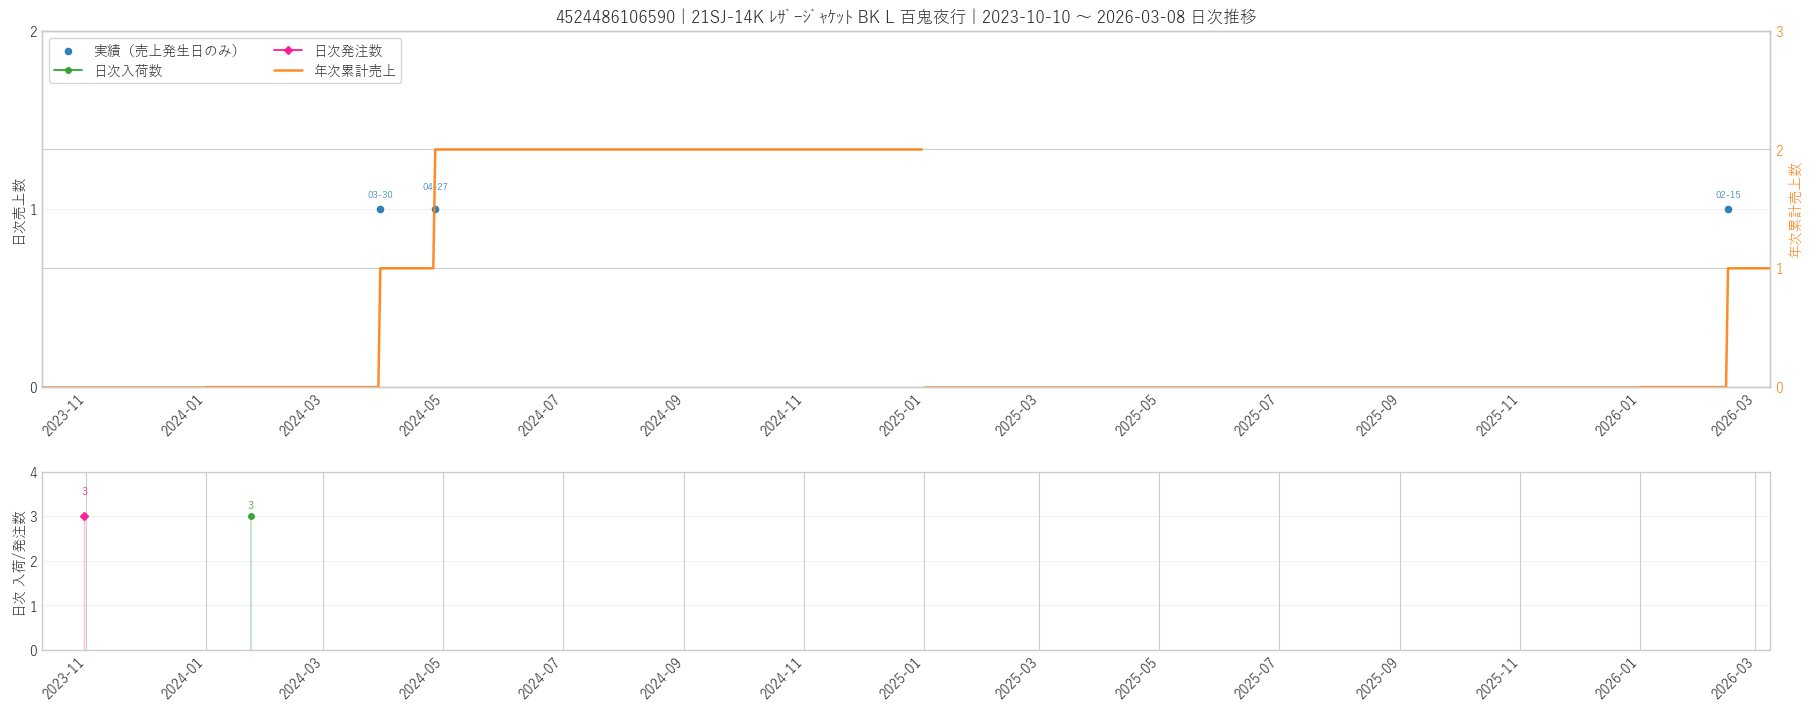

jan                                    4524486106590
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK L 百鬼夜行
sales_total_qty                                  3.0
sales_days                                         3
receipt_total_qty                                3.0
receipt_days                                       1
order_total_qty                                  3.0
order_days                                         1
stockout_periods                                   0
stockout_total_days                              0.0
[48/53] 4524486107771


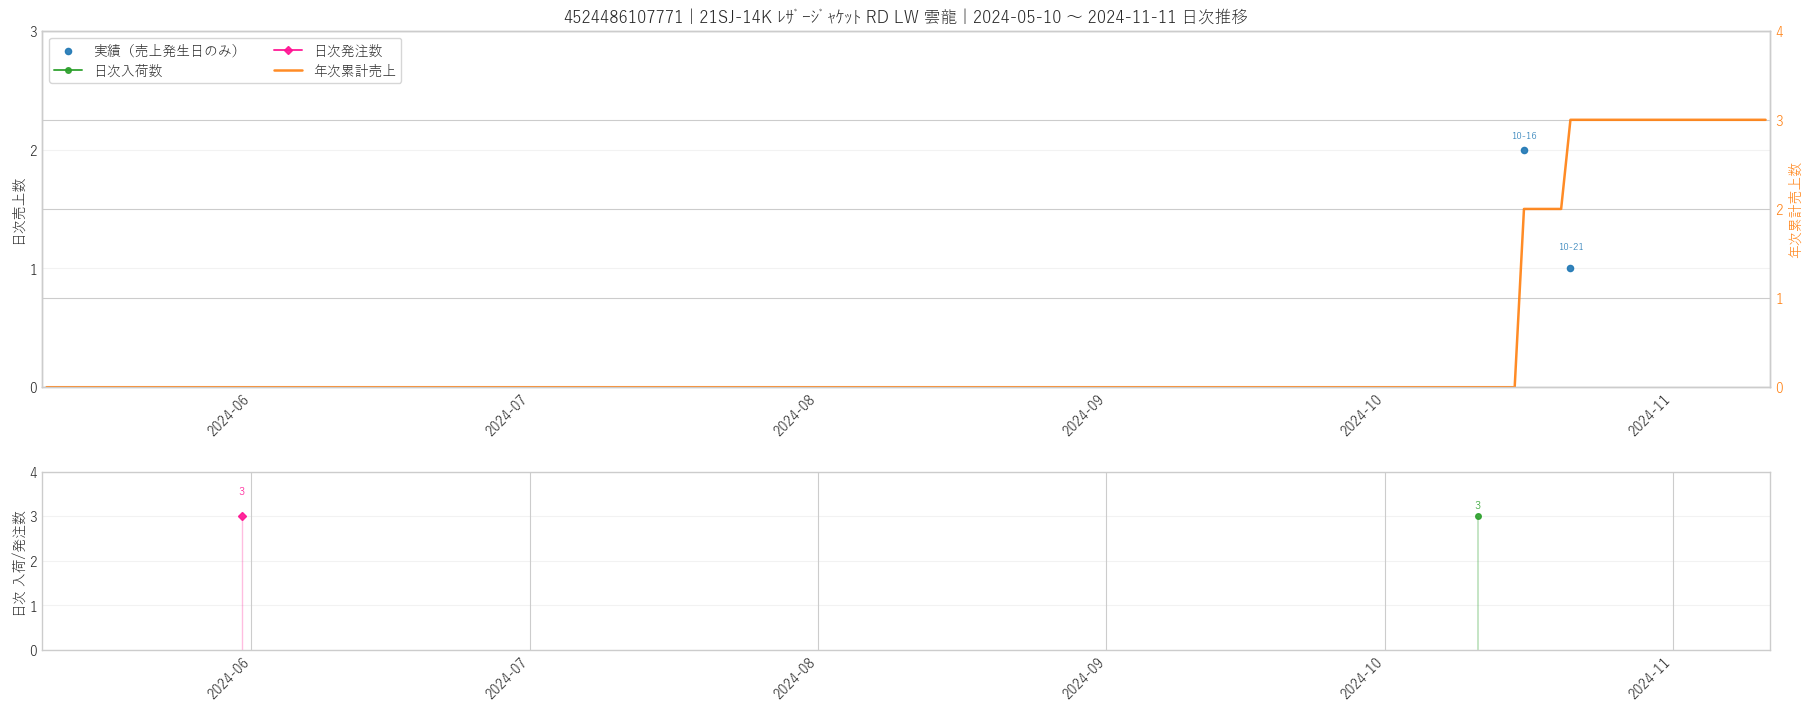

jan                                   4524486107771
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ RD LW 雲龍
sales_total_qty                                 3.0
sales_days                                        2
receipt_total_qty                               3.0
receipt_days                                      1
order_total_qty                                 3.0
order_days                                        1
stockout_periods                                  0
stockout_total_days                             0.0
[49/53] 4524486093623


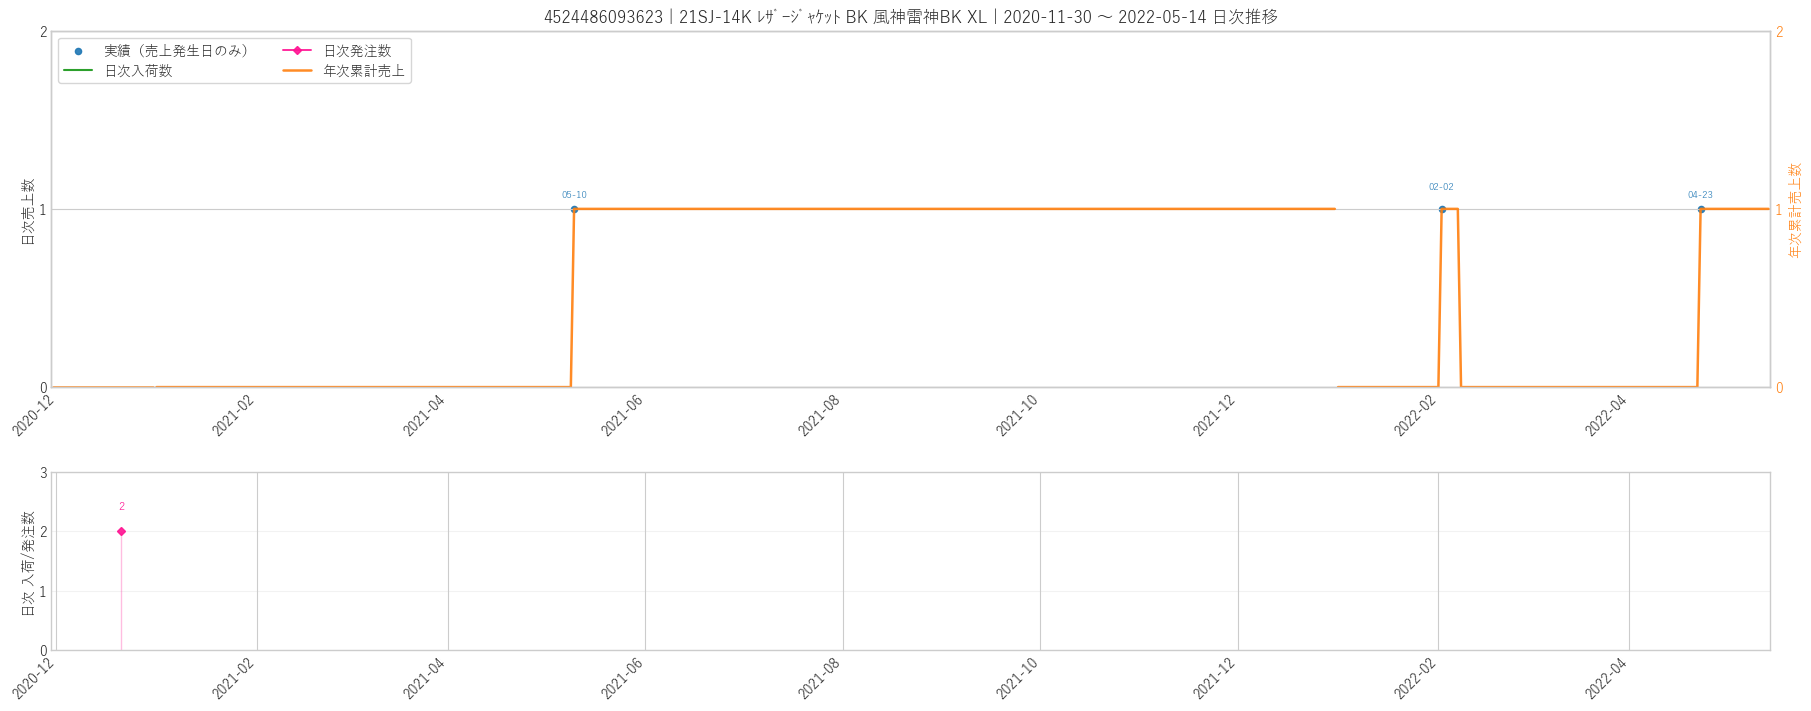

jan                                       4524486093623
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 風神雷神BK XL
sales_total_qty                                     2.0
sales_days                                            4
receipt_total_qty                                   0.0
receipt_days                                          0
order_total_qty                                     2.0
order_days                                            1
stockout_periods                                      0
stockout_total_days                                 0.0
[50/53] 4524486093609


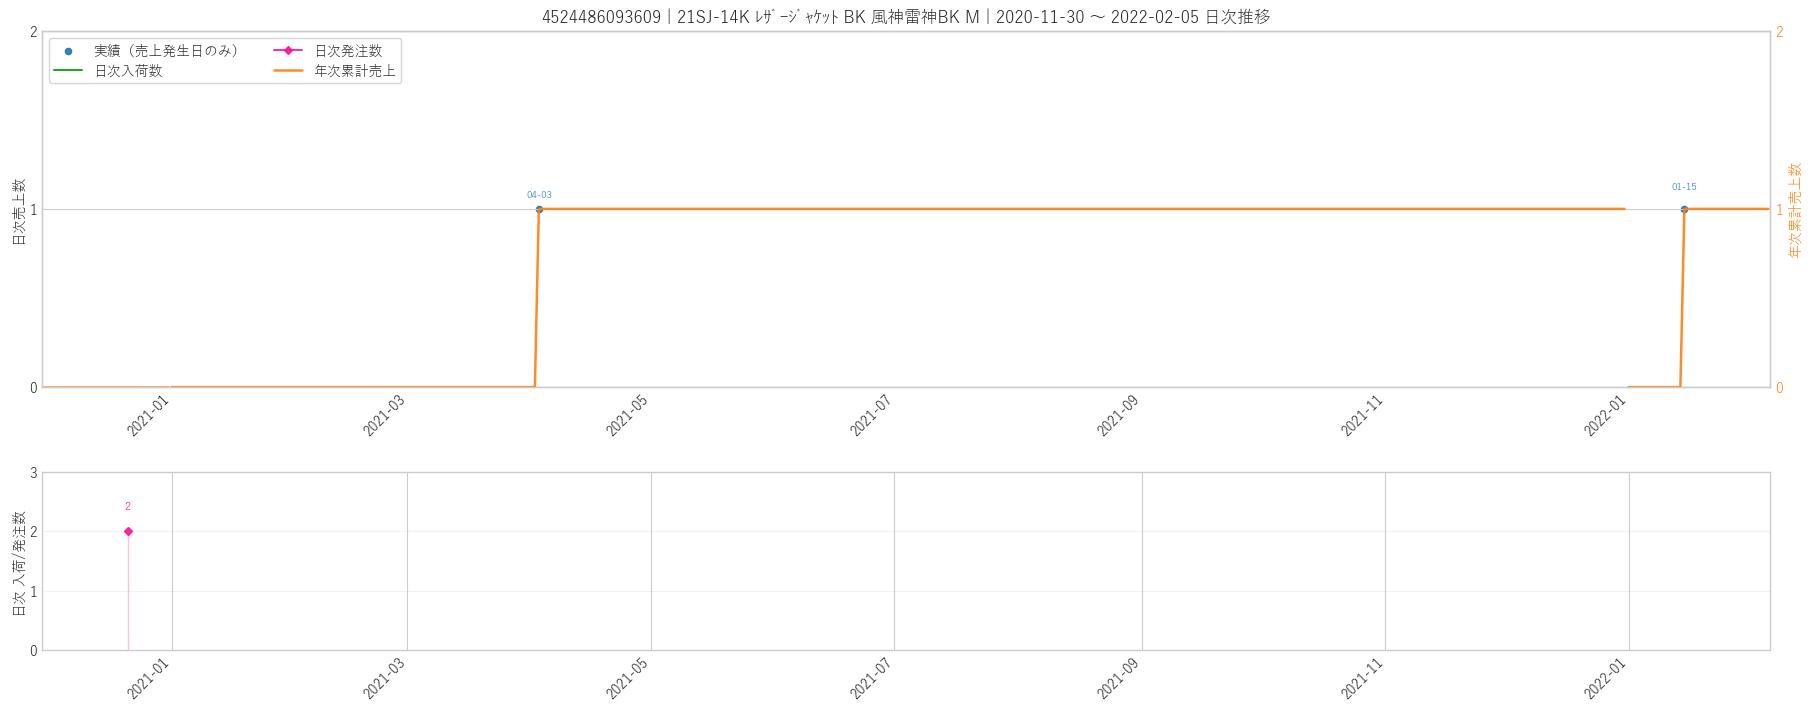

jan                                      4524486093609
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 風神雷神BK M
sales_total_qty                                    2.0
sales_days                                           2
receipt_total_qty                                  0.0
receipt_days                                         0
order_total_qty                                    2.0
order_days                                           1
stockout_periods                                     0
stockout_total_days                                0.0
[51/53] 4524486093616


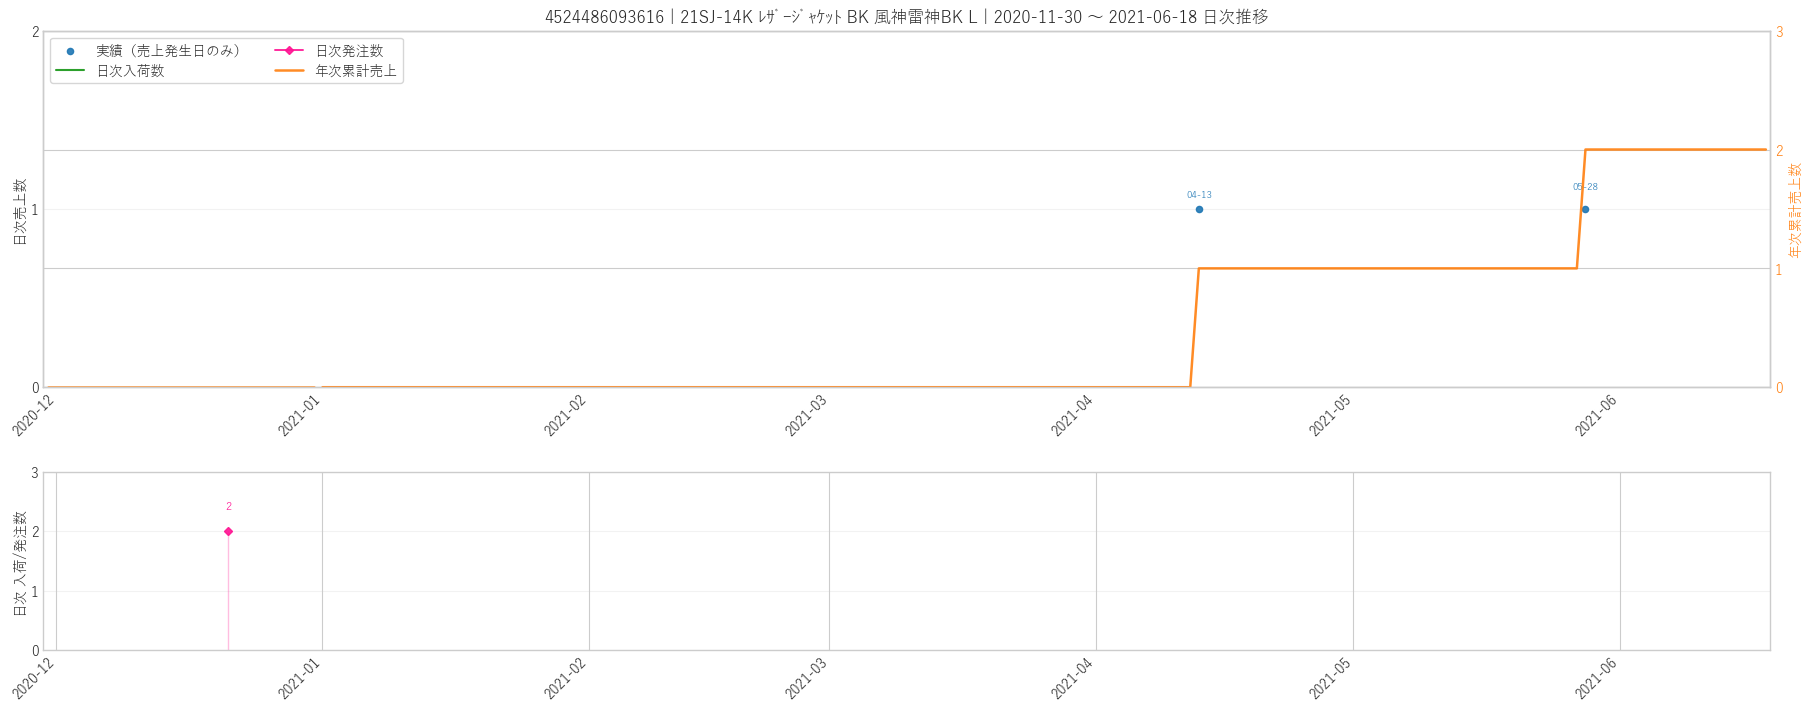

jan                                      4524486093616
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 風神雷神BK L
sales_total_qty                                    2.0
sales_days                                           2
receipt_total_qty                                  0.0
receipt_days                                         0
order_total_qty                                    2.0
order_days                                           1
stockout_periods                                     0
stockout_total_days                                0.0
[52/53] 4524486106583


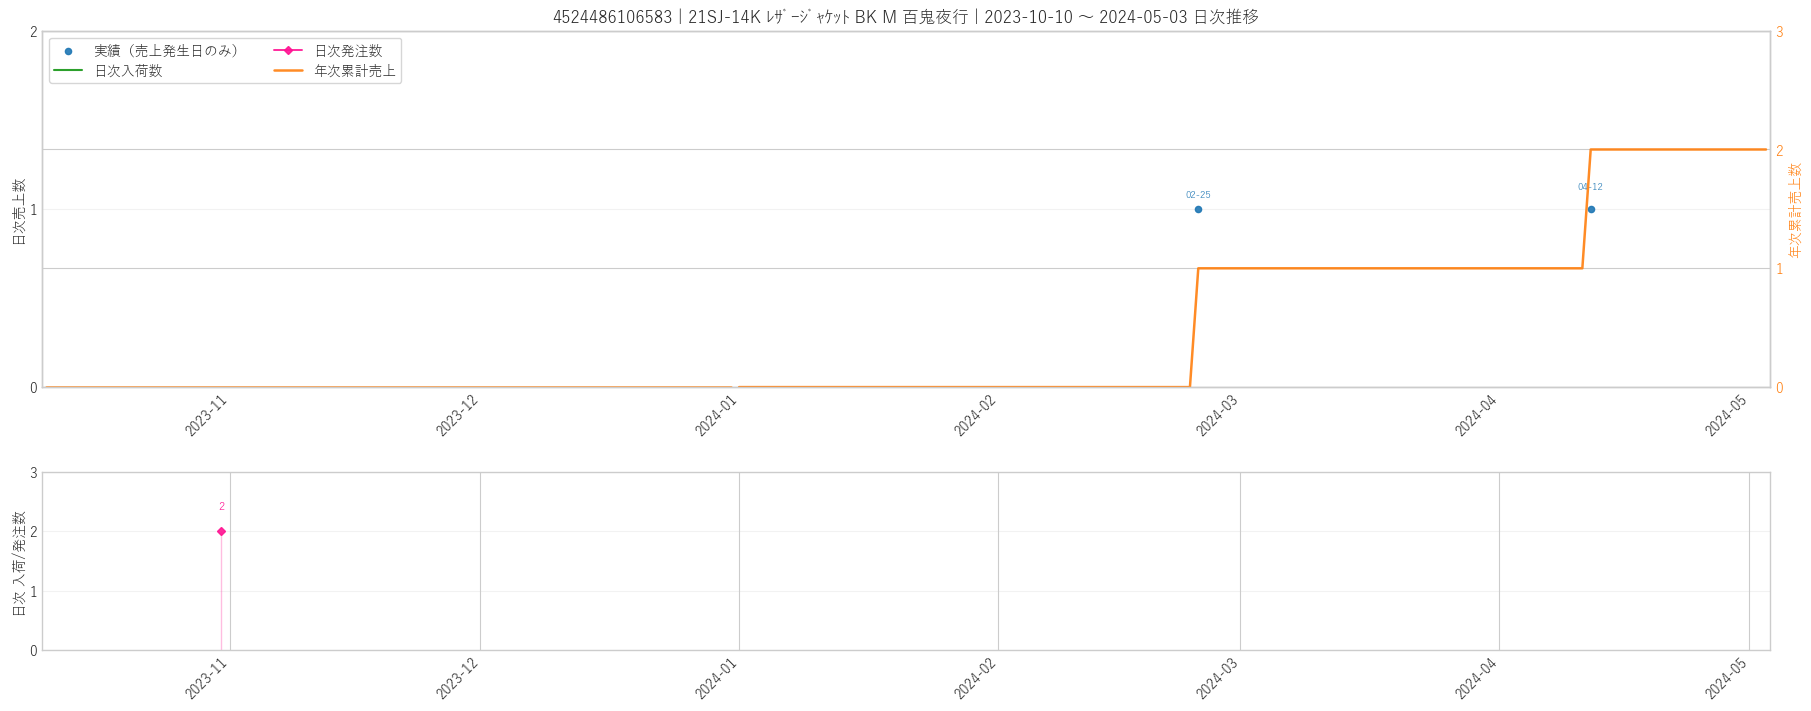

jan                                    4524486106583
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK M 百鬼夜行
sales_total_qty                                  2.0
sales_days                                         2
receipt_total_qty                                0.0
receipt_days                                       0
order_total_qty                                  2.0
order_days                                         1
stockout_periods                                   0
stockout_total_days                              0.0
[53/53] 4524486106606


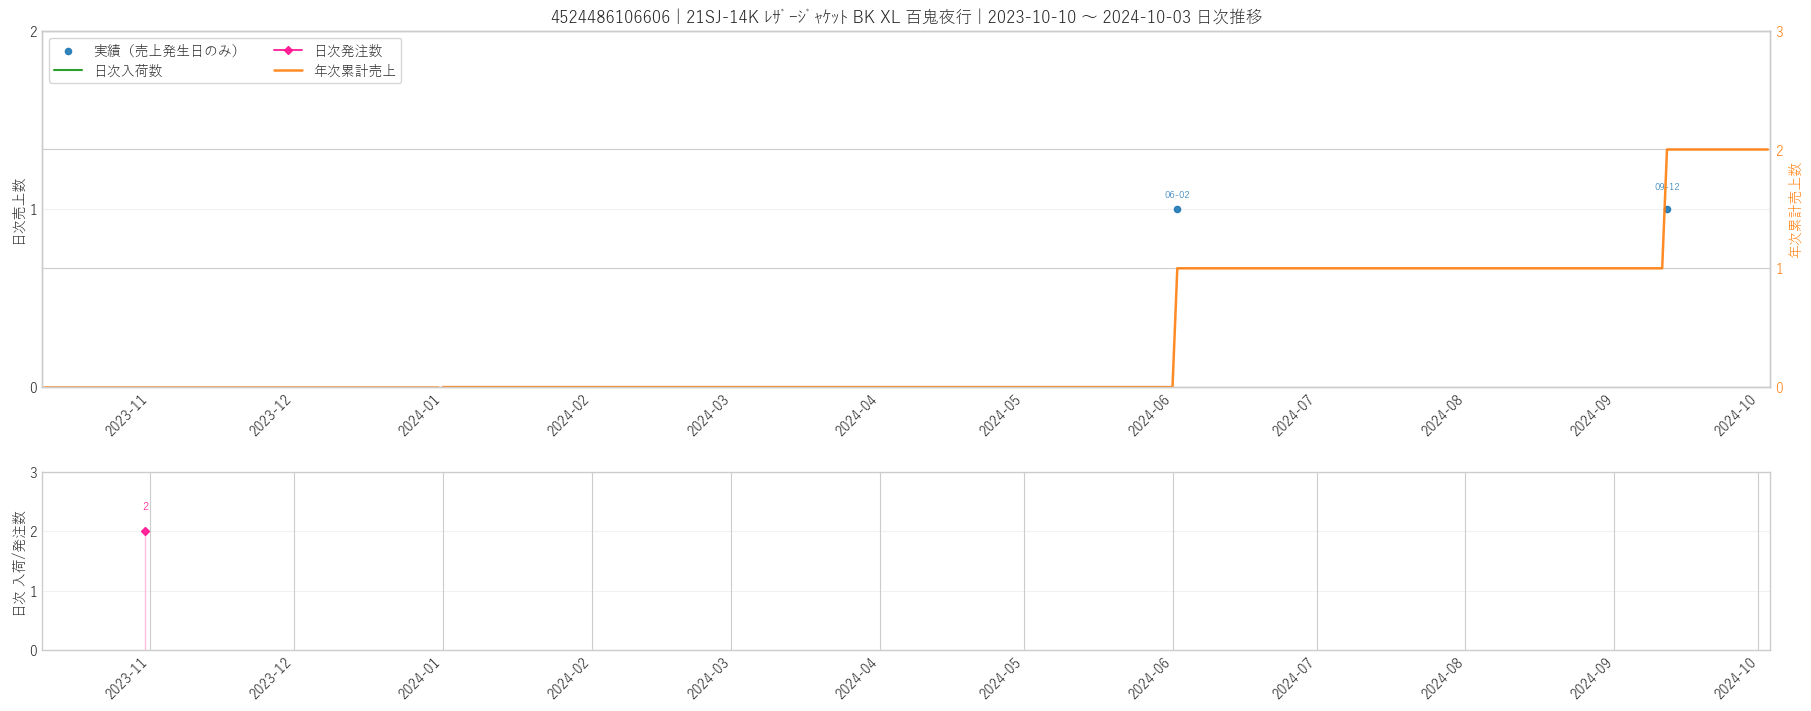

jan                                     4524486106606
item_name              21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK XL 百鬼夜行
sales_total_qty                                   2.0
sales_days                                          2
receipt_total_qty                                 0.0
receipt_days                                        0
order_total_qty                                   2.0
order_days                                          1
stockout_periods                                    0
stockout_total_days                               0.0


In [ ]:
# セル6: 全JANを連続描画（このセルだけ実行すればOK）

# 固定期間（未指定なら自動範囲)
DATE_FROM = None
DATE_TO = None

# 表示範囲モード
# 'active': JANごとの活動期間に自動ズーム（推奨）
# 'global': 全期間を固定
RANGE_MODE = 'active'

# activeモード時の前後余白（日）
PAD_DAYS = 21

# 売上折れ線モード
# 'sales_days': 売れた日だけ線をつなぐ
# 'all_days': 0日も含めて連続線
SALES_LINE_MODE = 'sales_days'

# 売上7日移動平均の表示
ADD_MA7 = False

# 年ごと累計販売数（オレンジ線）の表示
SHOW_YEARLY_CUM = True

# 売上発生日ラベルの表示（件数が多い場合は関数内で自動抑制）
SHOW_SALES_DATE_LABELS = True

# 売り逃し期間に『何日間欠品したか』のラベルを表示
SHOW_STOCKOUT_DAYS = True

# True: 売上実績は線で結ばず、売れた日の点だけ表示
SALES_POINTS_ONLY = True

# 全JANを描画対象にする
target_jans_for_plot = jan_summary['jan'].tolist()
print('plot_count =', len(target_jans_for_plot))

for i, jan in enumerate(target_jans_for_plot, start=1):
    print(f'[{i}/{len(target_jans_for_plot)}] {jan}')
    plot_jan_daily(
        jan,
        date_from=DATE_FROM,
        date_to=DATE_TO,
        range_mode=RANGE_MODE,
        pad_days=PAD_DAYS,
        sales_line_mode=SALES_LINE_MODE,
        show_ma7=ADD_MA7,
        show_yearly_cum=SHOW_YEARLY_CUM,
        show_sales_date_labels=SHOW_SALES_DATE_LABELS,
        show_stockout_days=SHOW_STOCKOUT_DAYS,
        sales_points_only=SALES_POINTS_ONLY,
    )


# 高度分析（売り逃し推定・1か月先予測）

このセクションでは以下を追加します。

- 欠品期間中の売り逃し数量を日次で推定
- 過去売上から次の30日間を予測
- どの計算式で計算しているかをコード内に明記

## モデルの考え方
日次売上 y_t を、「水準成分」と「曜日成分」に分解します。

- y_t ≈ L_t * W_dow(t)
- L_t : EWMA（指数移動平均）で更新する水準値
- W_dow : 曜日別係数（直近データで推定）

売り逃し推定は、欠品開始日の前日までの学習で欠品期間の予測値を出し、次で計算します。

- 売り逃し日次 = max(予測売上 - 実売上, 0)
- 売り逃し期間合計 = 日次売り逃しの総和

未来予測は、最新日までの学習結果で「次の30日」を推定します。


In [7]:
# セル7: 高度分析関数の定義
# 売り逃し推定と・30日予測を共通関数化する

from typing import Dict, Any


def _jan_sales_series(jan_code: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.Series:
    """指定JANの日次売上系列（欠損日0埋め）を返す"""
    jan_code = str(jan_code).strip()
    s = (
        daily_sales[daily_sales['jan'] == jan_code]
        .groupby('sales_date', as_index=True)['sales_qty']
        .sum()
    )
    idx = pd.date_range(start, end, freq='D')
    return s.reindex(idx, fill_value=0.0).astype(float)


def _jan_stockout_mask(jan_code: str, idx: pd.DatetimeIndex) -> pd.Series:
    """指定JANの日付indexに対する欠品マスク（True=欠品）"""
    jan_code = str(jan_code).strip()
    mask = pd.Series(False, index=idx)

    jz = stockouts[stockouts['jan'] == jan_code]
    for _, row in jz.iterrows():
        s = row['stockout_start']
        e = row['restock_date']
        if pd.notna(s) and pd.notna(e) and e >= s:
            s_clip = max(pd.to_datetime(s), idx.min())
            e_clip = min(pd.to_datetime(e), idx.max())
            if e_clip >= s_clip:
                mask.loc[s_clip:e_clip] = True

    return mask


def fit_weekly_ewma_model(
    jan_code: str,
    train_end,
    lookback_days: int = 365,
    alpha: float = 0.25,
    trend_window: int = 56,
) -> Dict[str, Any]:
    """
    週期(曜日)成分 + EWMA水準で予測モデルを学習する

    モデル形:
        y_t ≈ L_t * W_dow(t)

    計算式:
        z_t = y_t / W_dow(t)
        L_t = alpha * z_t + (1 - alpha) * L_(t-1)

    補足:
    - W_dowは直近lookback_daysの非欠品日から推定
    - 欠品日は学習に入れない（需要があっても売れないため）
    """
    jan_code = str(jan_code).strip()
    train_end = pd.to_datetime(train_end)

    js = daily_sales[daily_sales['jan'] == jan_code]
    if js.empty:
        return {
            'jan': jan_code,
            'train_end': train_end,
            'weekday_factors': pd.Series(1.0, index=range(7)),
            'level_last': 0.0,
            'trend_per_day': 0.0,
        }

    hist_start = js['sales_date'].min()
    idx = pd.date_range(hist_start, train_end, freq='D')

    y = _jan_sales_series(jan_code, idx.min(), idx.max())
    stock_mask = _jan_stockout_mask(jan_code, idx)
    valid_mask = ~stock_mask

    lookback_start = train_end - pd.Timedelta(days=max(lookback_days - 1, 1))
    recent_mask = (idx >= lookback_start) & valid_mask.values

    hist = pd.DataFrame({'y': y.values, 'dow': idx.dayofweek}, index=idx)
    hist_recent = hist.loc[recent_mask].copy()

    if hist_recent.empty:
        hist_recent = hist.loc[valid_mask.values].copy()

    overall = float(hist_recent['y'].mean()) if not hist_recent.empty else 0.0
    if not np.isfinite(overall) or overall <= 1e-9:
        overall = 0.1

    dow_mean = hist_recent.groupby('dow')['y'].mean()
    weekday_factors = pd.Series(1.0, index=range(7), dtype=float)

    for d in range(7):
        v = dow_mean.get(d, np.nan)
        if pd.notna(v):
            weekday_factors.loc[d] = float(v) / overall

    weekday_factors = weekday_factors.clip(0.35, 2.50)
    weekday_factors = weekday_factors / weekday_factors.mean()

    dow_arr = pd.Series(idx.dayofweek, index=idx)
    deseason = y / dow_arr.map(weekday_factors)

    # 欠品日は学習しないためNaNにし、前日水準で補間
    deseason_valid = deseason.where(valid_mask, np.nan).ffill().fillna(0.0)
    level = deseason_valid.ewm(alpha=float(alpha), adjust=False).mean()
    level_last = float(level.iloc[-1]) if len(level) else 0.0

    tail = level.tail(max(trend_window, 2))
    if len(tail) >= 14 and np.isfinite(tail.values).all():
        x = np.arange(len(tail), dtype=float)
        trend_per_day = float(np.polyfit(x, tail.values, deg=1)[0])
    else:
        trend_per_day = 0.0

    return {
        'jan': jan_code,
        'train_end': train_end,
        'weekday_factors': weekday_factors,
        'level_last': max(level_last, 0.0),
        'trend_per_day': trend_per_day,
    }


def predict_with_model(model: Dict[str, Any], target_dates) -> pd.Series:
    """学習済みモデルで指定日付の予測値を返す"""
    target_idx = pd.to_datetime(pd.Index(target_dates))
    if len(target_idx) == 0:
        return pd.Series(dtype=float)

    h = (target_idx - pd.to_datetime(model['train_end'])).days.astype(float)
    level_h = np.maximum(float(model['level_last']) + float(model['trend_per_day']) * h, 0.0)

    dow = pd.Series(target_idx.dayofweek, index=target_idx)
    w = dow.map(model['weekday_factors']).astype(float).fillna(1.0)

    yhat = np.maximum(level_h * w.values, 0.0)
    return pd.Series(yhat, index=target_idx)


def estimate_stockout_lost_sales(
    jan_code: str,
    lookback_days: int = 365,
    alpha: float = 0.25,
    trend_window: int = 56,
) -> pd.DataFrame:
    """
    欠品期間の売り逃しを推定する

    各欠品期間[s,e]の前日(s-1)までの情報だけで予測し、
    予測-実績を売り逃しとみなす。
    """
    jan_code = str(jan_code).strip()
    js = daily_sales[daily_sales['jan'] == jan_code]
    if js.empty:
        return pd.DataFrame(columns=[
            'jan', 'stockout_start', 'restock_date', 'days_out',
            'pred_sales_during_stockout', 'actual_sales_during_stockout', 'lost_sales_est'
        ])

    data_start = js['sales_date'].min()
    data_end = daily_sales['sales_date'].max()

    y_all = _jan_sales_series(jan_code, data_start, data_end)
    jz = stockouts[stockouts['jan'] == jan_code].copy()

    rows = []
    for _, row in jz.iterrows():
        s = pd.to_datetime(row['stockout_start'])
        e = pd.to_datetime(row['restock_date'])
        if pd.isna(s) or pd.isna(e) or e < s:
            continue

        s_clip = max(s, data_start)
        e_clip = min(e, data_end)
        if e_clip < s_clip:
            continue

        days = pd.date_range(s_clip, e_clip, freq='D')
        train_end = s_clip - pd.Timedelta(days=1)
        if train_end < data_start:
            train_end = s_clip

        model = fit_weekly_ewma_model(
            jan_code,
            train_end=train_end,
            lookback_days=lookback_days,
            alpha=alpha,
            trend_window=trend_window,
        )
        pred = predict_with_model(model, days)
        actual = y_all.reindex(days, fill_value=0.0)

        lost_daily = np.maximum(pred.values - actual.values, 0.0)

        days_out = row.get('days_out', np.nan)
        if pd.isna(days_out):
            days_out = (e - s).days

        rows.append({
            'jan': jan_code,
            'stockout_start': s,
            'restock_date': e,
            'days_out': float(days_out),
            'pred_sales_during_stockout': float(pred.sum()),
            'actual_sales_during_stockout': float(actual.sum()),
            'lost_sales_est': float(lost_daily.sum()),
        })

    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.sort_values(['stockout_start', 'restock_date'])
    return out


def forecast_next_30_days(
    jan_code: str,
    horizon_days: int = 30,
    lookback_days: int = 365,
    alpha: float = 0.25,
    trend_window: int = 56,
    residual_window: int = 180,
) -> pd.DataFrame:
    """
    最新日の次日からhorizon_days日の予測を返す

    予測区間は、直近残差から簡易推定したPI80/PI95を付与。
    """
    jan_code = str(jan_code).strip()
    train_end = daily_sales['sales_date'].max()

    model = fit_weekly_ewma_model(
        jan_code,
        train_end=train_end,
        lookback_days=lookback_days,
        alpha=alpha,
        trend_window=trend_window,
    )

    future_idx = pd.date_range(train_end + pd.Timedelta(days=1), periods=int(horizon_days), freq='D')
    yhat = predict_with_model(model, future_idx)

    hist_start = train_end - pd.Timedelta(days=max(residual_window - 1, 1))
    hist_idx = pd.date_range(hist_start, train_end, freq='D')

    y_hist = _jan_sales_series(jan_code, hist_idx.min(), hist_idx.max())
    pred_hist = predict_with_model(model, hist_idx)
    mask_hist_stockout = _jan_stockout_mask(jan_code, hist_idx)

    resid = (y_hist - pred_hist).loc[~mask_hist_stockout]
    resid = resid[np.isfinite(resid.values)]

    if len(resid) >= 10:
        med = float(np.median(resid.values))
        mad = float(np.median(np.abs(resid.values - med)))
        sigma = max(1.4826 * mad, 0.5)
    else:
        sigma = max(float(np.std(resid.values)) if len(resid) else 1.0, 1.0)

    out = pd.DataFrame({'date': future_idx, 'forecast_qty': yhat.values})
    out['pi80_lower'] = np.maximum(out['forecast_qty'] - 1.2816 * sigma, 0.0)
    out['pi80_upper'] = np.maximum(out['forecast_qty'] + 1.2816 * sigma, 0.0)
    out['pi95_lower'] = np.maximum(out['forecast_qty'] - 1.9600 * sigma, 0.0)
    out['pi95_upper'] = np.maximum(out['forecast_qty'] + 1.9600 * sigma, 0.0)

    return out


def _apply_visual_offset_axis(ax, visual_y_offset: float):
    """表示オフセット適用時に、目盛りラベルを元の数量スケールで表示する"""
    offset = max(float(visual_y_offset), 0.0)
    if offset <= 0:
        return

    from matplotlib.ticker import FuncFormatter

    def _fmt(v, _):
        raw = float(v) - offset
        if abs(raw - round(raw)) < 1e-8:
            return f"{int(round(raw))}"
        return f"{raw:.1f}"

    ax.yaxis.set_major_formatter(FuncFormatter(_fmt))


def analyze_jan_advanced(
    jan_code: str,
    horizon_days: int = 30,
    show_history_days: int = 540,
    lookback_days: int = 365,
    alpha: float = 0.25,
    trend_window: int = 56,
    visual_y_offset: float = 0.0,
    future_pad_days: int = 21,
    sales_points_only: bool = True,
    latest_year_forecast_color: str = 'mediumvioletred',
    show_plot: bool = True,
):
    """指定JANの高度分析（売り逃し推定 + 未来予測 + 年別累計線）を実行"""
    jan_code = str(jan_code).strip()
    end_hist = daily_sales['sales_date'].max()
    start_hist = max(daily_sales['sales_date'].min(), end_hist - pd.Timedelta(days=show_history_days - 1))

    y_hist = _jan_sales_series(jan_code, start_hist, end_hist)
    fc = forecast_next_30_days(
        jan_code,
        horizon_days=horizon_days,
        lookback_days=lookback_days,
        alpha=alpha,
        trend_window=trend_window,
    )
    lost_df = estimate_stockout_lost_sales(
        jan_code,
        lookback_days=lookback_days,
        alpha=alpha,
        trend_window=trend_window,
    )

    total_lost = float(lost_df['lost_sales_est'].sum()) if not lost_df.empty else 0.0
    total_fc30 = float(fc['forecast_qty'].sum()) if not fc.empty else 0.0

    summary = pd.Series({
        'jan': jan_code,
        'item_name': jan_name_map.get(jan_code, ''),
        'hist_sales_total': float(y_hist.sum()),
        'hist_sales_mean_per_day': float(y_hist.mean()) if len(y_hist) else 0.0,
        'stockout_periods': int(len(lost_df)),
        'lost_sales_est_total': total_lost,
        'forecast_30d_total': total_fc30,
        'forecast_30d_mean_per_day': total_fc30 / max(int(horizon_days), 1),
    })

    if show_plot:
        vis = max(float(visual_y_offset), 0.0)
        pad = max(int(future_pad_days), 0)

        fig, (ax1, ax2) = plt.subplots(
            2,
            1,
            figsize=(20, 8),
            sharex=False,
            constrained_layout=True,
            gridspec_kw={'height_ratios': [3.2, 1.6], 'hspace': 0.10}
        )

        y_hist_plot = y_hist + vis

        if sales_points_only:
            nz = y_hist_plot[y_hist > 0]
            ax1.scatter(
                nz.index,
                nz.values,
                color='tab:blue',
                s=20,
                alpha=0.9,
                label='実績売上（売れた日のみ）',
                zorder=4,
            )
        else:
            ax1.plot(
                y_hist.index,
                y_hist_plot.values,
                color='tab:blue',
                linewidth=1.2,
                marker='o',
                markersize=2.5,
                alpha=0.85,
                label='実績売上（日次）',
            )

        if not fc.empty:
            fc_plot = fc.copy()
            for c in ['forecast_qty', 'pi80_lower', 'pi80_upper', 'pi95_lower', 'pi95_upper']:
                fc_plot[c] = fc_plot[c] + vis

            ax1.plot(
                fc_plot['date'],
                fc_plot['forecast_qty'],
                color='tab:orange',
                linewidth=2.0,
                marker='o',
                markersize=3,
                alpha=0.68,
                label='予測売上（次の30日）',
            )
            ax1.fill_between(fc_plot['date'], fc_plot['pi80_lower'], fc_plot['pi80_upper'], color='tab:orange', alpha=0.12, label='PI80')
            ax1.fill_between(fc_plot['date'], fc_plot['pi95_lower'], fc_plot['pi95_upper'], color='tab:orange', alpha=0.06, label='PI95')

        view_start = y_hist.index.min()
        core_end = fc['date'].max() if not fc.empty else y_hist.index.max()
        view_end = core_end + pd.Timedelta(days=pad)

        # 累計販売数を2種類で重ねる
        # 1) 年単位累計（年ごとに1月1日から積み上げ）
        # 2) 全期間累計（初回販売日からの通算）
        ax1_cum = ax1.twinx()
        latest_year = int(end_hist.year)

        cum_year_start = pd.Timestamp(year=int(view_start.year), month=1, day=1)
        y_for_yearly_cum = _jan_sales_series(jan_code, cum_year_start, end_hist)
        years = sorted(pd.Index(pd.date_range(cum_year_start, view_end, freq='D').year).unique())

        cum_max = 0.0

        # 全期間累計（通算）
        jan_start = daily_sales.loc[daily_sales['jan'] == jan_code, 'sales_date'].min()
        jan_start = jan_start if pd.notna(jan_start) else view_start
        y_for_total_cum = _jan_sales_series(jan_code, jan_start, end_hist)
        total_cum = y_for_total_cum.cumsum()
        total_plot = total_cum[(total_cum.index >= view_start) & (total_cum.index <= end_hist)]
        if len(total_plot) > 0:
            ax1_cum.plot(
                total_plot.index,
                total_plot.values,
                color='tab:olive',
                linewidth=1.7,
                alpha=0.78,
                label='全期間累計実績',
            )
            cum_max = max(cum_max, float(total_plot.max()))

        # 年単位累計（実績）
        for y in years:
            y_part = y_for_yearly_cum[y_for_yearly_cum.index.year == y]
            if len(y_part) == 0:
                continue
            y_cum = y_part.cumsum()
            y_plot = y_cum[(y_cum.index >= view_start) & (y_cum.index <= end_hist)]
            if len(y_plot) == 0:
                continue

            if int(y) == latest_year:
                c = 'dimgray'; a = 0.60; lw = 1.8
            else:
                c = 'tab:gray'; a = 0.35; lw = 1.2

            ax1_cum.plot(
                y_plot.index,
                y_plot.values,
                color=c,
                linewidth=lw,
                alpha=a,
                label=f'{int(y)}年 年単位累計実績',
            )
            cum_max = max(cum_max, float(y_plot.max()))

        # 最新年の年単位累計予測（色分け + 数値注釈）
        if not fc.empty:
            fc_latest = fc[fc['date'].dt.year == latest_year].copy()
            y_latest = y_for_yearly_cum[y_for_yearly_cum.index.year == latest_year]
            base_cum = float(y_latest.cumsum().iloc[-1]) if len(y_latest) else 0.0

            if not fc_latest.empty:
                fc_latest['cum_forecast'] = base_cum + fc_latest['forecast_qty'].cumsum()
                ax1_cum.plot(
                    fc_latest['date'],
                    fc_latest['cum_forecast'],
                    color=latest_year_forecast_color,
                    linewidth=2.1,
                    linestyle='--',
                    alpha=0.68,
                    label=f'{latest_year}年 年単位累計予測',
                )

                for _, r in fc_latest.iloc[::7].iterrows():
                    ax1_cum.annotate(
                        f"{r['cum_forecast']:.1f}",
                        (r['date'], r['cum_forecast']),
                        textcoords='offset points',
                        xytext=(0, 8),
                        ha='center',
                        fontsize=8,
                        color=latest_year_forecast_color,
                        alpha=0.92,
                    )
                r_last = fc_latest.iloc[-1]
                ax1_cum.annotate(
                    f"{r_last['cum_forecast']:.1f}",
                    (r_last['date'], r_last['cum_forecast']),
                    textcoords='offset points',
                    xytext=(0, 10),
                    ha='center',
                    fontsize=8,
                    color=latest_year_forecast_color,
                    fontweight='bold',
                    bbox={'boxstyle': 'round,pad=0.16', 'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.60},
                )
                cum_max = max(cum_max, float(fc_latest['cum_forecast'].max()))

        ax1_cum.set_ylim(0, max(1.0, np.ceil(cum_max) + 1.0))
        ax1_cum.yaxis.set_major_locator(MaxNLocator(integer=True))
        ax1_cum.set_ylabel('累計販売数（年単位 / 全期間）', color='dimgray')
        ax1_cum.tick_params(axis='y', labelcolor='dimgray')

        jz = stockouts[stockouts['jan'] == jan_code].copy()
        jz = jz[(jz['restock_date'] >= view_start) & (jz['stockout_start'] <= view_end)]
        _draw_stockout_spans(ax1, jz, view_start, view_end, show_days_label=True)

        if not lost_df.empty:
            for i, row in lost_df.iterrows():
                s2 = pd.to_datetime(row['stockout_start'])
                e2 = pd.to_datetime(row['restock_date'])
                if e2 < view_start or s2 > view_end:
                    continue
                s_clip = max(s2, view_start)
                e_clip = min(e2, view_end)
                mid = s_clip + (e_clip - s_clip) / 2
                txt = f"lost~{row['lost_sales_est']:.1f}"
                ax1.text(
                    mid,
                    0.82 if (i % 2 == 0) else 0.74,
                    txt,
                    transform=ax1.get_xaxis_transform(),
                    ha='center',
                    va='top',
                    fontsize=8,
                    color='tab:red',
                    bbox={'boxstyle': 'round,pad=0.18', 'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.65},
                )

        max_y_raw = max(float(y_hist.max()) if len(y_hist) else 0.0, float(fc['pi95_upper'].max()) if not fc.empty else 0.0)
        ax1.set_ylim(vis, vis + max(1.0, np.ceil(max_y_raw) + 1.0))
        ax1.yaxis.set_major_locator(MaxNLocator(integer=True))
        _apply_visual_offset_axis(ax1, vis)

        if vis > 0:
            ax1.set_ylabel(f'日次売上数（表示+{vis:g}）')
        else:
            ax1.set_ylabel('日次売上数')

        ax1.grid(axis='y', alpha=0.25)

        item_name = jan_name_map.get(jan_code, '')
        title = f"{jan_code}" if not item_name else f"{jan_code} | {item_name}"
        title += f" | advanced analysis (lost-sales + {horizon_days}d forecast)"
        ax1.set_title(title)

        x2_start = y_hist.index.min()
        x2_end = view_end
        idx2 = pd.date_range(x2_start, x2_end, freq='D')

        r = (
            receipts_daily[receipts_daily['jan'] == jan_code]
            .groupby('receipt_date', as_index=True)['receipt_qty']
            .sum()
            .reindex(idx2, fill_value=0.0)
        )
        o = (
            orders_daily[orders_daily['jan'] == jan_code]
            .groupby('order_date', as_index=True)['order_qty']
            .sum()
            .reindex(idx2, fill_value=0.0)
        )

        nzr = r[r > 0]
        nzo = o[o > 0]

        if len(nzr) > 0:
            nzr_plot = nzr + vis
            ax2.plot(nzr_plot.index, nzr_plot.values, color='tab:green', linewidth=1.4, marker='o', markersize=3.5, alpha=0.9, label='日次入荷数')
            ax2.vlines(nzr_plot.index, vis, nzr_plot.values, color='tab:green', alpha=0.30, linewidth=1.0)
        else:
            ax2.plot([], [], color='tab:green', label='日次入荷数')

        if len(nzo) > 0:
            nzo_plot = nzo + vis
            ax2.plot(nzo_plot.index, nzo_plot.values, color='deeppink', linewidth=1.4, marker='D', markersize=3.5, alpha=0.9, label='日次発注数')
            ax2.vlines(nzo_plot.index, vis, nzo_plot.values, color='deeppink', alpha=0.25, linewidth=1.0)
        else:
            ax2.plot([], [], color='deeppink', label='日次発注数')

        max2_raw = max(float(r.max()) if len(r) else 0.0, float(o.max()) if len(o) else 0.0)
        ax2.set_ylim(vis, vis + max(1.0, np.ceil(max2_raw) + 1.0))
        ax2.yaxis.set_major_locator(MaxNLocator(integer=True))
        _apply_visual_offset_axis(ax2, vis)

        if vis > 0:
            ax2.set_ylabel(f'日次 入荷/発注数（表示+{vis:g}）')
        else:
            ax2.set_ylabel('日次 入荷/発注数')

        ax2.grid(axis='y', alpha=0.25)

        set_adaptive_date_ticks(ax1, x2_start, x2_end)
        set_adaptive_date_ticks(ax2, x2_start, x2_end)
        ax1.set_xlim(x2_start - pd.Timedelta(days=0.5), x2_end + pd.Timedelta(days=0.5))
        ax2.set_xlim(x2_start - pd.Timedelta(days=0.5), x2_end + pd.Timedelta(days=0.5))
        plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
        plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

        h1, l1 = ax1.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        h3, l3 = ax1_cum.get_legend_handles_labels()
        ax1.legend(h1 + h2 + h3, l1 + l2 + l3, loc='upper left', frameon=True, ncols=2)

        plt.show()
        plt.close(fig)

    print(summary.to_string())

    if not lost_df.empty:
        display_cols = ['stockout_start', 'restock_date', 'days_out', 'pred_sales_during_stockout', 'actual_sales_during_stockout', 'lost_sales_est']
        print('\n[欠品期間ごとの売り逃し推定]')
        print(lost_df[display_cols].to_string(index=False))

    print('\n[未来予測（日次）]')
    print(fc.to_string(index=False))

    return {
        'summary': summary,
        'lost_df': lost_df,
        'forecast_df': fc,
    }


def _build_history_forecast_chart_base64(
    jan_code: str,
    horizon_days: int,
    lookback_days: int,
    alpha: float,
    trend_window: int,
    chart_history_days: int = 365,
    visual_y_offset: float = 0.0,
    future_pad_days: int = 21,
    sales_points_only: bool = True,
    latest_year_forecast_color: str = 'mediumvioletred',
):
    """HTML埋め込み用に、年別累計線付きの図をbase64 PNGで返す"""
    from io import BytesIO
    import base64

    jan_code = str(jan_code).strip()
    js = daily_sales[daily_sales['jan'] == jan_code]
    if js.empty:
        return ''

    vis = max(float(visual_y_offset), 0.0)
    pad = max(int(future_pad_days), 0)

    end_hist = daily_sales['sales_date'].max()
    start_hist = max(js['sales_date'].min(), end_hist - pd.Timedelta(days=max(chart_history_days - 1, 1)))

    y_hist = _jan_sales_series(jan_code, start_hist, end_hist)
    fc = forecast_next_30_days(
        jan_code,
        horizon_days=horizon_days,
        lookback_days=lookback_days,
        alpha=alpha,
        trend_window=trend_window,
    )

    fig, ax = plt.subplots(figsize=(14.8, 3.8), constrained_layout=True)

    y_hist_plot = y_hist + vis
    if sales_points_only:
        nz = y_hist_plot[y_hist > 0]
        ax.scatter(
            nz.index,
            nz.values,
            color='tab:blue',
            s=18,
            alpha=0.9,
            label='実績（売れた日のみ）',
            zorder=4,
        )
    else:
        ax.plot(
            y_hist.index,
            y_hist_plot.values,
            color='tab:blue',
            linewidth=1.2,
            marker='o',
            markersize=2.4,
            alpha=0.85,
            label='実績',
        )

    if not fc.empty:
        fc_plot = fc.copy()
        for c in ['forecast_qty', 'pi80_lower', 'pi80_upper', 'pi95_lower', 'pi95_upper']:
            fc_plot[c] = fc_plot[c] + vis

        ax.plot(
            fc_plot['date'],
            fc_plot['forecast_qty'],
            color='tab:orange',
            linewidth=2.0,
            marker='o',
            markersize=2.8,
            alpha=0.68,
            label='予測',
        )
        ax.fill_between(fc_plot['date'], fc_plot['pi80_lower'], fc_plot['pi80_upper'], color='tab:orange', alpha=0.12, label='PI80')

    # 累計販売数を2種類で重ねる（年単位累計 / 全期間累計）
    ax_cum = ax.twinx()
    view_start = y_hist.index.min()
    core_end = fc['date'].max() if not fc.empty else y_hist.index.max()
    view_end = core_end + pd.Timedelta(days=pad)
    latest_year = int(end_hist.year)

    cum_year_start = pd.Timestamp(year=int(view_start.year), month=1, day=1)
    y_for_yearly_cum = _jan_sales_series(jan_code, cum_year_start, end_hist)
    years = sorted(pd.Index(pd.date_range(cum_year_start, view_end, freq='D').year).unique())

    cum_max = 0.0

    # 全期間累計（通算）
    jan_start = js['sales_date'].min() if not js.empty else view_start
    y_for_total_cum = _jan_sales_series(jan_code, jan_start, end_hist)
    total_cum = y_for_total_cum.cumsum()
    total_plot = total_cum[(total_cum.index >= view_start) & (total_cum.index <= end_hist)]
    if len(total_plot) > 0:
        ax_cum.plot(
            total_plot.index,
            total_plot.values,
            color='tab:olive',
            linewidth=1.7,
            alpha=0.78,
            label='全期間累計実績',
        )
        cum_max = max(cum_max, float(total_plot.max()))

    # 年単位累計（実績）
    for y in years:
        y_part = y_for_yearly_cum[y_for_yearly_cum.index.year == y]
        if len(y_part) == 0:
            continue
        y_cum = y_part.cumsum()
        y_plot = y_cum[(y_cum.index >= view_start) & (y_cum.index <= end_hist)]
        if len(y_plot) == 0:
            continue

        if int(y) == latest_year:
            c = 'dimgray'; a = 0.60; lw = 1.8
        else:
            c = 'tab:gray'; a = 0.35; lw = 1.2

        ax_cum.plot(y_plot.index, y_plot.values, color=c, linewidth=lw, alpha=a, label=f'{int(y)}年 年単位累計実績')
        cum_max = max(cum_max, float(y_plot.max()))

    # 最新年の年単位累計予測（色分け + 数値注釈）
    if not fc.empty:
        fc_latest = fc[fc['date'].dt.year == latest_year].copy()
        y_latest = y_for_yearly_cum[y_for_yearly_cum.index.year == latest_year]
        base_cum = float(y_latest.cumsum().iloc[-1]) if len(y_latest) else 0.0
        if not fc_latest.empty:
            fc_latest['cum_forecast'] = base_cum + fc_latest['forecast_qty'].cumsum()
            ax_cum.plot(
                fc_latest['date'],
                fc_latest['cum_forecast'],
                color=latest_year_forecast_color,
                linewidth=2.0,
                linestyle='--',
                alpha=0.68,
                label=f'{latest_year}年 年単位累計予測',
            )
            for _, r in fc_latest.iloc[::7].iterrows():
                ax_cum.annotate(
                    f"{r['cum_forecast']:.1f}",
                    (r['date'], r['cum_forecast']),
                    textcoords='offset points',
                    xytext=(0, 7),
                    ha='center',
                    fontsize=7,
                    color=latest_year_forecast_color,
                    alpha=0.92,
                )
            r_last = fc_latest.iloc[-1]
            ax_cum.annotate(
                f"{r_last['cum_forecast']:.1f}",
                (r_last['date'], r_last['cum_forecast']),
                textcoords='offset points',
                xytext=(0, 9),
                ha='center',
                fontsize=8,
                color=latest_year_forecast_color,
                fontweight='bold',
            )
            cum_max = max(cum_max, float(fc_latest['cum_forecast'].max()))

    ax_cum.set_ylim(0, max(1.0, np.ceil(cum_max) + 1.0))
    ax_cum.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax_cum.set_ylabel('累計販売数（年単位 / 全期間）', color='dimgray')
    ax_cum.tick_params(axis='y', labelcolor='dimgray')


    max_y_raw = max(float(y_hist.max()) if len(y_hist) else 0.0, float(fc['pi95_upper'].max()) if not fc.empty else 0.0)
    ax.set_ylim(vis, vis + max(1.0, np.ceil(max_y_raw) + 1.0))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    _apply_visual_offset_axis(ax, vis)

    set_adaptive_date_ticks(ax, view_start, view_end)
    ax.set_xlim(view_start - pd.Timedelta(days=0.5), view_end + pd.Timedelta(days=0.5))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    if vis > 0:
        ax.set_ylabel(f'日次売上数（表示+{vis:g}）')
    else:
        ax.set_ylabel('日次売上数')

    ax.grid(axis='y', alpha=0.25)

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax_cum.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc='upper left', frameon=True, ncols=4, fontsize=8)

    buf = BytesIO()
    fig.savefig(buf, format='png', dpi=130)
    plt.close(fig)
    return base64.b64encode(buf.getvalue()).decode('ascii')


def build_advanced_summary_all_jans(
    horizon_days: int = 30,
    lookback_days: int = 365,
    alpha: float = 0.25,
    trend_window: int = 56,
    export_html: bool = True,
    include_html_charts: bool = True,
    charts_top_n: int = 20,
    chart_history_days: int = 365,
    visual_y_offset: float = 0.0,
    future_pad_days: int = 21,
    sales_points_only: bool = True,
    latest_year_forecast_color: str = 'mediumvioletred',
):
    """全JANの売り逃し推定と未来30日予測を集計する"""
    rows = []
    jans = jan_summary['jan'].tolist()

    for i, jan in enumerate(jans, start=1):
        print(f"[{i}/{len(jans)}] {jan}")

        lost_df = estimate_stockout_lost_sales(
            jan,
            lookback_days=lookback_days,
            alpha=alpha,
            trend_window=trend_window,
        )
        fc = forecast_next_30_days(
            jan,
            horizon_days=horizon_days,
            lookback_days=lookback_days,
            alpha=alpha,
            trend_window=trend_window,
        )

        js = daily_sales[daily_sales['jan'] == jan]
        total_sales = float(js['sales_qty'].sum()) if not js.empty else 0.0

        row = {
            'jan': jan,
            'item_name': jan_name_map.get(jan, ''),
            'sales_total_qty': total_sales,
            'stockout_periods': int(len(lost_df)),
            'lost_sales_est_total': float(lost_df['lost_sales_est'].sum()) if not lost_df.empty else 0.0,
            'forecast_30d_total': float(fc['forecast_qty'].sum()) if not fc.empty else 0.0,
            'forecast_30d_mean': float(fc['forecast_qty'].mean()) if not fc.empty else 0.0,
        }
        rows.append(row)

    out = pd.DataFrame(rows)
    out = out.sort_values(['forecast_30d_total', 'lost_sales_est_total'], ascending=[False, False])

    if export_html:
        import html as html_lib

        top_fc = out.sort_values('forecast_30d_total', ascending=False).head(20)
        top_lost = out.sort_values('lost_sales_est_total', ascending=False).head(20)

        html = []
        html.append('<!doctype html>')
        html.append('<html lang="ja"><head><meta charset="utf-8">')
        html.append('<title>21SJ-14K 高度分析レポート</title>')
        html.append('<style>body{font-family:Segoe UI,Meiryo,sans-serif;margin:24px;}')
        html.append('h1,h2,h3{margin:0.45em 0;} table{border-collapse:collapse;width:100%;margin:12px 0;}')
        html.append('th,td{border:1px solid #ccc;padding:6px 8px;font-size:12px;} th{background:#f5f5f5;}')
        html.append('.muted{color:#666;font-size:12px;} .chart-card{border:1px solid #ddd;border-radius:8px;padding:10px;margin:10px 0;}')
        html.append('.meta{font-size:12px;color:#444;margin:4px 0 8px 0;} .chart-img{width:100%;max-width:1700px;height:auto;border:1px solid #e4e4e4;}')
        html.append('</style></head><body>')
        html.append('<h1>21SJ-14K 高度分析レポート</h1>')
        html.append('<p class="muted">青点=実績(売上発生日)、橙線=30日予測、橙帯=PI80、灰線=年別累計実績、紫破線=最新年累計予測、赤帯=欠品期間</p>')

        html.append('<h2>30日予測 上位20JAN</h2>')
        html.append(top_fc.to_html(index=False, escape=False))

        html.append('<h2>売り逃し推定 上位20JAN</h2>')
        html.append(top_lost.to_html(index=False, escape=False))

        if include_html_charts:
            html.append('<h2>JAN別チャート（実績・予測・累積）</h2>')
            html.append('<p class="muted">日次実績は売上発生日のみ点で表示し、最新年の累計予測を色分け表示しています。</p>')

            if charts_top_n is None or int(charts_top_n) <= 0:
                chart_df = out.copy()
            else:
                chart_df = out.head(int(charts_top_n)).copy()

            for _, r in chart_df.iterrows():
                jan = str(r['jan'])
                b64 = _build_history_forecast_chart_base64(
                    jan,
                    horizon_days=horizon_days,
                    lookback_days=lookback_days,
                    alpha=alpha,
                    trend_window=trend_window,
                    chart_history_days=chart_history_days,
                    visual_y_offset=visual_y_offset,
                    future_pad_days=future_pad_days,
                    sales_points_only=sales_points_only,
                    latest_year_forecast_color=latest_year_forecast_color,
                )
                if not b64:
                    continue

                item_name = html_lib.escape(str(r.get('item_name', '')))
                title = html_lib.escape(jan if not item_name else f"{jan} | {item_name}")

                html.append('<div class="chart-card">')
                html.append(f'<h3>{title}</h3>')
                html.append(
                    f'<div class="meta">forecast30={r["forecast_30d_total"]:.1f}, '
                    f'lost_est={r["lost_sales_est_total"]:.1f}, sales_total={r["sales_total_qty"]:.1f}</div>'
                )
                html.append(f'<img class="chart-img" src="data:image/png;base64,{b64}" alt="{title}">')
                html.append('</div>')

        html.append('</body></html>')

        html_path = BASE_DIR / '21SJ-14K_advanced_forecast_report.html'
        html_path.write_text('\n'.join(html), encoding='utf-8-sig')
        print(f'HTMLレポート出力: {html_path}')

    return out

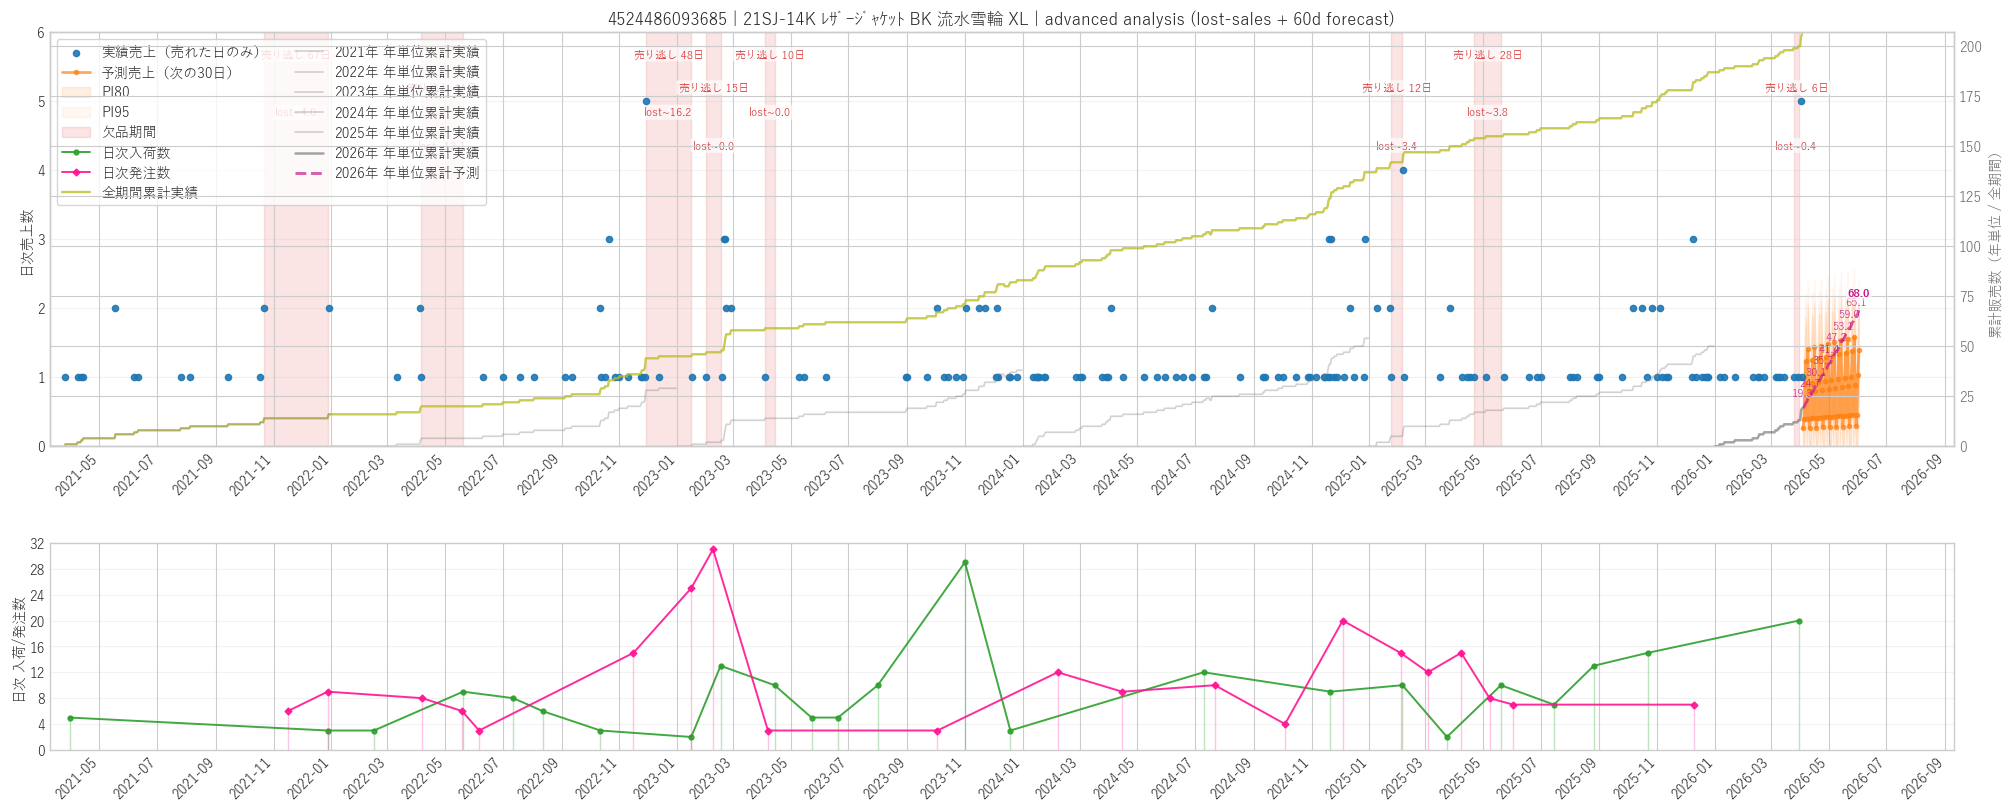

jan                                           4524486093685
item_name                    21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 流水雪輪 XL
hist_sales_total                                      206.0
hist_sales_mean_per_day                            0.111291
stockout_periods                                          8
lost_sales_est_total                              39.873283
forecast_30d_total                                48.953868
forecast_30d_mean_per_day                          0.815898

[欠品期間ごとの売り逃し推定]
stockout_start restock_date  days_out  pred_sales_during_stockout  actual_sales_during_stockout  lost_sales_est
    2021-10-22   2021-12-28      67.0                    4.077813                           2.0        4.024775
    2022-04-06   2022-05-20      44.0                   12.358573                           1.0       12.057184
    2022-11-29   2023-01-16      48.0                   17.010429                           6.0       16.234054
    2023-02-01   2023-02-16      15.0                  

In [18]:
# セル8: 1JANの高度分析（まずはここから実行）

# 分析対象JAN（デフォルトは売上上位JAN）
JAN_TO_VIEW = jan_summary.iloc[2]['jan']

# 未来予測日数
HORIZON_DAYS = 60

# グラフに表示する過去日数
SHOW_HISTORY_DAYS = 2000

# モデルパラメータ
# lookback_days : 曜日係数を学習する履歴窓
# alpha         : EWMAの応答速度（大きいほど直近重視）
# trend_window  : トレンド傾きを推定する日数
LOOKBACK_DAYS = 365
ALPHA = 0.25
TREND_WINDOW = 56

# 表示オフセット（0底ギザギザ緩和）
VISUAL_Y_OFFSET = 0.0

# 未来側の右余白日数（横方向を右に長くする）
FUTURE_PAD_DAYS = 100

# True: 実績は線で結ばず、売れた日だけ点を描画
SALES_POINTS_ONLY = True


# 最新年の累計予測線の色
LATEST_YEAR_FORECAST_COLOR = 'mediumvioletred'
result_advanced = analyze_jan_advanced(
    JAN_TO_VIEW,
    horizon_days=HORIZON_DAYS,
    show_history_days=SHOW_HISTORY_DAYS,
    lookback_days=LOOKBACK_DAYS,
    alpha=ALPHA,
    trend_window=TREND_WINDOW,
    visual_y_offset=VISUAL_Y_OFFSET,
    future_pad_days=FUTURE_PAD_DAYS,
    sales_points_only=SALES_POINTS_ONLY,
    latest_year_forecast_color=LATEST_YEAR_FORECAST_COLOR,
    show_plot=True,
)


In [19]:
# セル9: 全JAN集計とHTMLレポート出力

RUN_ALL_ADVANCED = True  # Trueにしたときだけ実行
EXPORT_HTML = True
INCLUDE_HTML_CHARTS = True

# HTMLに埋め込むJANグラフ数
# - 20 : 上位20JAN（推奨）
# - 0  : 全JAN
CHARTS_TOP_N = 20

# 1JANグラフあたりの過去表示日数
CHART_HISTORY_DAYS = 365

# 表示オフセット（0底ギザギザ緩和）
VISUAL_Y_OFFSET = 0.0

# 未来側の右余白日数（横方向を右に長くする）
FUTURE_PAD_DAYS = 21

# True: 実績は線で結ばず、売れた日だけ点を描画
SALES_POINTS_ONLY = True


# 最新年の累計予測線の色
LATEST_YEAR_FORECAST_COLOR = 'mediumvioletred'
if RUN_ALL_ADVANCED:
    advanced_summary = build_advanced_summary_all_jans(
        horizon_days=30,
        lookback_days=365,
        alpha=0.25,
        trend_window=56,
        export_html=EXPORT_HTML,
        include_html_charts=INCLUDE_HTML_CHARTS,
        charts_top_n=CHARTS_TOP_N,
        chart_history_days=CHART_HISTORY_DAYS,
        visual_y_offset=VISUAL_Y_OFFSET,
        future_pad_days=FUTURE_PAD_DAYS,
        sales_points_only=SALES_POINTS_ONLY,
        latest_year_forecast_color=LATEST_YEAR_FORECAST_COLOR,
    )

    print('\n[advanced_summary top 20]')
    print(advanced_summary.head(20).to_string(index=False))


[1/53] 4524486093708
[2/53] 4524486093678
[3/53] 4524486093685
[4/53] 4524486093692
[5/53] 4524486093715
[6/53] 4524486093661
[7/53] 4524486094965
[8/53] 4524486094972
[9/53] 4524486103247
[10/53] 4524486093647
[11/53] 4524486103254
[12/53] 4524486106545
[13/53] 4524486094958
[14/53] 4524486097973
[15/53] 4524486103230
[16/53] 4524486106552
[17/53] 4524486097959
[18/53] 4524486109492
[19/53] 4524486109508
[20/53] 4524486093654
[21/53] 4524486109485
[22/53] 4524486106538
[23/53] 4524486093630
[24/53] 4524486097966
[25/53] 4524486109515
[26/53] 4524486109522
[27/53] 4524486111495
[28/53] 4524486107566
[29/53] 4524486111501
[30/53] 4524486111488
[31/53] 4524486107559
[32/53] 4524486107573
[33/53] 4524486114328
[34/53] 4524486113499
[35/53] 4524486103308
[36/53] 4524486107740
[37/53] 4524486107757
[38/53] 4524486103315
[39/53] 4524486113505
[40/53] 4524486107764
[41/53] 4524486103292
[42/53] 4524486114311
[43/53] 4524486114335
[44/53] 4524486094934
[45/53] 4524486094927
[46/53] 45244860949